In [2]:
# ============================================================
# DAILY (Chan BSP-based Prob) + 5m Chan/XGB trading engine
# + DAILY GATE that triggers "WAIT FOR FIRST ACCEPTABLE 5m SIGNAL" (NOT immediate)
#
# ✅ NEW IN THIS VERSION
# 1) MODEL + PROCESS CHECKPOINTING (SAVE CURRENT PROCESS)
#    - You can periodically save a "checkpoint" during the run (e.g., end of each day)
#    - The checkpoint includes:
#        * daily prob model state (sklearn pipeline / calibrated model)
#        * 5m XGB packs (buy/sell) + feature cols
#        * thresholds (buy_ret_th_live / sell_ret_th_live)
#        * BSP histories + seen-keys sets
#        * Chan warm-start bars (last N bars) to rebuild Chan quickly
#        * portfolio engine state (cash/pos/qty/entry/pending)
#        * progress cursor (last processed daily index / last processed 5m bar index)
#        * p_by_day cache
#
# 2) RESUME / DEPLOY
#    - Resume: continue from the checkpoint WITHOUT replaying the whole old period
#    - Deploy: load a previously saved bundle (trained on 2015-2024), then run 2025-only
#
# Notes / best practice
# - For stable BSP continuity, set five_chan_max_klines large (e.g., 20000+).
# - This script rebuilds Chan state by feeding only warmup bars from checkpoint.
#   That’s fast and avoids full history replay.
# ============================================================

import os
import json
import copy
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import datetime
from dataclasses import dataclass
from typing import Dict, Any, List, Optional, Tuple

import xgboost as xgb
from sklearn.impute import SimpleImputer
from sklearn.feature_extraction import DictVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.calibration import CalibratedClassifierCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MaxAbsScaler

# Project imports
from sliding_window_chan import SlidingWindowChan
from ChanConfig import CChanConfig
from Common.CEnum import DATA_FIELD, KL_TYPE, AUTYPE
from KLine.KLine_Unit import CKLine_Unit
from Common.CTime import CTime

try:
    from Common.CEnum import DATA_SRC
except Exception:
    class DATA_SRC:
        CSV = "CSV"


# ============================================================
# 0) Persistence helpers
# ============================================================

def save_joblib(path: str, obj: Any):
    os.makedirs(os.path.dirname(path), exist_ok=True)
    joblib.dump(obj, path, compress=3)

def load_joblib(path: str) -> Any:
    return joblib.load(path)

def _ts_str(x) -> str:
    try:
        return str(pd.to_datetime(x))
    except Exception:
        return str(x)

def _safe_copy_list_of_dict(lst):
    if lst is None:
        return []
    out = []
    for x in lst:
        try:
            out.append(dict(x))
        except Exception:
            pass
    return out

def _safe_set_to_list(s):
    if s is None:
        return []
    return list(s)

def _safe_list_to_set(lst):
    if lst is None:
        return set()
    return set(tuple(x) if isinstance(x, list) else x for x in lst)


# ============================================================
# 1) Shared utilities
# ============================================================

def _safe_div(a, b, eps=1e-12):
    return a / (b + eps)

def _pick_col(df: pd.DataFrame, candidates: List[str]) -> Optional[str]:
    cols = list(df.columns)
    for c in candidates:
        if c in cols:
            return c
    lower_map = {c.lower(): c for c in cols}
    for c in candidates:
        if c.lower() in lower_map:
            return lower_map[c.lower()]
    return None

def load_ohlcv_csv(path: str, freq_name: str) -> pd.DataFrame:
    df = pd.read_csv(path)

    ts_col = _pick_col(df, ["timestamp", "date", "datetime", "time"])
    if ts_col is None:
        ts_col = df.columns[0]
    df[ts_col] = pd.to_datetime(df[ts_col], errors="coerce")
    df = df.dropna(subset=[ts_col]).sort_values(ts_col).reset_index(drop=True)
    df = df.rename(columns={ts_col: "timestamp"})

    open_col  = _pick_col(df, ["open", "Open", "o", "O"])
    high_col  = _pick_col(df, ["high", "High", "h", "H"])
    low_col   = _pick_col(df, ["low", "Low", "l", "L"])
    close_col = _pick_col(df, ["close", "Close", "adj_close", "Adj Close", "AdjClose", "c", "C"])
    vol_col   = _pick_col(df, ["volume", "Volume", "vol", "Vol", "v", "V"])

    if open_col is None or close_col is None:
        raise ValueError(f"{freq_name} CSV must contain open/close columns.")
    if high_col is None: high_col = close_col
    if low_col  is None: low_col  = close_col

    df["_open"]  = pd.to_numeric(df[open_col], errors="coerce").astype(float)
    df["_high"]  = pd.to_numeric(df[high_col], errors="coerce").astype(float)
    df["_low"]   = pd.to_numeric(df[low_col], errors="coerce").astype(float)
    df["_close"] = pd.to_numeric(df[close_col], errors="coerce").astype(float)
    df["_vol"]   = pd.to_numeric(df[vol_col], errors="coerce").astype(float) if vol_col is not None else 0.0

    df = df.dropna(subset=["_open", "_high", "_low", "_close"]).reset_index(drop=True)
    df["day"] = df["timestamp"].dt.normalize()
    return df


# ============================================================
# 2) Chan builders
# ============================================================

def to_ctime(ts) -> CTime:
    if isinstance(ts, CTime):
        return ts
    dt = pd.to_datetime(ts).to_pydatetime()
    try:
        return CTime(dt.year, dt.month, dt.day, dt.hour, dt.minute, dt.second, auto=False)
    except Exception:
        pass
    try:
        return CTime(dt.year, dt.month, dt.day, dt.hour, dt.minute, dt.second)
    except Exception:
        pass
    s = dt.strftime("%Y-%m-%d %H:%M:%S")
    try:
        return CTime(s, auto=False)
    except Exception:
        return CTime(s)

def build_klu(ts, o, h, l, c, v=0.0) -> CKLine_Unit:
    ct = to_ctime(ts)
    kl_dict = {
        DATA_FIELD.FIELD_TIME: ct,
        DATA_FIELD.FIELD_OPEN: float(o),
        DATA_FIELD.FIELD_HIGH: float(h),
        DATA_FIELD.FIELD_LOW:  float(l),
        DATA_FIELD.FIELD_CLOSE: float(c),
        DATA_FIELD.FIELD_VOLUME: float(v),
        "time": ct, "timestamp": ct, "datetime": ct, "dt": ct,
        "open": float(o), "high": float(h), "low": float(l), "close": float(c),
        "volume": float(v),
    }
    klu = CKLine_Unit(kl_dict)
    try:
        klu.time = ct
    except Exception:
        pass
    return klu

def feed_chan_one(chan_obj, klu: CKLine_Unit):
    if hasattr(chan_obj, "process_new_kline"):
        return chan_obj.process_new_kline(klu)
    if hasattr(chan_obj, "step_load"):
        return chan_obj.step_load([klu])
    raise AttributeError("Chan object has neither process_new_kline nor step_load")


# ============================================================
# 3) DAILY features
# ============================================================

KLINE_KEYS = [
    "ret1","ret_5","ret_10","ret_20","ret_40",
    "vol_5","vol_10","vol_20","vol_40",
    "atr_14","range_over_atr","close_pos","gap",
    "vol_ratio_5","vol_ratio_20","vol_ratio_60",
    "vol_z_20","vol_z_60","vol_jump",
    "above_ma_20","above_ma_50","above_ma_100",
    "slope40",
]

def compute_daily_kline_features(df_day: pd.DataFrame) -> pd.DataFrame:
    d = df_day.copy().sort_values("timestamp").reset_index(drop=True)
    o = d["_open"].astype(float)
    h = d["_high"].astype(float)
    l = d["_low"].astype(float)
    c = d["_close"].astype(float)
    v = d["_vol"].astype(float)

    prev_c = c.shift(1)
    d["ret1"] = (_safe_div(c, prev_c) - 1.0).replace([np.inf, -np.inf], np.nan).fillna(0.0)

    tr = pd.concat([(h-l).abs(), (h-prev_c).abs(), (l-prev_c).abs()], axis=1).max(axis=1)
    d["tr"] = tr.fillna(0.0)
    d["atr_14"] = d["tr"].rolling(14).mean().bfill().fillna(0.0)

    d["range"] = (h - l).fillna(0.0)
    d["range_over_atr"] = _safe_div(d["range"], d["atr_14"]).replace([np.inf, -np.inf], np.nan).fillna(0.0)

    rng = (h - l).replace(0.0, np.nan)
    d["close_pos"] = ((c - l) / rng).replace([np.inf, -np.inf], np.nan).fillna(0.5)
    d["gap"] = (_safe_div(o, prev_c) - 1.0).replace([np.inf, -np.inf], np.nan).fillna(0.0)

    for w in [5, 10, 20, 40]:
        d[f"ret_{w}"] = (_safe_div(c, c.shift(w)) - 1.0).replace([np.inf, -np.inf], np.nan).fillna(0.0)
        d[f"vol_{w}"] = d["ret1"].rolling(w).std().replace([np.inf, -np.inf], np.nan).fillna(0.0)

    for w in [20, 50, 100]:
        ma = c.rolling(w).mean()
        d[f"above_ma_{w}"] = (_safe_div(c, ma) - 1.0).replace([np.inf, -np.inf], np.nan).fillna(0.0)

    for w in [5, 20, 60]:
        m = v.rolling(w).mean()
        s = v.rolling(w).std()
        d[f"vol_ratio_{w}"] = _safe_div(v, m).replace([np.inf, -np.inf], np.nan).fillna(1.0)
        d[f"vol_z_{w}"] = ((v - m) / (s + 1e-12)).replace([np.inf, -np.inf], np.nan).fillna(0.0)

    d["vol_jump"] = _safe_div(v, v.shift(1)).replace([np.inf, -np.inf], np.nan).fillna(1.0)

    def _slope_log(x):
        x = np.asarray(x, dtype=float)
        x = np.log(np.maximum(x, 1e-12))
        t = np.arange(len(x), dtype=float)
        t = t - t.mean()
        x = x - x.mean()
        den = (t*t).sum()
        return 0.0 if den <= 0 else float((t*x).sum() / den)

    d["slope40"] = d["_close"].rolling(40).apply(_slope_log, raw=False).fillna(0.0)
    return d

def make_kline_dict(row: pd.Series) -> Dict[str, float]:
    out = {}
    for k in KLINE_KEYS:
        val = row[k] if k in row.index else 0.0
        out[f"k_{k}"] = float(val) if np.isfinite(val) else 0.0
    return out


# ============================================================
# 4) DAILY BSP helpers
# ============================================================

def normalize_bsp_row(r: Dict[str, Any]) -> Dict[str, Any]:
    rr = dict(r)
    if "timestamp" in rr:
        rr["timestamp"] = pd.to_datetime(rr["timestamp"], errors="coerce")
    if "direction" not in rr or rr["direction"] is None:
        if rr.get("is_buy", None) is not None:
            rr["direction"] = "buy" if bool(rr["is_buy"]) else "sell"
        else:
            rr["direction"] = "buy"
    rr["direction"] = str(rr["direction"]).lower()
    if "bsp_type" in rr and rr["bsp_type"] is not None:
        rr["bsp_type"] = str(rr["bsp_type"]).lower()
    else:
        rr["bsp_type"] = "?"
    return rr

def extract_bsp_rows_from_chan(chan_obj) -> List[Dict[str, Any]]:
    if hasattr(chan_obj, "export_new_historical_bsp_to_list"):
        out = chan_obj.export_new_historical_bsp_to_list()
        return out if out else []
    if hasattr(chan_obj, "export_new_bsp_to_list"):
        out = chan_obj.export_new_bsp_to_list()
        return out if out else []
    return []

def latest_bsp_dir_up_to(bsp_rows: List[Dict[str, Any]], ts: pd.Timestamp) -> Optional[str]:
    past = [r for r in bsp_rows if pd.to_datetime(r["timestamp"]) <= ts]
    if not past:
        return None
    past = sorted(past, key=lambda x: pd.to_datetime(x["timestamp"]))
    return str(past[-1].get("direction", "")).lower()

def make_daily_bsp_context(bsp_hist: List[Dict[str, Any]], cur_ts: pd.Timestamp, window_days: int = 60) -> Dict[str, float]:
    past = [r for r in bsp_hist if pd.to_datetime(r["timestamp"]) <= cur_ts]
    past = sorted(past, key=lambda x: pd.to_datetime(x["timestamp"]))
    if not past:
        return {
            "ctx_has_bsp": 0.0,
            "ctx_last_dir_buy": 0.0,
            "ctx_last_dir_sell": 0.0,
            "ctx_days_since_last_bsp": 999.0,
            "ctx_days_since_last_buy": 999.0,
            "ctx_days_since_last_sell": 999.0,
            "ctx_density_total": 0.0,
            "ctx_density_buy": 0.0,
            "ctx_density_sell": 0.0,
            "ctx_density_imb": 0.0,
        }
    last = past[-1]
    last_dir = str(last.get("direction", "")).lower()
    days_since_last = float((cur_ts.normalize() - pd.to_datetime(last["timestamp"]).normalize()).days)

    def _days_since(target: str) -> float:
        for r in reversed(past):
            if str(r.get("direction", "")).lower() == target:
                return float((cur_ts.normalize() - pd.to_datetime(r["timestamp"]).normalize()).days)
        return 999.0

    start = cur_ts.normalize() - pd.Timedelta(days=int(window_days))
    recent = [r for r in past if pd.to_datetime(r["timestamp"]).normalize() >= start]
    buy = sum(1 for r in recent if str(r.get("direction", "")).lower() == "buy")
    sell = sum(1 for r in recent if str(r.get("direction", "")).lower() == "sell")
    tot = max(1.0, float(buy + sell))

    return {
        "ctx_has_bsp": 1.0,
        "ctx_last_dir_buy": 1.0 if last_dir == "buy" else 0.0,
        "ctx_last_dir_sell": 1.0 if last_dir == "sell" else 0.0,
        "ctx_days_since_last_bsp": days_since_last,
        "ctx_days_since_last_buy": _days_since("buy"),
        "ctx_days_since_last_sell": _days_since("sell"),
        "ctx_density_total": float(len(recent)),
        "ctx_density_buy": float(buy),
        "ctx_density_sell": float(sell),
        "ctx_density_imb": float((sell - buy) / tot),
    }

def compute_chain_endpoints(bsp_rows: List[Dict[str, Any]]) -> List[Dict[str, Any]]:
    if not bsp_rows:
        return []
    bsps = sorted(bsp_rows, key=lambda r: pd.to_datetime(r["timestamp"]))
    ends = []
    cur_dir = str(bsps[0].get("direction", "")).lower()
    cur_end = bsps[0]
    cur_end_i = 0
    for i in range(1, len(bsps)):
        d = str(bsps[i].get("direction", "")).lower()
        if d == cur_dir:
            cur_end = bsps[i]
            cur_end_i = i
        else:
            ends.append({"end_ts": pd.to_datetime(cur_end["timestamp"]).normalize(), "end_dir": cur_dir, "end_i": cur_end_i})
            cur_dir = d
            cur_end = bsps[i]
            cur_end_i = i
    ends.append({"end_ts": pd.to_datetime(cur_end["timestamp"]).normalize(), "end_dir": cur_dir, "end_i": cur_end_i})
    return ends

def regime_for_day_from_ends(day_norm: pd.Timestamp, ends: List[Dict[str, Any]]) -> str:
    if len(ends) < 2:
        return "unknown"
    for k in range(len(ends) - 1):
        a = ends[k]; b = ends[k+1]
        a_ts, a_dir = a["end_ts"], a["end_dir"]
        b_ts, b_dir = b["end_ts"], b["end_dir"]
        if (day_norm >= a_ts) and (day_norm <= b_ts):
            if a_dir == "buy" and b_dir == "sell":
                return "up"
            if a_dir == "sell" and b_dir == "buy":
                return "down"
    return "unknown"


# ============================================================
# 5) Daily label + model
# ============================================================

def label_confirm_extreme(df_day_feat: pd.DataFrame, idx: int, N: int, base_dir: str) -> Optional[int]:
    if N <= 0:
        return None
    if idx + N >= len(df_day_feat):
        return None
    h0 = float(df_day_feat.loc[idx, "_high"])
    l0 = float(df_day_feat.loc[idx, "_low"])
    fut = df_day_feat.loc[idx+1:idx+N]
    if fut.empty:
        return None
    if base_dir == "sell":
        mx = float(fut["_high"].max())
        return 1 if mx < h0 else 0
    if base_dir == "buy":
        mn = float(fut["_low"].min())
        return 1 if mn > l0 else 0
    return None

def make_daily_features_one_model(
    kline_row: pd.Series,
    bsp_hist_up_to_day: List[Dict[str, Any]],
    p_val: float,
    dp_minK: float,
    dp_maxK: float,
    regime: str,
    base_dir: Optional[str],
) -> Dict[str, float]:
    feats: Dict[str, float] = {}
    feats.update(make_kline_dict(kline_row))

    ts = pd.to_datetime(kline_row["timestamp"])
    feats.update(make_daily_bsp_context(bsp_hist_up_to_day, ts, window_days=60))

    feats["p"] = float(p_val) if np.isfinite(p_val) else 0.0
    feats["dp_minK"] = float(dp_minK) if np.isfinite(dp_minK) else 0.0
    feats["dp_maxK"] = float(dp_maxK) if np.isfinite(dp_maxK) else 0.0

    rg = str(regime).lower()
    feats["rg_up"] = 1.0 if rg == "up" else 0.0
    feats["rg_down"] = 1.0 if rg == "down" else 0.0
    feats["rg_unknown"] = 1.0 if rg not in ("up", "down") else 0.0

    bd = str(base_dir).lower() if base_dir is not None else "none"
    feats["bd_buy"] = 1.0 if bd == "buy" else 0.0
    feats["bd_sell"] = 1.0 if bd == "sell" else 0.0
    feats["bd_none"] = 1.0 if bd not in ("buy", "sell") else 0.0

    return feats

def fit_prob_model_dicts(X_dicts: List[Dict[str, float]], y: np.ndarray):
    base = Pipeline([
        ("vec", DictVectorizer(sparse=True)),
        ("scaler", MaxAbsScaler()),
        ("lr", LogisticRegression(
            max_iter=8000,
            class_weight="balanced",
            solver="saga",
            C=0.5,
            n_jobs=-1
        ))
    ])
    uniq, counts = np.unique(y, return_counts=True)
    if len(uniq) < 2:
        raise ValueError("Only one class in y so far.")
    min_count = int(counts.min())

    if min_count >= 5:
        cal = CalibratedClassifierCV(base, method="sigmoid", cv=3)
        cal.fit(X_dicts, y)
        return cal
    elif min_count >= 3:
        cal = CalibratedClassifierCV(base, method="sigmoid", cv=2)
        cal.fit(X_dicts, y)
        return cal
    else:
        base.fit(X_dicts, y)
        return base

def predict_prob(model, X_dicts: List[Dict[str, float]]) -> np.ndarray:
    return model.predict_proba(X_dicts)[:, 1]

def _get_underlying_pipeline(model):
    if hasattr(model, "calibrated_classifiers_") and len(getattr(model, "calibrated_classifiers_", [])) > 0:
        cc0 = model.calibrated_classifiers_[0]
        if hasattr(cc0, "estimator") and cc0.estimator is not None:
            return cc0.estimator
    return model

def feature_importance_from_lr(model, top_n: int = 80) -> pd.DataFrame:
    pipe = _get_underlying_pipeline(model)
    if not (hasattr(pipe, "named_steps") and "vec" in pipe.named_steps and "lr" in pipe.named_steps):
        return pd.DataFrame(columns=["feature", "coef", "abs_coef"])
    vec = pipe.named_steps["vec"]
    lr = pipe.named_steps["lr"]

    try:
        names = np.array(vec.get_feature_names_out(), dtype=object)
    except Exception:
        names = np.array(getattr(vec, "feature_names_", []), dtype=object)

    coef = lr.coef_.ravel()
    if len(names) != len(coef):
        return pd.DataFrame(columns=["feature", "coef", "abs_coef"])

    df_imp = pd.DataFrame({"feature": names, "coef": coef})
    df_imp["abs_coef"] = df_imp["coef"].abs()
    return df_imp.sort_values("abs_coef", ascending=False).head(int(top_n)).reset_index(drop=True)

@dataclass
class DailyProbState:
    model: Optional[Any] = None
    new_labels: int = 0
    trained_n: int = 0


# ============================================================
# 6) Gate logic (daily)
# ============================================================

def gate_from_p(p_day: float, p_sell_level: float, p_buy_level: float) -> str:
    if not np.isfinite(p_day):
        return "NO_P"
    if p_day >= p_sell_level:
        return "FORCE_SELL"
    if p_day <= p_buy_level:
        return "FORCE_BUY"
    return "FREE"


# ============================================================
# 7) 5m model + thresholds (your old system)
# ============================================================

LABEL_COLS = {"best_return_pct"}
BSP_TYPE_MAP = {"1":1,"2":2,"3a":3,"1p":4,"2s":5,"3b":6}

def prepare_ml_dataset(df: pd.DataFrame) -> pd.DataFrame:
    if df.empty:
        return df
    df = df.copy()

    if "direction" in df.columns:
        d = df["direction"].fillna("unknown").astype(str).str.lower()
        df["direction_encoded"] = np.where(d == "buy", 1, np.where(d == "sell", 0, -1)).astype(np.int32)

    if "bsp_type" in df.columns:
        t = df["bsp_type"].fillna("unknown").astype(str).str.lower()
        df["bsp_type_encoded"] = t.map(BSP_TYPE_MAP).fillna(0).astype(np.int32)

    df = df.replace([np.inf, -np.inf], np.nan)

    numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    numeric_cols = [c for c in numeric_cols if c not in LABEL_COLS]

    if numeric_cols:
        imputer = SimpleImputer(strategy="mean")
        imputed = imputer.fit_transform(df[numeric_cols])
        df[numeric_cols] = pd.DataFrame(imputed, columns=numeric_cols, index=df.index).fillna(0.0)

    return df

def get_feature_columns(df: pd.DataFrame) -> List[str]:
    exclude = set(LABEL_COLS) | {
        "timestamp","code","direction","bsp_type","klu_idx",
        "has_best_exit","best_exit_type","best_exit_klu_idx","best_exit_price",
        "regime_bucket",
    }
    num_cols = df.select_dtypes(include=[np.number, "bool"]).columns.tolist()
    cols = [c for c in num_cols if c not in exclude]
    return sorted(cols)

def to_float_matrix(df: pd.DataFrame, cols: List[str]) -> np.ndarray:
    if not cols:
        return np.zeros((len(df), 0), dtype=np.float32)
    X = df[cols].copy()
    for c in cols:
        X[c] = pd.to_numeric(X[c], errors="coerce")
    X = X.replace([np.inf, -np.inf], np.nan).fillna(0.0)
    return X.to_numpy(dtype=np.float32, copy=False)

@dataclass
class RetModelPack:
    feature_cols: List[str]
    model_ret: xgb.XGBRegressor

def _fit_ret_pack(df_dir: pd.DataFrame, feature_cols: List[str], seed: int) -> RetModelPack:
    ret_df = df_dir.dropna(subset=["best_return_pct"]).copy()
    X = to_float_matrix(ret_df, feature_cols)
    y = ret_df["best_return_pct"].to_numpy(dtype=np.float32)

    model = xgb.XGBRegressor(
        n_estimators=500,
        max_depth=5,
        learning_rate=0.05,
        subsample=0.85,
        colsample_bytree=0.85,
        reg_lambda=1.0,
        random_state=seed,
        n_jobs=4,
    )
    model.fit(X, y)
    return RetModelPack(feature_cols=feature_cols, model_ret=model)

def train_models_two_sided_ret_only(
    bsp_df: pd.DataFrame,
    feature_cols: List[str],
    min_samples_total: int = 300,
) -> Tuple[Optional[RetModelPack], Optional[RetModelPack]]:
    if bsp_df.empty or "direction" not in bsp_df.columns:
        return None, None
    df = bsp_df.copy()
    for c in feature_cols:
        if c not in df.columns:
            df[c] = 0.0

    buy_df = df[df["direction"].astype(str).str.lower() == "buy"].copy()
    sell_df = df[df["direction"].astype(str).str.lower() == "sell"].copy()

    buy_pack = None
    if len(buy_df.dropna(subset=["best_return_pct"])) >= min_samples_total:
        buy_pack = _fit_ret_pack(buy_df, feature_cols, seed=42)

    sell_pack = None
    if len(sell_df.dropna(subset=["best_return_pct"])) >= min_samples_total:
        sell_pack = _fit_ret_pack(sell_df, feature_cols, seed=52)

    return buy_pack, sell_pack

def predict_ret(pack: RetModelPack, row_df: pd.DataFrame) -> float:
    X = to_float_matrix(row_df, pack.feature_cols)
    return float(pack.model_ret.predict(X)[0])

def make_ret_grid(start: float = -0.5, end: float = 2.5, step: float = 0.05) -> List[float]:
    vals = np.arange(start, end + 1e-12, step, dtype=float)
    return [float(x) for x in vals]

def _bars_from_days(days: float, bar_interval_minutes: int) -> int:
    minutes = float(days) * 24.0 * 60.0
    return max(1, int(round(minutes / float(bar_interval_minutes))))

def label_bestlookahead_for_ready_points(
    bsp_rows: List[Dict[str, Any]],
    highs: np.ndarray,
    lows: np.ndarray,
    closes: np.ndarray,
    lookahead_days: float,
    bar_interval_minutes: int,
    current_bar_idx: int,
):
    if not bsp_rows:
        return
    lookahead_bars = _bars_from_days(lookahead_days, bar_interval_minutes)
    n = len(closes)

    for r in bsp_rows:
        if not np.isnan(r.get("best_return_pct", np.nan)):
            continue
        i = r.get("klu_idx", None)
        if i is None:
            continue
        i = int(i)
        end_i = i + lookahead_bars
        if end_i >= n:
            continue
        if end_i > current_bar_idx:
            continue

        d = str(r.get("direction", "buy")).lower()
        c0 = float(closes[i])

        if d == "buy":
            mx = float(np.nanmax(highs[i + 1 : end_i + 1]))
            r["best_return_pct"] = (mx - c0) / c0 * 100.0
        else:
            mn = float(np.nanmin(lows[i + 1 : end_i + 1]))
            r["best_return_pct"] = (c0 - mn) / c0 * 100.0

def _simulate_realized_ret_only_long(
    events: List[Dict[str, Any]],
    pred_buy: Dict[Tuple, float],
    pred_sell: Dict[Tuple, float],
    buy_th: float,
    sell_th: float,
    next_open_by_idx: np.ndarray,
    closes: np.ndarray,
    end_bar_idx: int,
    fee_pct: float = 0.0,
) -> Tuple[float, int]:
    cash = 1.0
    pos = 0
    qty = 0.0
    trades = 0

    def exec_next_open(idx: int) -> Optional[float]:
        if not (0 <= idx < len(next_open_by_idx)):
            return None
        px = next_open_by_idx[idx]
        if px is None or (isinstance(px, float) and np.isnan(px)):
            return None
        return float(px)

    for r in events:
        d = str(r.get("direction", "")).lower()
        ki = int(r.get("klu_idx", -1))
        px = exec_next_open(ki)
        if px is None:
            continue

        if pos == 0 and d == "buy":
            key = (int(r.get("klu_idx",-1)), "buy", str(r.get("bsp_type","?")))
            pr = pred_buy.get(key)
            if pr is not None and pr >= float(buy_th):
                notional = cash
                spend = notional * (1 + fee_pct)
                if spend > cash:
                    spend = cash
                    notional = spend / (1 + fee_pct)
                qty = notional / px
                cash -= spend
                pos = 1
                trades += 1

        elif pos == 1 and d == "sell":
            key = (int(r.get("klu_idx",-1)), "sell", str(r.get("bsp_type","?")))
            pr = pred_sell.get(key)
            if pr is not None and pr >= float(sell_th):
                cash += (qty * px) * (1 - fee_pct)
                qty = 0.0
                pos = 0
                trades += 1

    end_px = float(closes[end_bar_idx])
    eq = cash if pos == 0 else (cash + qty * end_px)
    return float(eq), int(trades)

def choose_thresholds_global_realized(
    df_5m: pd.DataFrame,
    bsp_rows: List[Dict[str, Any]],
    buy_pack: Optional[RetModelPack],
    sell_pack: Optional[RetModelPack],
    asof_bar_idx: int,
    window_days: float,
    ret_grid: List[float],
    next_open_by_idx: np.ndarray,
    closes: np.ndarray,
    fee_pct: float = 0.0,
    min_open_signals: int = 10,
) -> Optional[Tuple[float, float]]:
    if df_5m.empty or not bsp_rows or buy_pack is None or sell_pack is None:
        return None

    end_ts = pd.to_datetime(df_5m.loc[asof_bar_idx, "timestamp"])
    start_ts = end_ts - pd.Timedelta(days=float(window_days))

    events = []
    buy_cand = []
    sell_cand = []
    for r in bsp_rows:
        t = pd.to_datetime(r.get("timestamp", None), errors="coerce")
        if pd.isna(t) or not (start_ts <= t <= end_ts):
            continue
        ki = r.get("klu_idx", None)
        if ki is None:
            continue
        rr = dict(r)
        rr["klu_idx"] = int(ki)
        events.append(rr)
        d = str(rr.get("direction","")).lower()
        if d == "buy":
            buy_cand.append(rr)
        elif d == "sell":
            sell_cand.append(rr)

    if len(buy_cand) < int(min_open_signals) or len(sell_cand) < 1:
        return None

    events.sort(key=lambda x: int(x["klu_idx"]))

    buy_df = prepare_ml_dataset(pd.DataFrame(buy_cand))
    for c in buy_pack.feature_cols:
        if c not in buy_df.columns:
            buy_df[c] = 0.0
    buy_pred = buy_pack.model_ret.predict(to_float_matrix(buy_df, buy_pack.feature_cols)).astype(float)
    pred_buy = {(int(buy_cand[i]["klu_idx"]), "buy", str(buy_cand[i].get("bsp_type","?"))): float(buy_pred[i]) for i in range(len(buy_cand))}

    sell_df = prepare_ml_dataset(pd.DataFrame(sell_cand))
    for c in sell_pack.feature_cols:
        if c not in sell_df.columns:
            sell_df[c] = 0.0
    sell_pred = sell_pack.model_ret.predict(to_float_matrix(sell_df, sell_pack.feature_cols)).astype(float)
    pred_sell = {(int(sell_cand[i]["klu_idx"]), "sell", str(sell_cand[i].get("bsp_type","?"))): float(sell_pred[i]) for i in range(len(sell_cand))}

    end_bar_idx = asof_bar_idx
    best_eq = None
    best_pair = None

    for bt in ret_grid:
        for st in ret_grid:
            eq, _trades = _simulate_realized_ret_only_long(
                events=events,
                pred_buy=pred_buy,
                pred_sell=pred_sell,
                buy_th=float(bt),
                sell_th=float(st),
                next_open_by_idx=next_open_by_idx,
                closes=closes,
                end_bar_idx=end_bar_idx,
                fee_pct=fee_pct,
            )
            if best_eq is None or eq > best_eq:
                best_eq = float(eq)
                best_pair = (float(bt), float(st))

    return best_pair


# ============================================================
# 8) Execution engine (next_open execution) + state IO
# ============================================================

class ExecutionEngine:
    def __init__(self, initial_capital: float, fee_pct: float):
        self.cash = float(initial_capital)
        self.fee_pct = float(fee_pct)
        self.pos = 0
        self.qty = 0.0
        self.entry_px = None
        self.entry_idx = None
        self.pending_order = None
        self.trades = []

    def _exec_px(self, seen_idx: int, next_open_by_idx: np.ndarray) -> Optional[float]:
        if not (0 <= seen_idx < len(next_open_by_idx)):
            return None
        px = next_open_by_idx[seen_idx]
        if px is None or (isinstance(px, float) and np.isnan(px)):
            return None
        return float(px)

    def place_order_for_next_bar(self, side: str, seen_idx: int, reason: str, meta: dict = None, overwrite=True):
        if self.pending_order is not None and not overwrite:
            return
        self.pending_order = {"side": side, "seen_idx": int(seen_idx), "reason": reason, "meta": dict(meta) if meta else {}}

    def maybe_execute_pending(self, next_open_by_idx: np.ndarray):
        if self.pending_order is None:
            return
        side = self.pending_order["side"]
        idx  = self.pending_order["seen_idx"]
        reason = self.pending_order["reason"]
        meta = self.pending_order.get("meta", {}) or {}

        px = self._exec_px(idx, next_open_by_idx)
        if px is None:
            return

        fee = self.fee_pct

        if side == "buy" and self.pos == 0:
            notional = self.cash / (1.0 + fee)
            fee_amt = notional * fee
            qty = notional / px
            self.cash -= (notional + fee_amt)
            self.pos = 1
            self.qty = qty
            self.entry_px = px
            self.entry_idx = idx
            self.trades.append({"side":"buy","seen_idx":idx,"exec_px":px,"qty":qty,"fee":fee_amt,"reason":reason, **meta})

        elif side == "sell" and self.pos == 1:
            notional = self.qty * px
            fee_amt = notional * fee
            recv = notional - fee_amt
            self.cash += recv
            pnl = (px - self.entry_px) * self.qty - fee_amt
            self.trades.append({
                "side":"sell","seen_idx":idx,"exec_px":px,"qty":self.qty,"fee":fee_amt,"reason":reason,
                "pnl": pnl, "entry_px": self.entry_px, "entry_idx": self.entry_idx, **meta
            })
            self.pos = 0
            self.qty = 0.0
            self.entry_px = None
            self.entry_idx = None

        self.pending_order = None

    def mark_to_market(self, last_close: float) -> float:
        px = float(last_close)
        if self.pos == 0:
            return float(self.cash)
        return float(self.cash + self.qty * px)

    def state_dict(self) -> dict:
        return {
            "cash": float(self.cash),
            "fee_pct": float(self.fee_pct),
            "pos": int(self.pos),
            "qty": float(self.qty),
            "entry_px": None if self.entry_px is None else float(self.entry_px),
            "entry_idx": None if self.entry_idx is None else int(self.entry_idx),
            "pending_order": copy.deepcopy(self.pending_order),
            # trades can be large; but for full resume, keep it.
            "trades": copy.deepcopy(self.trades),
        }

    def load_state_dict(self, s: dict):
        self.cash = float(s.get("cash", self.cash))
        self.fee_pct = float(s.get("fee_pct", self.fee_pct))
        self.pos = int(s.get("pos", self.pos))
        self.qty = float(s.get("qty", self.qty))
        self.entry_px = s.get("entry_px", self.entry_px)
        self.entry_idx = s.get("entry_idx", self.entry_idx)
        self.pending_order = s.get("pending_order", self.pending_order)
        self.trades = s.get("trades", self.trades)


# ============================================================
# 9) 5m index load
# ============================================================

def load_5m_index(df_5m: pd.DataFrame, start_time: str, end_time: str):
    df = df_5m.copy()
    st = pd.to_datetime(start_time)
    et = pd.to_datetime(end_time)
    df = df[(df["timestamp"] >= st) & (df["timestamp"] <= et)].copy().reset_index(drop=True)

    df = df.rename(columns={"_open":"Open","_high":"High","_low":"Low","_close":"Close","_vol":"Volume"})
    df.columns = [str(c).strip() for c in df.columns]

    if not df.columns.is_unique:
        df = df.loc[:, ~df.columns.duplicated(keep="first")]

    df["date"] = df["timestamp"].dt.date
    df["next_open"] = df["Open"].shift(-1)
    df["next_close"] = df["Close"].shift(-1)

    next_open_by_idx = df["next_open"].to_numpy()
    next_close_by_idx = df["next_close"].to_numpy()
    closes = df["Close"].to_numpy(dtype=float)
    highs  = df["High"].to_numpy(dtype=float)
    lows   = df["Low"].to_numpy(dtype=float)

    day_close_map = df.groupby("date")["Close"].last().to_dict()
    all_days = sorted(df["date"].unique())
    return df, next_open_by_idx, next_close_by_idx, closes, highs, lows, day_close_map, all_days

def compute_buy_hold_equity(day_close_map: dict, daily_dates: list, initial_capital: float) -> pd.Series:
    closes, dates = [], []
    for d in daily_dates:
        px = day_close_map.get(d)
        if px is None or pd.isna(px):
            continue
        dates.append(d)
        closes.append(float(px))
    if not closes:
        return pd.Series(dtype=float)
    first = closes[0]
    equity = [initial_capital * (c / first) for c in closes]
    return pd.Series(equity, index=pd.to_datetime(dates))


# ============================================================
# 10) Checkpoint bundle builder / loader
# ============================================================

def build_checkpoint_bundle(
    *,
    code: str,
    checkpoint_time: str,

    original_daily_chan_start: str,
    original_accumulation_start: str,
    original_sim_start: str,
    original_end_time: str,

    # models
    daily_prob_model: Any,
    daily_prob_trained_n: int,
    X_days: List[Dict[str, float]],
    y_days: List[int],
    pending_idx: List[int],
    p_by_day: Dict[pd.Timestamp, float],
    p_series: np.ndarray,
    dp_vs_minK_series: np.ndarray,
    dp_vs_maxK_series: np.ndarray,
    bsp_rows_daily: List[Dict[str, Any]],
    seen_bsp_daily: set,

    buy_pack: Optional[RetModelPack],
    sell_pack: Optional[RetModelPack],
    buy_ret_th_live: float,
    sell_ret_th_live: float,

    bsp_rows_5m: List[Dict[str, Any]],
    seen_keys_5m: set,

    engine_state: dict,

    daily_i_last: int,
    five_i_last: int,
    current_day: Optional[datetime.date],

    warmup_daily_bars: pd.DataFrame,
    warmup_5m_bars: pd.DataFrame,

    daily_chan_max_klines: int,
    five_chan_max_klines: int,
) -> dict:
    # p_by_day keys to strings for joblib portability
    p_by_day_str = {str(pd.to_datetime(k)): float(v) for k, v in p_by_day.items()}

    bundle = {
        "schema": "chan_xgb_dailyprob_checkpoint_v1",
        "code": code,
        "checkpoint_time": checkpoint_time,

        "original_daily_chan_start": str(original_daily_chan_start),
        "original_accumulation_start": str(original_accumulation_start),
        "original_sim_start": str(original_sim_start),
        "original_end_time": str(original_end_time),

        "daily_prob_model": daily_prob_model,
        "daily_prob_trained_n": int(daily_prob_trained_n),
        "X_days": X_days,
        "y_days": y_days,
        "pending_idx": pending_idx,

        "p_by_day_str": p_by_day_str,
        "p_series": np.asarray(p_series, dtype=float),
        "dp_vs_minK_series": np.asarray(dp_vs_minK_series, dtype=float),
        "dp_vs_maxK_series": np.asarray(dp_vs_maxK_series, dtype=float),

        "bsp_rows_daily": _safe_copy_list_of_dict(bsp_rows_daily),
        "seen_bsp_daily_list": _safe_set_to_list(seen_bsp_daily),

        "buy_pack": buy_pack,
        "sell_pack": sell_pack,
        "buy_ret_th_live": float(buy_ret_th_live),
        "sell_ret_th_live": float(sell_ret_th_live),

        "bsp_rows_5m": _safe_copy_list_of_dict(bsp_rows_5m),
        "seen_keys_5m_list": _safe_set_to_list(seen_keys_5m),

        "engine_state": engine_state,

        "daily_i_last": int(daily_i_last),
        "five_i_last": int(five_i_last),
        "current_day": None if current_day is None else str(current_day),

        "warmup_daily_bars": warmup_daily_bars.reset_index(drop=True),
        "warmup_5m_bars": warmup_5m_bars.reset_index(drop=True),

        "daily_chan_max_klines": int(daily_chan_max_klines),
        "five_chan_max_klines": int(five_chan_max_klines),
    }
    return bundle

def load_checkpoint_bundle(path: str) -> dict:
    b = load_joblib(path)
    if not isinstance(b, dict):
        raise ValueError("Checkpoint is not a dict.")
    if b.get("schema", "") != "chan_xgb_dailyprob_checkpoint_v1":
        raise ValueError(f"Unknown checkpoint schema: {b.get('schema')}")
    return b


# ============================================================
# 11) MAIN runner (supports SAVE + RESUME)
# ============================================================

def run_daily_prob_then_5m_xgb_gated(
    daily_csv_path: str,
    k5m_csv_path: str,
    code: str = "QQQ",

    daily_chan_start: str = "2016-06-01",
    accumulation_start: str = "2018-10-01",
    sim_start: str = "2019-01-01",
    end_time: str = "2019-12-30",

    # Daily confirm horizon
    N_confirm: int = 5,

    # prob training controls
    min_labeled_days_to_train: int = 200,
    retrain_every_new_labels: int = 25,
    dp_lookback: int = 5,

    # gate thresholds
    p_sell_level: float = 0.30,
    p_buy_level: float = 0.20,

    # 5m model/training
    bar_interval_minutes: int = 5,
    lookahead_days_5m: float = 2.0,
    retrain_every_days_5m: int = 5,
    min_samples_total_5m: int = 300,

    # threshold optimizer
    threshold_window_days: float = 2.0,
    threshold_ret_grid: Optional[List[float]] = None,
    threshold_min_open_signals: int = 10,

    # portfolio
    initial_capital: float = 100000.0,
    fee_pct: float = 0.0,

    # Chan buffers
    daily_chan_max_klines: int = 500,
    five_chan_max_klines: int = 20000,

    output_dir: str = "output_dailyprob_gated_5m_xgb",
    verbose: bool = True,

    # ✅ new: checkpointing / resume
    save_checkpoint_path: Optional[str] = None,         # e.g. "checkpoints/qqq_run.joblib"
    checkpoint_every_n_days: int = 1,                   # save at end of every N trading days
    resume_from_checkpoint_path: Optional[str] = None,  # resume exactly
    deploy_from_bundle_path: Optional[str] = None,      # deploy: load model+state but still run the new period
    deploy_no_retrain: bool = False,                    # if True, freeze training updates
):
    os.makedirs(output_dir, exist_ok=True)

    # ----------------------------
    # Load data
    # ----------------------------
    df_day_raw = load_ohlcv_csv(daily_csv_path, "DAILY")
    df_5m_raw  = load_ohlcv_csv(k5m_csv_path, "5M")

    daily_s = pd.to_datetime(daily_chan_start)
    acc_s   = pd.to_datetime(accumulation_start)
    sim_s   = pd.to_datetime(sim_start)
    end_t   = pd.to_datetime(end_time)

    # daily slice
    df_day = df_day_raw[(df_day_raw["timestamp"] >= daily_s) & (df_day_raw["timestamp"] <= end_t)].copy().reset_index(drop=True)
    if df_day.empty:
        raise ValueError("No daily bars in requested range.")
    df_day_feat = compute_daily_kline_features(df_day)

    # 5m slice
    df_5m = df_5m_raw[(df_5m_raw["timestamp"] >= acc_s) & (df_5m_raw["timestamp"] <= end_t + pd.Timedelta(days=1))].copy()
    df_5m = df_5m.sort_values("timestamp").reset_index(drop=True)

    df_5m_idx, next_open_by_idx, next_close_by_idx, closes, highs, lows, day_close_map, all_days = load_5m_index(
        df_5m, accumulation_start, end_time
    )
    buy_hold = compute_buy_hold_equity(day_close_map, all_days, initial_capital)

    # ----------------------------
    # Chan config
    # ----------------------------
    config = CChanConfig({
        "cal_demark": True,
        "cal_kdj": True,
        "cal_dmi": True,
        "cal_rsi": True,
        "cal_rsl": True,
        "cal_demand_index": True,
        "cal_adline": True,
        "cal_bb_vals": True,
        "cal_kc_vals": True,
        "cal_starc_vals": True,
        "bi_strict": True,
        "trigger_step": True,
        "skip_step": 0,
        "divergence_rate": float("inf"),
        "bsp2_follow_1": True,
        "bsp3_follow_1": False,
        "min_zs_cnt": 0,
        "bs1_peak": False,
        "macd_algo": "peak",
        "bs_type": "1,2,3a,1p,2s,3b",
        "print_warning": False,
        "zs_algo": "normal",
    })

    daily_chan = SlidingWindowChan(
        code=code,
        begin_time=None,
        end_time=None,
        data_src=getattr(DATA_SRC, "CSV", "CSV"),
        lv_list=[KL_TYPE.K_DAY],
        config=config,
        autype=AUTYPE.QFQ,
        max_klines=int(daily_chan_max_klines),
    )

    chan_5m = SlidingWindowChan(
        code=code,
        begin_time=None,
        end_time=None,
        data_src=getattr(DATA_SRC, "CSV", "CSV"),
        lv_list=[KL_TYPE.K_5M],
        config=config,
        autype=AUTYPE.QFQ,
        max_klines=int(five_chan_max_klines),
    )

    # =========================================================
    # State containers (default fresh run)
    # =========================================================
    bsp_rows_daily: List[Dict[str, Any]] = []
    seen_bsp_daily = set()

    X_days: List[Dict[str, float]] = []
    y_days: List[int] = []
    st = DailyProbState()
    pending_idx: List[int] = []

    p_series = np.full(len(df_day_feat), np.nan, dtype=float)
    dp_vs_minK_series = np.full(len(df_day_feat), np.nan, dtype=float)
    dp_vs_maxK_series = np.full(len(df_day_feat), np.nan, dtype=float)
    p_by_day: Dict[pd.Timestamp, float] = {}

    # 5m side
    engine = ExecutionEngine(initial_capital=initial_capital, fee_pct=fee_pct)
    bsp_rows_5m: List[Dict[str, Any]] = []
    seen_keys_5m = set()
    buy_pack: Optional[RetModelPack] = None
    sell_pack: Optional[RetModelPack] = None
    last_train_day: Optional[pd.Timestamp] = None

    if threshold_ret_grid is None:
        threshold_ret_grid = make_ret_grid(-0.5, 2.5, 0.05)
    buy_ret_th_live = 0.30
    sell_ret_th_live = 0.30

    # progress cursors
    daily_i_start = 0
    five_i_start = 0
    current_day: Optional[datetime.date] = None
    daily_log = []

    # =========================================================
    # RESUME: from checkpoint (full process resume)
    # =========================================================
    if resume_from_checkpoint_path is not None and os.path.exists(resume_from_checkpoint_path):
        B = load_checkpoint_bundle(resume_from_checkpoint_path)
        if verbose:
            print(f"[RESUME] loading checkpoint: {resume_from_checkpoint_path} @ {B.get('checkpoint_time')}")

        # restore daily prob model + training sets
        st.model = B.get("daily_prob_model", None)
        st.trained_n = int(B.get("daily_prob_trained_n", 0))
        st.new_labels = 0

        X_days = B.get("X_days", []) or []
        y_days = B.get("y_days", []) or []
        pending_idx = B.get("pending_idx", []) or []

        # restore p caches
        p_series_loaded = B.get("p_series", None)
        if p_series_loaded is not None and len(p_series_loaded) == len(p_series):
            p_series = np.asarray(p_series_loaded, dtype=float)
        dp_min_loaded = B.get("dp_vs_minK_series", None)
        dp_max_loaded = B.get("dp_vs_maxK_series", None)
        if dp_min_loaded is not None and len(dp_min_loaded) == len(dp_vs_minK_series):
            dp_vs_minK_series = np.asarray(dp_min_loaded, dtype=float)
        if dp_max_loaded is not None and len(dp_max_loaded) == len(dp_vs_maxK_series):
            dp_vs_maxK_series = np.asarray(dp_max_loaded, dtype=float)

        p_by_day_str = B.get("p_by_day_str", {}) or {}
        p_by_day = {pd.to_datetime(k).normalize(): float(v) for k, v in p_by_day_str.items()}

        # restore bsp and seen keys
        bsp_rows_daily = B.get("bsp_rows_daily", []) or []
        seen_bsp_daily = _safe_list_to_set(B.get("seen_bsp_daily_list", []))

        # restore 5m models + thresholds
        buy_pack = B.get("buy_pack", None)
        sell_pack = B.get("sell_pack", None)
        buy_ret_th_live = float(B.get("buy_ret_th_live", buy_ret_th_live))
        sell_ret_th_live = float(B.get("sell_ret_th_live", sell_ret_th_live))

        bsp_rows_5m = B.get("bsp_rows_5m", []) or []
        seen_keys_5m = _safe_list_to_set(B.get("seen_keys_5m_list", []))

        # restore engine state
        engine.load_state_dict(B.get("engine_state", {}) or {})

        # progress cursors: continue from next bar/day
        daily_i_start = int(B.get("daily_i_last", -1)) + 1
        five_i_start = int(B.get("five_i_last", -1)) + 1
        cur_day_s = B.get("current_day", None)
        current_day = None if cur_day_s is None else datetime.date.fromisoformat(cur_day_s)

        # rebuild Chan warm state from warmup bars
        warm_day = B.get("warmup_daily_bars", None)
        if warm_day is not None and len(warm_day):
            for _, rr in warm_day.iterrows():
                ts = pd.to_datetime(rr["timestamp"])
                daily_chan.process_new_kline(build_klu(ts, rr["_open"], rr["_high"], rr["_low"], rr["_close"], rr.get("_vol", 0.0)))

        warm_5m = B.get("warmup_5m_bars", None)
        if warm_5m is not None and len(warm_5m):
            for _, rr in warm_5m.iterrows():
                ts = pd.to_datetime(rr["timestamp"])
                feed_chan_one(chan_5m, build_klu(ts, rr["_open"], rr["_high"], rr["_low"], rr["_close"], rr.get("_vol", 0.0)))

        if verbose:
            print(f"[RESUME] daily_i_start={daily_i_start} / {len(df_day_feat)}")
            print(f"[RESUME] five_i_start={five_i_start} / {len(df_5m_idx)}")
            print(f"[RESUME] daily_model={'YES' if st.model is not None else 'NO'} "
                  f"5m_buy={'YES' if buy_pack else 'NO'} 5m_sell={'YES' if sell_pack else 'NO'}")

    # =========================================================
    # DEPLOY: from saved bundle (train 2015-2024 then run 2025-only)
    #   - This is a partial restore (models + warmup state), but NOT "mid-run".
    # =========================================================
    if (resume_from_checkpoint_path is None) and (deploy_from_bundle_path is not None) and os.path.exists(deploy_from_bundle_path):
        B = load_checkpoint_bundle(deploy_from_bundle_path)
        if verbose:
            print(f"[DEPLOY] loading bundle: {deploy_from_bundle_path} @ {B.get('checkpoint_time')}")

        st.model = B.get("daily_prob_model", None)
        st.trained_n = int(B.get("daily_prob_trained_n", 0))
        st.new_labels = 0

        # for deploy, you usually don't need to keep re-training arrays,
        # but we restore them so you CAN continue training if you want.
        X_days = B.get("X_days", []) or []
        y_days = B.get("y_days", []) or []
        pending_idx = []

        # BSP histories for regime/context continuity
        bsp_rows_daily = B.get("bsp_rows_daily", []) or []
        seen_bsp_daily = _safe_list_to_set(B.get("seen_bsp_daily_list", []))

        buy_pack = B.get("buy_pack", None)
        sell_pack = B.get("sell_pack", None)
        buy_ret_th_live = float(B.get("buy_ret_th_live", buy_ret_th_live))
        sell_ret_th_live = float(B.get("sell_ret_th_live", sell_ret_th_live))

        bsp_rows_5m = B.get("bsp_rows_5m", []) or []
        seen_keys_5m = _safe_list_to_set(B.get("seen_keys_5m_list", []))

        # p_by_day cache (optional)
        p_by_day_str = B.get("p_by_day_str", {}) or {}
        p_by_day = {pd.to_datetime(k).normalize(): float(v) for k, v in p_by_day_str.items()}

        # warm start Chan
        warm_day = B.get("warmup_daily_bars", None)
        if warm_day is not None and len(warm_day):
            for _, rr in warm_day.iterrows():
                ts = pd.to_datetime(rr["timestamp"])
                daily_chan.process_new_kline(build_klu(ts, rr["_open"], rr["_high"], rr["_low"], rr["_close"], rr.get("_vol", 0.0)))

        warm_5m = B.get("warmup_5m_bars", None)
        if warm_5m is not None and len(warm_5m):
            for _, rr in warm_5m.iterrows():
                ts = pd.to_datetime(rr["timestamp"])
                feed_chan_one(chan_5m, build_klu(ts, rr["_open"], rr["_high"], rr["_low"], rr["_close"], rr.get("_vol", 0.0)))

        if verbose:
            print(f"[DEPLOY] daily_model={'YES' if st.model is not None else 'NO'} "
                  f"5m_buy={'YES' if buy_pack else 'NO'} 5m_sell={'YES' if sell_pack else 'NO'}")

    # =========================================================
    # DAILY training loop (if not already completed)
    # - For RESUME, starts from daily_i_start
    # - For DEPLOY, you can still run daily phase on new days (2025) to generate p_by_day,
    #   without replaying old history.
    # =========================================================

    def maybe_train_daily():
        if deploy_no_retrain:
            return
        if len(y_days) < int(min_labeled_days_to_train):
            return
        if st.model is None or st.new_labels >= int(retrain_every_new_labels):
            y = np.asarray(y_days, dtype=int)
            if len(np.unique(y)) < 2:
                return
            try:
                st.model = fit_prob_model_dicts(X_days, y)
                st.trained_n = len(y)
                st.new_labels = 0
                if verbose:
                    print(f"[TRAIN][DAILY-PROB] n={len(y)} pos={int(y.sum())} ({y.mean():.2%})")
            except Exception as e:
                if verbose:
                    print(f"[TRAIN][DAILY-PROB] skipped: {e}")

    # daily loop
    for i in range(daily_i_start, len(df_day_feat)):
        r = df_day_feat.loc[i]
        ts = pd.to_datetime(r["timestamp"])
        day = ts.normalize()

        daily_chan.process_new_kline(build_klu(ts, r["_open"], r["_high"], r["_low"], r["_close"], r["_vol"]))

        new_bsp = extract_bsp_rows_from_chan(daily_chan)
        if new_bsp:
            for rr0 in new_bsp:
                rr = normalize_bsp_row(dict(rr0))
                rr.setdefault("timestamp", ts)
                key = (pd.to_datetime(rr["timestamp"]).strftime("%Y-%m-%d"), rr["direction"], rr.get("bsp_type", "?"))
                if key in seen_bsp_daily:
                    continue
                seen_bsp_daily.add(key)
                bsp_rows_daily.append(rr)

        ends = compute_chain_endpoints(bsp_rows_daily)
        regime = regime_for_day_from_ends(day, ends)
        base_dir_today = latest_bsp_dir_up_to(bsp_rows_daily, ts)

        # predict p_day if model exists
        p_val = np.nan
        if st.model is not None:
            bsp_hist = [b for b in bsp_rows_daily if pd.to_datetime(b["timestamp"]) <= ts]
            feat_i = make_daily_features_one_model(
                kline_row=r,
                bsp_hist_up_to_day=bsp_hist,
                p_val=0.0,
                dp_minK=0.0,
                dp_maxK=0.0,
                regime=regime,
                base_dir=base_dir_today,
            )
            p_val = float(predict_prob(st.model, [feat_i])[0])
            p_series[i] = p_val
            p_by_day[day] = p_val

        # dp vs min/max prev K
        lb = int(dp_lookback)
        p_minK = np.nan
        p_maxK = np.nan
        if lb > 0 and i >= 1 and np.isfinite(p_val):
            start = max(0, i - lb)
            prev = pd.Series(p_series[start:i]).dropna()
            if len(prev) > 0:
                p_minK = float(prev.min())
                p_maxK = float(prev.max())

        dp_vs_minK = (p_val - p_minK) if (np.isfinite(p_val) and np.isfinite(p_minK)) else np.nan
        dp_vs_maxK = (p_val - p_maxK) if (np.isfinite(p_val) and np.isfinite(p_maxK)) else np.nan
        dp_vs_minK_series[i] = dp_vs_minK
        dp_vs_maxK_series[i] = dp_vs_maxK

        # finalize labels for older days
        pending_idx.append(i)
        while pending_idx and i >= pending_idx[0] + int(N_confirm):
            j = pending_idx.pop(0)
            t0 = pd.to_datetime(df_day_feat.loc[j, "timestamp"])
            base_dir_j = latest_bsp_dir_up_to(bsp_rows_daily, t0)
            if base_dir_j not in ("buy", "sell"):
                continue

            y = label_confirm_extreme(df_day_feat, j, int(N_confirm), base_dir_j)
            if y is None:
                continue

            ends_j = compute_chain_endpoints([b for b in bsp_rows_daily if pd.to_datetime(b["timestamp"]) <= t0])
            regime_j = regime_for_day_from_ends(t0.normalize(), ends_j)

            bsp_hist_j = [b for b in bsp_rows_daily if pd.to_datetime(b["timestamp"]) <= t0]
            feat_j = make_daily_features_one_model(
                kline_row=df_day_feat.loc[j],
                bsp_hist_up_to_day=bsp_hist_j,
                p_val=float(p_series[j]) if np.isfinite(p_series[j]) else 0.0,
                dp_minK=float(dp_vs_minK_series[j]) if np.isfinite(dp_vs_minK_series[j]) else 0.0,
                dp_maxK=float(dp_vs_maxK_series[j]) if np.isfinite(dp_vs_maxK_series[j]) else 0.0,
                regime=regime_j,
                base_dir=base_dir_j,
            )

            if not deploy_no_retrain:
                X_days.append(feat_j)
                y_days.append(int(y))
                st.new_labels += 1

        maybe_train_daily()

    if verbose:
        y = np.asarray(y_days, dtype=int) if len(y_days) else np.array([], dtype=int)
        if len(y):
            print(f"[LABELS][DAILY-PROB] n={len(y)} pos={int(y.sum())} ({y.mean():.2%})")
        print(f"[MODEL][DAILY-PROB] trained={'yes' if st.model is not None else 'no'} trained_n={st.trained_n}")
        print(f"[BSP][DAILY] total={len(bsp_rows_daily)}")

    feat_imp_path = os.path.join(output_dir, "daily_lr_feature_importance.csv")
    if st.model is not None:
        try:
            imp_df = feature_importance_from_lr(st.model, top_n=120)
            imp_df.to_csv(feat_imp_path, index=False)
            if verbose:
                print(f"[SAVED] {feat_imp_path}")
        except Exception as e:
            if verbose:
                print(f"[IMP][DAILY-PROB] skipped: {e}")

    # =========================================================
    # PHASE 2/3: 5m accumulation + trading with daily gate
    # =========================================================
    if verbose:
        print(f"[PHASE2/3] 5m feed begins at accumulation_start={acc_s.date()}, trading starts at sim_s={sim_s.date()}")

    def maybe_retrain_5m(day_ts: pd.Timestamp):
        nonlocal buy_pack, sell_pack, last_train_day
        if deploy_no_retrain:
            return
        if last_train_day is not None and (day_ts - last_train_day).days < int(retrain_every_days_5m):
            return
        dfb = pd.DataFrame(bsp_rows_5m)
        if dfb.empty:
            return
        dfb2 = prepare_ml_dataset(dfb)
        feat_cols = get_feature_columns(dfb2)
        bp, sp = train_models_two_sided_ret_only(dfb2, feat_cols, min_samples_total=min_samples_total_5m)
        if bp is not None:
            buy_pack = bp
        if sp is not None:
            sell_pack = sp
        if (bp is not None) or (sp is not None):
            last_train_day = day_ts
            if verbose:
                print(f"[TRAIN][5M] asof={day_ts.date()} feats={len(feat_cols)} buy={'YES' if bp else 'NO'} sell={'YES' if sp else 'NO'} rows={len(dfb2)}")

    def maybe_opt_thresholds(asof_bar_idx: int):
        nonlocal buy_ret_th_live, sell_ret_th_live
        if buy_pack is None or sell_pack is None:
            return
        out = choose_thresholds_global_realized(
            df_5m=df_5m_idx,
            bsp_rows=bsp_rows_5m,
            buy_pack=buy_pack,
            sell_pack=sell_pack,
            asof_bar_idx=asof_bar_idx,
            window_days=threshold_window_days,
            ret_grid=threshold_ret_grid,
            next_open_by_idx=next_open_by_idx,
            closes=closes,
            fee_pct=fee_pct,
            min_open_signals=threshold_min_open_signals,
        )
        if out is not None:
            buy_ret_th_live, sell_ret_th_live = out
            if verbose:
                print(f"[TH-OPT][GLOBAL] asof_bar={asof_bar_idx} buy_th={buy_ret_th_live:.2f} sell_th={sell_ret_th_live:.2f}")

    # checkpoint day counter
    last_checkpoint_saved_day: Optional[datetime.date] = None
    days_since_checkpoint = 0

    def save_checkpoint(now_ts: pd.Timestamp, daily_i_last: int, five_i_last: int, current_day: Optional[datetime.date]):
        nonlocal last_checkpoint_saved_day, days_since_checkpoint
        if save_checkpoint_path is None:
            return

        # warmup bars: take last N bars up to now_ts from raw inputs (fast)
        warm_daily = df_day_raw[df_day_raw["timestamp"] <= now_ts].tail(int(daily_chan_max_klines)).copy()
        warm_5m = df_5m_raw[df_5m_raw["timestamp"] <= now_ts].tail(int(five_chan_max_klines)).copy()

        bundle = build_checkpoint_bundle(
            code=code,
            checkpoint_time=str(now_ts),

            original_daily_chan_start=str(daily_chan_start),
            original_accumulation_start=str(accumulation_start),
            original_sim_start=str(sim_start),
            original_end_time=str(end_time),

            daily_prob_model=st.model,
            daily_prob_trained_n=st.trained_n,
            X_days=X_days,
            y_days=y_days,
            pending_idx=pending_idx,
            p_by_day=p_by_day,
            p_series=p_series,
            dp_vs_minK_series=dp_vs_minK_series,
            dp_vs_maxK_series=dp_vs_maxK_series,
            bsp_rows_daily=bsp_rows_daily,
            seen_bsp_daily=seen_bsp_daily,

            buy_pack=buy_pack,
            sell_pack=sell_pack,
            buy_ret_th_live=buy_ret_th_live,
            sell_ret_th_live=sell_ret_th_live,

            bsp_rows_5m=bsp_rows_5m,
            seen_keys_5m=seen_keys_5m,

            engine_state=engine.state_dict(),

            daily_i_last=daily_i_last,
            five_i_last=five_i_last,
            current_day=current_day,

            warmup_daily_bars=warm_daily[["timestamp","_open","_high","_low","_close","_vol"]].reset_index(drop=True),
            warmup_5m_bars=warm_5m[["timestamp","_open","_high","_low","_close","_vol"]].reset_index(drop=True),

            daily_chan_max_klines=daily_chan_max_klines,
            five_chan_max_klines=five_chan_max_klines,
        )

        save_joblib(save_checkpoint_path, bundle)
        last_checkpoint_saved_day = current_day
        days_since_checkpoint = 0
        if verbose:
            print(f"[CHECKPOINT] saved -> {save_checkpoint_path} @ {now_ts}")

    sim_start_ts = pd.to_datetime(sim_start)
    last_day_end_idx = None

    # 5m day-level gate state (initialized on first encountered day)
    day_gate: str = "NO_P"
    must_trade_dir: Optional[str] = None
    allow_buy: bool = True
    allow_sell: bool = True

    # if resuming from checkpoint, we might already have current_day
    # but we still need to re-init gate when the loop enters a day boundary.
    # We'll handle it naturally when current_day is None at start, or when day changes.

    for i in range(five_i_start, len(df_5m_idx)):
        bar_ts = pd.to_datetime(df_5m_idx.loc[i, "timestamp"])
        bar_day = bar_ts.date()
        in_sim = (bar_ts >= sim_start_ts)

        if current_day is None:
            current_day = bar_day

            p_day = p_by_day.get(pd.to_datetime(bar_day), np.nan)
            day_gate = gate_from_p(p_day, p_sell_level, p_buy_level)

            allow_buy = True
            allow_sell = True
            must_trade_dir = None

            if day_gate == "FORCE_BUY":
                allow_sell = False
                if engine.pos == 0:
                    must_trade_dir = "buy"
            elif day_gate == "FORCE_SELL":
                allow_buy = False
                if engine.pos == 1:
                    must_trade_dir = "sell"

            if verbose:
                prob_str = "nan" if not np.isfinite(p_day) else f"{p_day:.3f}"
                print(f"[DAY INIT] {bar_day} prob={prob_str} gate={day_gate} must={must_trade_dir} "
                      f"| th_buy={buy_ret_th_live:.2f} th_sell={sell_ret_th_live:.2f}")

        if bar_day != current_day:
            prev_day = current_day
            prev_day_ts = pd.to_datetime(prev_day)

            # label lookahead points that are now "ready"
            label_bestlookahead_for_ready_points(
                bsp_rows=bsp_rows_5m,
                highs=highs, lows=lows, closes=closes,
                lookahead_days=lookahead_days_5m,
                bar_interval_minutes=bar_interval_minutes,
                current_bar_idx=i,
            )

            # retrain and optimize thresholds at EOD
            maybe_retrain_5m(prev_day_ts)
            if last_day_end_idx is not None:
                maybe_opt_thresholds(last_day_end_idx)

            day_close = day_close_map.get(prev_day)
            equity = engine.mark_to_market(day_close) if day_close is not None else engine.cash
            daily_log.append({"date": prev_day, "equity": equity, "cash": engine.cash, "pos": engine.pos,
                              "buy_th": buy_ret_th_live, "sell_th": sell_ret_th_live})

            if verbose:
                tag = "SIM" if (pd.to_datetime(prev_day) >= sim_start_ts.normalize()) else "ACCUM"
                print(f"[EOD-{tag}] {prev_day} equity={equity:.2f} cash={engine.cash:.2f} pos={engine.pos} "
                      f"| next_day={bar_day} (thresholds kept/updated)")

            # ✅ checkpoint: at end of each day (or every N days)
            days_since_checkpoint += 1
            if save_checkpoint_path is not None and days_since_checkpoint >= int(checkpoint_every_n_days):
                # daily_i_last = len(df_day_feat)-1 because daily phase is already up to end_time.
                # five_i_last = last_day_end_idx
                save_checkpoint(
                    now_ts=pd.to_datetime(df_5m_idx.loc[last_day_end_idx, "timestamp"]),
                    daily_i_last=(len(df_day_feat) - 1),
                    five_i_last=int(last_day_end_idx),
                    current_day=prev_day
                )

            current_day = bar_day

            # init gate for new day
            p_day = p_by_day.get(pd.to_datetime(bar_day), np.nan)
            day_gate = gate_from_p(p_day, p_sell_level, p_buy_level)

            allow_buy = True
            allow_sell = True
            must_trade_dir = None

            if day_gate == "FORCE_BUY":
                allow_sell = False
                if engine.pos == 0:
                    must_trade_dir = "buy"
            elif day_gate == "FORCE_SELL":
                allow_buy = False
                if engine.pos == 1:
                    must_trade_dir = "sell"

            if verbose:
                prob_str = "nan" if not np.isfinite(p_day) else f"{p_day:.3f}"
                print(f"[DAY INIT] {bar_day} prob={prob_str} gate={day_gate} must={must_trade_dir} "
                      f"| th_buy={buy_ret_th_live:.2f} th_sell={sell_ret_th_live:.2f}")

        last_day_end_idx = i

        if in_sim:
            engine.maybe_execute_pending(next_open_by_idx)

        # feed Chan 5m
        klu = build_klu(
            df_5m_idx.loc[i, "timestamp"],
            df_5m_idx.loc[i, "Open"], df_5m_idx.loc[i, "High"], df_5m_idx.loc[i, "Low"], df_5m_idx.loc[i, "Close"],
            df_5m_idx.loc[i, "Volume"],
        )
        feed_chan_one(chan_5m, klu)

        new_rows = extract_bsp_rows_from_chan(chan_5m)
        if not new_rows:
            continue

        for r0 in new_rows:
            r = dict(r0)
            r.setdefault("timestamp", str(bar_ts))
            r.setdefault("klu_idx", i)

            if "direction" not in r or r["direction"] is None:
                if r.get("is_buy", None) is not None:
                    r["direction"] = "buy" if bool(r["is_buy"]) else "sell"
                else:
                    r["direction"] = "buy"
            r["direction"] = str(r["direction"]).lower()
            if "bsp_type" in r and r["bsp_type"] is not None:
                r["bsp_type"] = str(r["bsp_type"]).lower()

            r.setdefault("best_return_pct", np.nan)

            k = (int(r.get("klu_idx",-1)), str(r.get("direction")), str(r.get("bsp_type")))
            if k in seen_keys_5m:
                continue
            seen_keys_5m.add(k)
            bsp_rows_5m.append(r)

            if not in_sim:
                continue

            d = str(r.get("direction","buy")).lower()
            ki = int(r.get("klu_idx", i))

            if d == "buy" and not allow_buy:
                continue
            if d == "sell" and not allow_sell:
                continue
            if must_trade_dir is not None and d != must_trade_dir:
                continue

            if d == "buy" and engine.pos == 0 and buy_pack is not None:
                row_df = prepare_ml_dataset(pd.DataFrame([r]))
                for cc in buy_pack.feature_cols:
                    if cc not in row_df.columns:
                        row_df[cc] = 0.0
                pr = predict_ret(buy_pack, row_df)

                if pr >= float(buy_ret_th_live):
                    engine.place_order_for_next_bar(
                        side="buy",
                        seen_idx=ki,
                        reason=("FORCE_BUY->first acceptable 5m signal" if day_gate=="FORCE_BUY" else "5m BUY signal"),
                        meta={"ts": str(bar_ts), "p_day": float(p_by_day.get(pd.to_datetime(bar_day), np.nan)),
                              "pred": float(pr), "th": float(buy_ret_th_live), "gate": day_gate}
                    )
                    if must_trade_dir == "buy":
                        must_trade_dir = None

            elif d == "sell" and engine.pos == 1 and sell_pack is not None:
                row_df = prepare_ml_dataset(pd.DataFrame([r]))
                for cc in sell_pack.feature_cols:
                    if cc not in row_df.columns:
                        row_df[cc] = 0.0
                pr = predict_ret(sell_pack, row_df)

                if pr >= float(sell_ret_th_live):
                    engine.place_order_for_next_bar(
                        side="sell",
                        seen_idx=ki,
                        reason=("FORCE_SELL->first acceptable 5m signal" if day_gate=="FORCE_SELL" else "5m SELL signal"),
                        meta={"ts": str(bar_ts), "p_day": float(p_by_day.get(pd.to_datetime(bar_day), np.nan)),
                              "pred": float(pr), "th": float(sell_ret_th_live), "gate": day_gate}
                    )
                    if must_trade_dir == "sell":
                        must_trade_dir = None

    # final day log
    if current_day is not None:
        day_close = day_close_map.get(current_day)
        equity = engine.mark_to_market(day_close) if day_close is not None else engine.cash
        daily_log.append({"date": current_day, "equity": equity, "cash": engine.cash, "pos": engine.pos,
                          "buy_th": buy_ret_th_live, "sell_th": sell_ret_th_live})

    # final checkpoint (end of run)
    if save_checkpoint_path is not None and len(df_5m_idx) > 0:
        final_ts = pd.to_datetime(df_5m_idx.loc[len(df_5m_idx)-1, "timestamp"])
        save_checkpoint(
            now_ts=final_ts,
            daily_i_last=(len(df_day_feat) - 1),
            five_i_last=(len(df_5m_idx) - 1),
            current_day=current_day
        )

    # =========================================================
    # Save outputs
    # =========================================================
    trades_df = pd.DataFrame(engine.trades)
    daily_df = pd.DataFrame(daily_log)
    if not daily_df.empty:
        daily_df["date"] = pd.to_datetime(daily_df["date"])
        daily_df = daily_df.sort_values("date").reset_index(drop=True)

    trades_csv = os.path.join(output_dir, "trades.csv")
    daily_csv = os.path.join(output_dir, "daily_log.csv")
    trades_df.to_csv(trades_csv, index=False)
    daily_df.to_csv(daily_csv, index=False)

    # Plots
    out_eq = os.path.join(output_dir, "equity_vs_buyhold.png")
    out_px = os.path.join(output_dir, "price_with_trades.png")
    out_p  = os.path.join(output_dir, "p_day.png")

    plt.figure()
    if not daily_df.empty:
        plt.plot(daily_df["date"], daily_df["equity"], label="Strategy Equity")
    if len(buy_hold) > 0:
        plt.plot(buy_hold.index, buy_hold.values, label="Buy&Hold")
    plt.legend()
    plt.title("Equity vs Buy&Hold")
    plt.xlabel("Date")
    plt.ylabel("Equity")
    plt.savefig(out_eq, dpi=150, bbox_inches="tight")
    plt.show()

    plt.figure()
    plt.plot(df_5m_idx["timestamp"], df_5m_idx["Close"], label="5m Close")
    if not trades_df.empty:
        for _, tr in trades_df.iterrows():
            idx = int(tr["seen_idx"])
            if 0 <= idx < len(df_5m_idx):
                t = pd.to_datetime(df_5m_idx.loc[idx, "timestamp"])
                px = float(tr["exec_px"])
                if tr.get("side","") == "buy":
                    plt.scatter([t], [px], marker="^")
                else:
                    plt.scatter([t], [px], marker="v")
    plt.title("Price with Trade Markers")
    plt.xlabel("Time")
    plt.ylabel("Price")
    plt.savefig(out_px, dpi=150, bbox_inches="tight")
    plt.show()

    days_sorted = sorted(p_by_day.keys())
    if days_sorted:
        plt.figure()
        xs = pd.to_datetime(days_sorted)
        ys = [p_by_day[d] for d in days_sorted]
        plt.plot(xs, ys, label="p_day")
        plt.axhline(p_sell_level, linestyle="--", label="p_sell_level")
        plt.axhline(p_buy_level, linestyle="--", label="p_buy_level")
        plt.legend()
        plt.title("Daily Probability p_day")
        plt.xlabel("Date")
        plt.ylabel("Probability")
        plt.savefig(out_p, dpi=150, bbox_inches="tight")
        plt.show()

    if verbose:
        print(f"[SAVED] {trades_csv}")
        print(f"[SAVED] {daily_csv}")
        print(f"[SAVED] {out_eq}")
        print(f"[SAVED] {out_px}")
        if days_sorted:
            print(f"[SAVED] {out_p}")
        if st.model is not None:
            print(f"[SAVED] {feat_imp_path}")
        print(f"[TRADES] total={len(trades_df)}")
        if not trades_df.empty:
            ts0 = pd.to_datetime(df_5m_idx.loc[int(trades_df["seen_idx"].min()), "timestamp"])
            print(f"[TRADES] first_trade_ts={ts0} (sim_start={sim_start_ts})")

    return {
        "trades_df": trades_df,
        "daily_log_df": daily_df,
        "p_by_day": p_by_day,
        "buy_hold": buy_hold,
        "output_dir": output_dir,
        "checkpoint_path": save_checkpoint_path,
    }


# ============================================================
# USAGE EXAMPLES
# ============================================================
#
# 1) TRAIN on 2015-2024, SAVE BUNDLE (checkpoint at end of day)
#
# res = run_daily_prob_then_5m_xgb_gated(
#     daily_csv_path="DataAPI/data/QQQ_DAY.csv",
#     k5m_csv_path="DataAPI/data/QQQ_5M.csv",
#     code="QQQ",
#     daily_chan_start="2015-01-01",
#     accumulation_start="2015-01-01",
#     sim_start="2015-01-01",
#     end_time="2024-12-31",
#     output_dir="output_train_2015_2024",
#     five_chan_max_klines=20000,
#     save_checkpoint_path="checkpoints/QQQ_bundle_2015_2024.joblib",
#     checkpoint_every_n_days=5,   # save every 5 trading days
#     verbose=True,
# )
#
# 2) DEPLOY on 2025 ONLY using saved progress (no replay 2015-2024)
#
# res = run_daily_prob_then_5m_xgb_gated(
#     daily_csv_path="DataAPI/data/QQQ_DAY.csv",
#     k5m_csv_path="DataAPI/data/QQQ_5M.csv",
#     code="QQQ",
#     daily_chan_start="2025-01-01",
#     accumulation_start="2025-01-01",
#     sim_start="2025-01-01",
#     end_time="2025-12-31",
#     output_dir="output_deploy_2025",
#     five_chan_max_klines=20000,
#     deploy_from_bundle_path="checkpoints/QQQ_bundle_2015_2024.joblib",
#     deploy_no_retrain=True,      # freeze models during deploy (optional)
#     verbose=True,
# )
#
# 3) RESUME an interrupted run (continue from last checkpoint)
#
# res = run_daily_prob_then_5m_xgb_gated(
#     daily_csv_path="DataAPI/data/QQQ_DAY.csv",
#     k5m_csv_path="DataAPI/data/QQQ_5M.csv",
#     code="QQQ",
#     daily_chan_start="2015-01-01",
#     accumulation_start="2015-01-01",
#     sim_start="2015-01-01",
#     end_time="2024-12-31",
#     output_dir="output_resume",
#     five_chan_max_klines=20000,
#     resume_from_checkpoint_path="checkpoints/QQQ_bundle_2015_2024.joblib",
#     save_checkpoint_path="checkpoints/QQQ_bundle_2015_2024.joblib",
#     checkpoint_every_n_days=5,
#     verbose=True,
# )
# ============================================================


# ============================================================
# RUN (YOUR ORIGINAL CALL, now with checkpointing)
# ============================================================

# res = run_daily_prob_then_5m_xgb_gated(
#     daily_csv_path="DataAPI/data/QQQ_DAY.csv",
#     k5m_csv_path="DataAPI/data/QQQ_5M.csv",
#     code="QQQ",

#     daily_chan_start="2014-06-01",
#     accumulation_start="2016-10-01",
#     sim_start="2019-01-01",
#     end_time="2025-12-31",

#     N_confirm=5,
#     min_labeled_days_to_train=200,
#     retrain_every_new_labels=25,
#     dp_lookback=5,

#     p_sell_level=0.30,
#     p_buy_level=0.20,

#     lookahead_days_5m=2.0,
#     retrain_every_days_5m=5,
#     min_samples_total_5m=300,

#     threshold_window_days=2.0,
#     threshold_ret_grid=None,
#     threshold_min_open_signals=10,

#     initial_capital=100000.0,
#     fee_pct=0.0,

#     daily_chan_max_klines=500,
#     five_chan_max_klines=500,

#     output_dir="output_dailyprob_gated_5m_xgb_QQQ_2025_new_with_checkpointing",
#     verbose=True,

#     # ✅ enable saving current process
#     save_checkpoint_path="checkpoints/2019-2025_QQQ_progress_checkpoint.joblib",
#     checkpoint_every_n_days=5,

#     # resume_from_checkpoint_path="checkpoints/QQQ_progress_checkpoint.joblib",
#     # deploy_from_bundle_path="checkpoints/QQQ_bundle_2015_2024.joblib",
#     # deploy_no_retrain=True,
# )

# display(res["trades_df"].head(50))
# display(res["trades_df"].tail(50))
# display(res["daily_log_df"].tail(20))

[TRAIN][DAILY-PROB] n=200 pos=59 (29.50%)
[TRAIN][DAILY-PROB] n=225 pos=60 (26.67%)
[TRAIN][DAILY-PROB] n=250 pos=66 (26.40%)
[TRAIN][DAILY-PROB] n=275 pos=73 (26.55%)
[TRAIN][DAILY-PROB] n=300 pos=76 (25.33%)
[TRAIN][DAILY-PROB] n=325 pos=85 (26.15%)
[TRAIN][DAILY-PROB] n=350 pos=92 (26.29%)
[TRAIN][DAILY-PROB] n=375 pos=95 (25.33%)
[TRAIN][DAILY-PROB] n=400 pos=98 (24.50%)
[TRAIN][DAILY-PROB] n=425 pos=100 (23.53%)
[TRAIN][DAILY-PROB] n=450 pos=103 (22.89%)
[TRAIN][DAILY-PROB] n=475 pos=104 (21.89%)
[TRAIN][DAILY-PROB] n=500 pos=106 (21.20%)
[TRAIN][DAILY-PROB] n=525 pos=111 (21.14%)
[TRAIN][DAILY-PROB] n=550 pos=115 (20.91%)
[TRAIN][DAILY-PROB] n=575 pos=121 (21.04%)
[TRAIN][DAILY-PROB] n=600 pos=123 (20.50%)
[TRAIN][DAILY-PROB] n=625 pos=126 (20.16%)
[TRAIN][DAILY-PROB] n=650 pos=129 (19.85%)
[TRAIN][DAILY-PROB] n=675 pos=138 (20.44%)
[TRAIN][DAILY-PROB] n=700 pos=147 (21.00%)
[TRAIN][DAILY-PROB] n=725 pos=151 (20.83%)
[TRAIN][DAILY-PROB] n=750 pos=151 (20.13%)
[TRAIN][DAILY-PROB] 

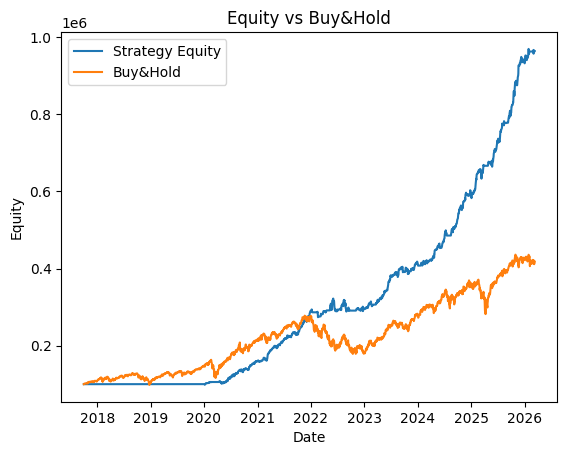

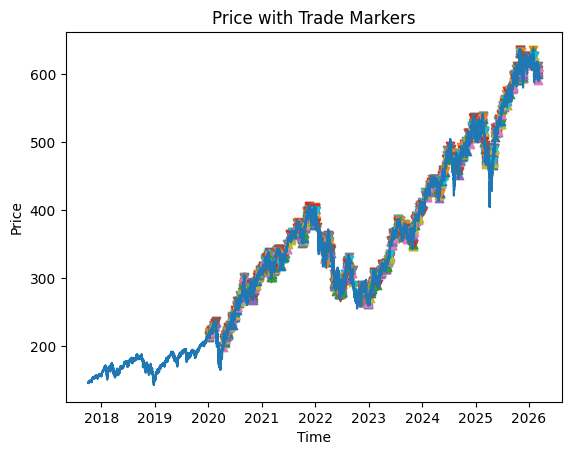

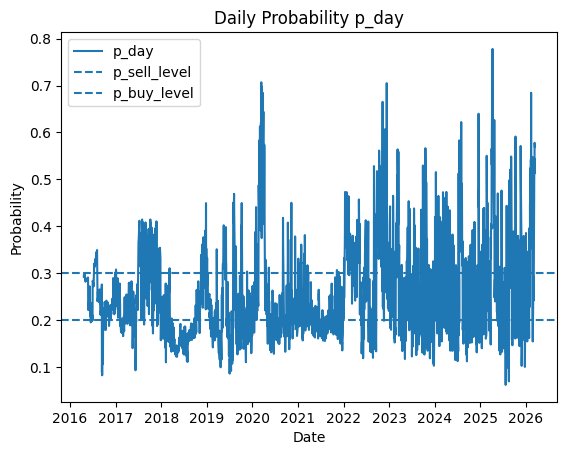

[SAVED] output_dailyprob_gated_5m_xgb_QQQ_2026_new_with_checkpointing\trades.csv
[SAVED] output_dailyprob_gated_5m_xgb_QQQ_2026_new_with_checkpointing\daily_log.csv
[SAVED] output_dailyprob_gated_5m_xgb_QQQ_2026_new_with_checkpointing\equity_vs_buyhold.png
[SAVED] output_dailyprob_gated_5m_xgb_QQQ_2026_new_with_checkpointing\price_with_trades.png
[SAVED] output_dailyprob_gated_5m_xgb_QQQ_2026_new_with_checkpointing\p_day.png
[SAVED] output_dailyprob_gated_5m_xgb_QQQ_2026_new_with_checkpointing\daily_lr_feature_importance.csv
[TRADES] total=2368
[TRADES] first_trade_ts=2020-01-06 04:00:00 (sim_start=2020-01-01 00:00:00)


In [4]:
res = run_daily_prob_then_5m_xgb_gated(
    daily_csv_path="DataAPI/data/QQQ_DAY.csv",
    k5m_csv_path="DataAPI/data/QQQ_5M.csv",
    code="QQQ",

    daily_chan_start="2015-06-01",
    accumulation_start="2017-10-01",
    sim_start="2020-01-01",
    end_time="2026-12-31",

    N_confirm=5,
    min_labeled_days_to_train=200,
    retrain_every_new_labels=25,
    dp_lookback=5,

    p_sell_level=0.30,
    p_buy_level=0.20,

    lookahead_days_5m=2.0,
    retrain_every_days_5m=5,
    min_samples_total_5m=300,

    threshold_window_days=2.0,
    threshold_ret_grid=None,
    threshold_min_open_signals=10,

    initial_capital=100000.0,
    fee_pct=0.0,

    daily_chan_max_klines=500,
    five_chan_max_klines=500,

    output_dir="output_dailyprob_gated_5m_xgb_QQQ_2026_new_with_checkpointing",
    verbose=True,

    # ✅ enable saving current process
    save_checkpoint_path="checkpoints/2019-2026_QQQ_progress_checkpoint.joblib",
    checkpoint_every_n_days=5,

    # resume_from_checkpoint_path="checkpoints/QQQ_progress_checkpoint.joblib",
    # deploy_from_bundle_path="checkpoints/QQQ_bundle_2015_2024.joblib",
    # deploy_no_retrain=True,
)

In [3]:
# ============================================================
# FULL CHECKPOINT / RESUME CODE (CLASS-FREE FOR FUTURE CHECKPOINTS)
# ============================================================
# Paste this into the SAME notebook / file where your strategy code lives.
#
# It gives you:
# 1) class-free checkpoint save/load for buy_pack / sell_pack
# 2) resume wrapper that restores full prior outputs
# 3) resumed-segment-only plots after checkpoint time
#
# IMPORTANT:
# Your existing strategy helpers must already exist in the session, including:
# - load_ohlcv_csv
# - compute_daily_kline_features
# - load_5m_index
# - compute_buy_hold_equity
# - CChanConfig / SlidingWindowChan / build_klu / feed_chan_one / etc.
# - normalize_bsp_row / extract_bsp_rows_from_chan / compute_chain_endpoints / regime_for_day_from_ends
# - latest_bsp_dir_up_to / make_daily_features_one_model / predict_prob / fit_prob_model_dicts
# - label_confirm_extreme / prepare_ml_dataset / get_feature_columns
# - train_models_two_sided_ret_only / predict_ret / choose_thresholds_global_realized
# - label_bestlookahead_for_ready_points / make_ret_grid
# - ExecutionEngine
# - gate_from_p
# - DATA_SRC / KL_TYPE / AUTYPE
#
# Also:
# - This code defines RetModelPack so OLD checkpoints can still load.
# - FUTURE checkpoints will save buy_pack/sell_pack as plain dicts.
# ============================================================

import os
import copy
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import datetime
from dataclasses import dataclass
from typing import List, Optional, Any
import xgboost as xgb


# ============================================================
# BACKWARD-COMPAT CLASS DEFINITIONS
# ============================================================

@dataclass
class RetModelPack:
    feature_cols: List[str]
    model_ret: xgb.XGBRegressor

@dataclass
class DailyProbState:
    model: Optional[Any] = None
    new_labels: int = 0
    trained_n: int = 0


# ============================================================
# LOW-LEVEL SAVE / LOAD HELPERS
# ============================================================

def save_joblib(path: str, obj):
    os.makedirs(os.path.dirname(path), exist_ok=True)
    joblib.dump(obj, path, compress=3)

def load_joblib(path: str):
    return joblib.load(path)

def _safe_copy_list_of_dict(lst):
    if lst is None:
        return []
    out = []
    for x in lst:
        try:
            out.append(dict(x))
        except Exception:
            pass
    return out

def _safe_set_to_list(s):
    if s is None:
        return []
    return list(s)

def _safe_list_to_set(lst):
    if lst is None:
        return set()
    out = set()
    for x in lst:
        if isinstance(x, list):
            out.add(tuple(x))
        else:
            out.add(x)
    return out


# ============================================================
# CLASS-FREE SERIALIZATION HELPERS
# ============================================================

def pack_ret_modelpack_for_save(pack):
    """
    Convert RetModelPack -> plain dict for checkpoint save.
    """
    if pack is None:
        return None
    return {
        "__type__": "RetModelPack",
        "feature_cols": list(pack.feature_cols),
        "model_ret": pack.model_ret,
    }

def unpack_ret_modelpack_from_load(obj):
    """
    Convert plain dict -> RetModelPack after checkpoint load.
    Backward compatible: if obj is already a RetModelPack, return as-is.
    """
    if obj is None:
        return None

    if isinstance(obj, dict) and obj.get("__type__") == "RetModelPack":
        return RetModelPack(
            feature_cols=list(obj["feature_cols"]),
            model_ret=obj["model_ret"],
        )

    # backward compatibility for old checkpoints that still store class objects
    return obj


# ============================================================
# CHECKPOINT BUNDLE BUILD / LOAD
# ============================================================

def build_checkpoint_bundle(
    *,
    code: str,
    checkpoint_time: str,

    original_daily_chan_start: str,
    original_accumulation_start: str,
    original_sim_start: str,
    original_end_time: str,

    daily_prob_model,
    daily_prob_trained_n: int,
    X_days,
    y_days,
    pending_idx,
    p_by_day,
    p_series,
    dp_vs_minK_series,
    dp_vs_maxK_series,
    bsp_rows_daily,
    seen_bsp_daily,

    buy_pack,
    sell_pack,
    buy_ret_th_live: float,
    sell_ret_th_live: float,

    bsp_rows_5m,
    seen_keys_5m,

    engine_state: dict,
    daily_log,

    daily_i_last: int,
    five_i_last: int,
    current_day,

    warmup_daily_bars: pd.DataFrame,
    warmup_5m_bars: pd.DataFrame,

    daily_chan_max_klines: int,
    five_chan_max_klines: int,
):
    p_by_day_str = {}
    if p_by_day is not None:
        for k, v in p_by_day.items():
            try:
                p_by_day_str[str(pd.to_datetime(k))] = float(v)
            except Exception:
                pass

    bundle = {
        "schema": "chan_xgb_dailyprob_checkpoint_v3",
        "code": code,
        "checkpoint_time": checkpoint_time,

        "original_daily_chan_start": str(original_daily_chan_start),
        "original_accumulation_start": str(original_accumulation_start),
        "original_sim_start": str(original_sim_start),
        "original_end_time": str(original_end_time),

        "daily_prob_model": daily_prob_model,
        "daily_prob_trained_n": int(daily_prob_trained_n),

        "X_days": copy.deepcopy(X_days),
        "y_days": copy.deepcopy(y_days),
        "pending_idx": copy.deepcopy(pending_idx),

        "p_by_day_str": p_by_day_str,
        "p_series": np.asarray(p_series, dtype=float),
        "dp_vs_minK_series": np.asarray(dp_vs_minK_series, dtype=float),
        "dp_vs_maxK_series": np.asarray(dp_vs_maxK_series, dtype=float),

        "bsp_rows_daily": _safe_copy_list_of_dict(bsp_rows_daily),
        "seen_bsp_daily_list": _safe_set_to_list(seen_bsp_daily),

        # class-free for future checkpoints
        "buy_pack": pack_ret_modelpack_for_save(buy_pack),
        "sell_pack": pack_ret_modelpack_for_save(sell_pack),

        "buy_ret_th_live": float(buy_ret_th_live),
        "sell_ret_th_live": float(sell_ret_th_live),

        "bsp_rows_5m": _safe_copy_list_of_dict(bsp_rows_5m),
        "seen_keys_5m_list": _safe_set_to_list(seen_keys_5m),

        "engine_state": copy.deepcopy(engine_state),
        "daily_log": copy.deepcopy(daily_log),

        "daily_i_last": int(daily_i_last),
        "five_i_last": int(five_i_last),
        "current_day": None if current_day is None else str(current_day),

        "warmup_daily_bars": warmup_daily_bars.reset_index(drop=True),
        "warmup_5m_bars": warmup_5m_bars.reset_index(drop=True),

        "daily_chan_max_klines": int(daily_chan_max_klines),
        "five_chan_max_klines": int(five_chan_max_klines),
    }
    return bundle


def load_checkpoint_bundle(path: str) -> dict:
    b = load_joblib(path)
    if not isinstance(b, dict):
        raise ValueError("Checkpoint is not a dict.")
    schema = b.get("schema", "")
    if schema not in (
        "chan_xgb_dailyprob_checkpoint_v1",
        "chan_xgb_dailyprob_checkpoint_v2",
        "chan_xgb_dailyprob_checkpoint_v3",
    ):
        raise ValueError(f"Unknown checkpoint schema: {schema}")
    return b


# ============================================================
# CHECKPOINT START-TIME INFERENCE FOR RESUMED-SEGMENT PLOTS
# ============================================================

def _load_any_csv_time_index(csv_path: str) -> pd.DataFrame:
    df = pd.read_csv(csv_path)

    ts_candidates = ["timestamp", "date", "datetime", "time"]
    ts_col = None
    for c in ts_candidates:
        if c in df.columns:
            ts_col = c
            break

    if ts_col is None:
        lower_map = {c.lower(): c for c in df.columns}
        for c in ts_candidates:
            if c.lower() in lower_map:
                ts_col = lower_map[c.lower()]
                break

    if ts_col is None:
        ts_col = df.columns[0]

    df[ts_col] = pd.to_datetime(df[ts_col], errors="coerce")
    df = df.dropna(subset=[ts_col]).sort_values(ts_col).reset_index(drop=True)
    df = df.rename(columns={ts_col: "timestamp"})
    return df


def infer_checkpoint_plot_start_time(
    ckpt: dict,
    daily_csv_path: str | None = None,
    k5m_csv_path: str | None = None,
    verbose: bool = True,
) -> pd.Timestamp | None:
    ts_keys = [
        "last_checkpoint_time",
        "last_processed_time",
        "last_processed_ts",
        "resume_time",
        "resume_ts",
        "cur_time",
        "current_time",
        "last_day_time",
        "last_day_ts",
        "last_daily_ts",
        "last_5m_ts",
        "five_ts_last",
        "day_ts_last",
        "checkpoint_time",
    ]
    for k in ts_keys:
        if k in ckpt and ckpt[k] is not None:
            try:
                ts = pd.to_datetime(ckpt[k])
                if pd.notna(ts):
                    if verbose:
                        print(f"[PLOT START] inferred from checkpoint key '{k}' = {ts}")
                    return ts
            except Exception:
                pass

    daily_idx_keys = [
        "daily_i_last",
        "day_i_last",
        "last_daily_i",
        "last_day_idx",
        "daily_idx_last",
        "current_daily_i",
        "resume_daily_i",
    ]
    if daily_csv_path is not None and os.path.exists(daily_csv_path):
        try:
            df_day = _load_any_csv_time_index(daily_csv_path)
            for k in daily_idx_keys:
                if k in ckpt and ckpt[k] is not None:
                    i = int(ckpt[k])
                    if 0 <= i < len(df_day):
                        ts = pd.to_datetime(df_day.loc[i, "timestamp"])
                        if verbose:
                            print(f"[PLOT START] inferred from daily index key '{k}' = {ts}")
                        return ts
        except Exception as e:
            if verbose:
                print(f"[PLOT START] daily index inference failed: {e}")

    five_idx_keys = [
        "five_i_last",
        "last_5m_i",
        "five_idx_last",
        "current_five_i",
        "resume_five_i",
        "seen_idx_last",
    ]
    if k5m_csv_path is not None and os.path.exists(k5m_csv_path):
        try:
            df_5m = _load_any_csv_time_index(k5m_csv_path)
            for k in five_idx_keys:
                if k in ckpt and ckpt[k] is not None:
                    i = int(ckpt[k])
                    if 0 <= i < len(df_5m):
                        ts = pd.to_datetime(df_5m.loc[i, "timestamp"])
                        if verbose:
                            print(f"[PLOT START] inferred from 5m index key '{k}' = {ts}")
                        return ts
        except Exception as e:
            if verbose:
                print(f"[PLOT START] 5m index inference failed: {e}")

    if verbose:
        print("[PLOT START] could not infer checkpoint plot start time.")
    return None


# ============================================================
# RESUMED-SEGMENT PLOTTING
# ============================================================

def plot_resumed_segment_from_checkpoint(
    res: dict,
    checkpoint_start_time: pd.Timestamp | None,
    title_prefix: str = "Resumed Run",
    output_dir: str | None = None,
):
    if "daily_log_df" not in res:
        print("res['daily_log_df'] not found, cannot plot.")
        return

    d = res["daily_log_df"].copy()

    if "timestamp" in d.columns:
        d["plot_time"] = pd.to_datetime(d["timestamp"], errors="coerce")
    elif "date" in d.columns:
        d["plot_time"] = pd.to_datetime(d["date"], errors="coerce")
    else:
        ts_candidates = [c for c in d.columns if "time" in c.lower() or "date" in c.lower()]
        if len(ts_candidates) == 0:
            print("No timestamp/date column found in daily_log_df.")
            return
        d["plot_time"] = pd.to_datetime(d[ts_candidates[0]], errors="coerce")

    d = d.dropna(subset=["plot_time"]).sort_values("plot_time").reset_index(drop=True)

    if checkpoint_start_time is not None:
        d = d[d["plot_time"] >= pd.to_datetime(checkpoint_start_time)].copy().reset_index(drop=True)

    if len(d) == 0:
        print("No rows available after checkpoint start time.")
        return

    if output_dir:
        os.makedirs(output_dir, exist_ok=True)

    # ---- plot resumed equity
    equity_col = None
    for c in ["equity", "portfolio_value", "nav", "strategy_equity"]:
        if c in d.columns:
            equity_col = c
            break

    if equity_col is not None:
        plt.figure(figsize=(16, 6))
        base_eq = float(d[equity_col].iloc[0]) if np.isfinite(d[equity_col].iloc[0]) else 1.0
        plt.plot(d["plot_time"], d[equity_col] / (base_eq + 1e-12), label="Strategy (normalized)")
        plt.title(f"{title_prefix} | Equity after checkpoint")
        plt.legend()
        plt.grid(True, alpha=0.25)
        plt.tight_layout()
        if output_dir:
            plt.savefig(os.path.join(output_dir, "resumed_equity_from_checkpoint.png"), dpi=200)
        plt.show()

    # ---- plot resumed p_day if available
    p_col = None
    for c in d.columns:
        cl = c.lower()
        if c == "p_day" or "prob" in cl or "p_" in cl:
            p_col = c
            break

    if p_col is not None:
        plt.figure(figsize=(16, 5))
        plt.plot(d["plot_time"], d[p_col], label=p_col)
        plt.title(f"{title_prefix} | Daily probability after checkpoint")
        plt.grid(True, alpha=0.25)
        plt.legend()
        plt.tight_layout()
        if output_dir:
            plt.savefig(os.path.join(output_dir, "resumed_pday_from_checkpoint.png"), dpi=200)
        plt.show()

    # ---- plot resumed trades after checkpoint
    if "trades_df" in res and isinstance(res["trades_df"], pd.DataFrame) and not res["trades_df"].empty:
        tr = res["trades_df"].copy()
        if "ts" in tr.columns:
            tr["plot_time"] = pd.to_datetime(tr["ts"], errors="coerce")
            tr = tr.dropna(subset=["plot_time"]).sort_values("plot_time").reset_index(drop=True)

            if checkpoint_start_time is not None:
                tr = tr[tr["plot_time"] >= pd.to_datetime(checkpoint_start_time)].copy().reset_index(drop=True)

            if len(tr) > 0 and "exec_px" in tr.columns:
                plt.figure(figsize=(16, 6))
                buys = tr[tr["side"].astype(str).str.lower() == "buy"]
                sells = tr[tr["side"].astype(str).str.lower() == "sell"]

                if len(buys):
                    plt.scatter(buys["plot_time"], buys["exec_px"], marker="^", label="Buy")
                if len(sells):
                    plt.scatter(sells["plot_time"], sells["exec_px"], marker="v", label="Sell")

                plt.title(f"{title_prefix} | Trades after checkpoint")
                plt.grid(True, alpha=0.25)
                plt.legend()
                plt.tight_layout()
                if output_dir:
                    plt.savefig(os.path.join(output_dir, "resumed_trades_from_checkpoint.png"), dpi=200)
                plt.show()


# ============================================================
# PATCHED MAIN STRATEGY RUNNER
# ============================================================
# Replace your current runner with this version if you want the
# full checkpoint/resume behavior.
# The trading logic is the same shape as before; the key changes are:
# - class-free save of buy_pack / sell_pack
# - restore of prior daily_log
# - save outputs into new folder on resume
# - defensive handling of old/new checkpoints
# ============================================================

def run_daily_prob_then_5m_xgb_gated(
    daily_csv_path: str,
    k5m_csv_path: str,
    code: str = "QQQ",

    daily_chan_start: str = "2016-06-01",
    accumulation_start: str = "2018-10-01",
    sim_start: str = "2019-01-01",
    end_time: str = "2019-12-30",

    N_confirm: int = 5,
    min_labeled_days_to_train: int = 200,
    retrain_every_new_labels: int = 25,
    dp_lookback: int = 5,

    p_sell_level: float = 0.30,
    p_buy_level: float = 0.20,

    bar_interval_minutes: int = 5,
    lookahead_days_5m: float = 2.0,
    retrain_every_days_5m: int = 5,
    min_samples_total_5m: int = 300,

    threshold_window_days: float = 2.0,
    threshold_ret_grid=None,
    threshold_min_open_signals: int = 10,

    initial_capital: float = 100000.0,
    fee_pct: float = 0.0,

    daily_chan_max_klines: int = 500,
    five_chan_max_klines: int = 20000,

    output_dir: str = "output_dailyprob_gated_5m_xgb",
    verbose: bool = True,

    save_checkpoint_path: str | None = None,
    checkpoint_every_n_days: int = 1,
    resume_from_checkpoint_path: str | None = None,
):
    os.makedirs(output_dir, exist_ok=True)

    # ----------------------------
    # Load raw data
    # ----------------------------
    df_day_raw = load_ohlcv_csv(daily_csv_path, "DAILY")
    df_5m_raw  = load_ohlcv_csv(k5m_csv_path, "5M")

    daily_s = pd.to_datetime(daily_chan_start)
    acc_s   = pd.to_datetime(accumulation_start)
    sim_s   = pd.to_datetime(sim_start)
    end_t   = pd.to_datetime(end_time)

    df_day = df_day_raw[(df_day_raw["timestamp"] >= daily_s) & (df_day_raw["timestamp"] <= end_t)].copy().reset_index(drop=True)
    if df_day.empty:
        raise ValueError("No daily bars in requested range.")
    df_day_feat = compute_daily_kline_features(df_day)

    df_5m = df_5m_raw[(df_5m_raw["timestamp"] >= acc_s) & (df_5m_raw["timestamp"] <= end_t + pd.Timedelta(days=1))].copy()
    df_5m = df_5m.sort_values("timestamp").reset_index(drop=True)

    df_5m_idx, next_open_by_idx, next_close_by_idx, closes, highs, lows, day_close_map, all_days = load_5m_index(
        df_5m, accumulation_start, end_time
    )
    buy_hold = compute_buy_hold_equity(day_close_map, all_days, initial_capital)

    # ----------------------------
    # Chan config / objects
    # ----------------------------
    config = CChanConfig({
        "cal_demark": True,
        "cal_kdj": True,
        "cal_dmi": True,
        "cal_rsi": True,
        "cal_rsl": True,
        "cal_demand_index": True,
        "cal_adline": True,
        "cal_bb_vals": True,
        "cal_kc_vals": True,
        "cal_starc_vals": True,
        "bi_strict": True,
        "trigger_step": True,
        "skip_step": 0,
        "divergence_rate": float("inf"),
        "bsp2_follow_1": True,
        "bsp3_follow_1": False,
        "min_zs_cnt": 0,
        "bs1_peak": False,
        "macd_algo": "peak",
        "bs_type": "1,2,3a,1p,2s,3b",
        "print_warning": False,
        "zs_algo": "normal",
    })

    daily_chan = SlidingWindowChan(
        code=code,
        begin_time=None,
        end_time=None,
        data_src=getattr(DATA_SRC, "CSV", "CSV"),
        lv_list=[KL_TYPE.K_DAY],
        config=config,
        autype=AUTYPE.QFQ,
        max_klines=int(daily_chan_max_klines),
    )

    chan_5m = SlidingWindowChan(
        code=code,
        begin_time=None,
        end_time=None,
        data_src=getattr(DATA_SRC, "CSV", "CSV"),
        lv_list=[KL_TYPE.K_5M],
        config=config,
        autype=AUTYPE.QFQ,
        max_klines=int(five_chan_max_klines),
    )

    # ----------------------------
    # Fresh state defaults
    # ----------------------------
    bsp_rows_daily = []
    seen_bsp_daily = set()

    X_days = []
    y_days = []
    st = DailyProbState()
    pending_idx = []

    p_series = np.full(len(df_day_feat), np.nan, dtype=float)
    dp_vs_minK_series = np.full(len(df_day_feat), np.nan, dtype=float)
    dp_vs_maxK_series = np.full(len(df_day_feat), np.nan, dtype=float)
    p_by_day = {}

    engine = ExecutionEngine(initial_capital=initial_capital, fee_pct=fee_pct)
    bsp_rows_5m = []
    seen_keys_5m = set()
    buy_pack = None
    sell_pack = None
    last_train_day = None

    if threshold_ret_grid is None:
        threshold_ret_grid = make_ret_grid(-0.5, 2.5, 0.05)
    buy_ret_th_live = 0.30
    sell_ret_th_live = 0.30

    daily_i_start = 0
    five_i_start = 0
    current_day = None
    daily_log = []

    # ----------------------------
    # Resume restore
    # ----------------------------
    if resume_from_checkpoint_path is not None and os.path.exists(resume_from_checkpoint_path):
        B = load_checkpoint_bundle(resume_from_checkpoint_path)
        if verbose:
            print(f"[RESUME] loading checkpoint: {resume_from_checkpoint_path} @ {B.get('checkpoint_time')}")

        st.model = B.get("daily_prob_model", None)
        st.trained_n = int(B.get("daily_prob_trained_n", 0))
        st.new_labels = 0

        X_days = B.get("X_days", []) or []
        y_days = B.get("y_days", []) or []
        pending_idx = B.get("pending_idx", []) or []

        p_series_loaded = B.get("p_series", None)
        if p_series_loaded is not None and len(p_series_loaded) == len(p_series):
            p_series = np.asarray(p_series_loaded, dtype=float)

        dp_min_loaded = B.get("dp_vs_minK_series", None)
        dp_max_loaded = B.get("dp_vs_maxK_series", None)
        if dp_min_loaded is not None and len(dp_min_loaded) == len(dp_vs_minK_series):
            dp_vs_minK_series = np.asarray(dp_min_loaded, dtype=float)
        if dp_max_loaded is not None and len(dp_max_loaded) == len(dp_vs_maxK_series):
            dp_vs_maxK_series = np.asarray(dp_max_loaded, dtype=float)

        p_by_day_str = B.get("p_by_day_str", {}) or {}
        p_by_day = {pd.to_datetime(k).normalize(): float(v) for k, v in p_by_day_str.items()}

        bsp_rows_daily = B.get("bsp_rows_daily", []) or []
        seen_bsp_daily = _safe_list_to_set(B.get("seen_bsp_daily_list", []))

        # class-free load, backward compatible with old checkpoints
        buy_pack = unpack_ret_modelpack_from_load(B.get("buy_pack", None))
        sell_pack = unpack_ret_modelpack_from_load(B.get("sell_pack", None))
        buy_ret_th_live = float(B.get("buy_ret_th_live", buy_ret_th_live))
        sell_ret_th_live = float(B.get("sell_ret_th_live", sell_ret_th_live))

        bsp_rows_5m = B.get("bsp_rows_5m", []) or []
        seen_keys_5m = _safe_list_to_set(B.get("seen_keys_5m_list", []))

        engine.load_state_dict(B.get("engine_state", {}) or {})
        daily_log = B.get("daily_log", []) or []

        daily_i_start = int(B.get("daily_i_last", -1)) + 1
        five_i_start = int(B.get("five_i_last", -1)) + 1

        cur_day_s = B.get("current_day", None)
        current_day = None if cur_day_s is None else datetime.date.fromisoformat(cur_day_s)

        warm_day = B.get("warmup_daily_bars", None)
        if warm_day is not None and len(warm_day):
            for _, rr in warm_day.iterrows():
                ts = pd.to_datetime(rr["timestamp"])
                daily_chan.process_new_kline(build_klu(ts, rr["_open"], rr["_high"], rr["_low"], rr["_close"], rr.get("_vol", 0.0)))

        warm_5m = B.get("warmup_5m_bars", None)
        if warm_5m is not None and len(warm_5m):
            for _, rr in warm_5m.iterrows():
                ts = pd.to_datetime(rr["timestamp"])
                feed_chan_one(chan_5m, build_klu(ts, rr["_open"], rr["_high"], rr["_low"], rr["_close"], rr.get("_vol", 0.0)))

        if verbose:
            print(f"[RESUME] daily_i_start={daily_i_start} / {len(df_day_feat)}")
            print(f"[RESUME] five_i_start={five_i_start} / {len(df_5m_idx)}")
            print(f"[RESUME] daily_model={'YES' if st.model is not None else 'NO'} "
                  f"5m_buy={'YES' if buy_pack else 'NO'} 5m_sell={'YES' if sell_pack else 'NO'}")

    # ----------------------------
    # Daily trainer helper
    # ----------------------------
    def maybe_train_daily():
        if len(y_days) < int(min_labeled_days_to_train):
            return
        if st.model is None or st.new_labels >= int(retrain_every_new_labels):
            y = np.asarray(y_days, dtype=int)
            if len(np.unique(y)) < 2:
                return
            try:
                st.model = fit_prob_model_dicts(X_days, y)
                st.trained_n = len(y)
                st.new_labels = 0
                if verbose:
                    print(f"[TRAIN][DAILY-PROB] n={len(y)} pos={int(y.sum())} ({y.mean():.2%})")
            except Exception as e:
                if verbose:
                    print(f"[TRAIN][DAILY-PROB] skipped: {e}")

    # ----------------------------
    # Save checkpoint helper
    # ----------------------------
    def save_checkpoint(now_ts: pd.Timestamp, daily_i_last: int, five_i_last: int, current_day):
        nonlocal daily_log
        if save_checkpoint_path is None:
            return

        warm_daily = df_day_raw[df_day_raw["timestamp"] <= now_ts].tail(int(daily_chan_max_klines)).copy()
        warm_5m = df_5m_raw[df_5m_raw["timestamp"] <= now_ts].tail(int(five_chan_max_klines)).copy()

        bundle = build_checkpoint_bundle(
            code=code,
            checkpoint_time=str(now_ts),

            original_daily_chan_start=str(daily_chan_start),
            original_accumulation_start=str(accumulation_start),
            original_sim_start=str(sim_start),
            original_end_time=str(end_time),

            daily_prob_model=st.model,
            daily_prob_trained_n=st.trained_n,
            X_days=X_days,
            y_days=y_days,
            pending_idx=pending_idx,
            p_by_day=p_by_day,
            p_series=p_series,
            dp_vs_minK_series=dp_vs_minK_series,
            dp_vs_maxK_series=dp_vs_maxK_series,
            bsp_rows_daily=bsp_rows_daily,
            seen_bsp_daily=seen_bsp_daily,

            buy_pack=buy_pack,
            sell_pack=sell_pack,
            buy_ret_th_live=buy_ret_th_live,
            sell_ret_th_live=sell_ret_th_live,

            bsp_rows_5m=bsp_rows_5m,
            seen_keys_5m=seen_keys_5m,

            engine_state=engine.state_dict(),
            daily_log=daily_log,

            daily_i_last=daily_i_last,
            five_i_last=five_i_last,
            current_day=current_day,

            warmup_daily_bars=warm_daily[["timestamp","_open","_high","_low","_close","_vol"]].reset_index(drop=True),
            warmup_5m_bars=warm_5m[["timestamp","_open","_high","_low","_close","_vol"]].reset_index(drop=True),

            daily_chan_max_klines=daily_chan_max_klines,
            five_chan_max_klines=five_chan_max_klines,
        )

        save_joblib(save_checkpoint_path, bundle)
        if verbose:
            print(f"[CHECKPOINT] saved -> {save_checkpoint_path} @ {now_ts}")

    # ----------------------------
    # DAILY PHASE
    # ----------------------------
    for i in range(daily_i_start, len(df_day_feat)):
        r = df_day_feat.loc[i]
        ts = pd.to_datetime(r["timestamp"])
        day = ts.normalize()

        daily_chan.process_new_kline(build_klu(ts, r["_open"], r["_high"], r["_low"], r["_close"], r["_vol"]))

        new_bsp = extract_bsp_rows_from_chan(daily_chan)
        if new_bsp:
            for rr0 in new_bsp:
                rr = normalize_bsp_row(dict(rr0))
                rr.setdefault("timestamp", ts)
                key = (pd.to_datetime(rr["timestamp"]).strftime("%Y-%m-%d"), rr["direction"], rr.get("bsp_type", "?"))
                if key in seen_bsp_daily:
                    continue
                seen_bsp_daily.add(key)
                bsp_rows_daily.append(rr)

        ends = compute_chain_endpoints(bsp_rows_daily)
        regime = regime_for_day_from_ends(day, ends)
        base_dir_today = latest_bsp_dir_up_to(bsp_rows_daily, ts)

        p_val = np.nan
        if st.model is not None:
            bsp_hist = [b for b in bsp_rows_daily if pd.to_datetime(b["timestamp"]) <= ts]
            feat_i = make_daily_features_one_model(
                kline_row=r,
                bsp_hist_up_to_day=bsp_hist,
                p_val=0.0,
                dp_minK=0.0,
                dp_maxK=0.0,
                regime=regime,
                base_dir=base_dir_today,
            )
            p_val = float(predict_prob(st.model, [feat_i])[0])
            p_series[i] = p_val
            p_by_day[day] = p_val

        lb = int(dp_lookback)
        p_minK = np.nan
        p_maxK = np.nan
        if lb > 0 and i >= 1 and np.isfinite(p_val):
            start = max(0, i - lb)
            prev = pd.Series(p_series[start:i]).dropna()
            if len(prev) > 0:
                p_minK = float(prev.min())
                p_maxK = float(prev.max())

        dp_vs_minK = (p_val - p_minK) if (np.isfinite(p_val) and np.isfinite(p_minK)) else np.nan
        dp_vs_maxK = (p_val - p_maxK) if (np.isfinite(p_val) and np.isfinite(p_maxK)) else np.nan
        dp_vs_minK_series[i] = dp_vs_minK
        dp_vs_maxK_series[i] = dp_vs_maxK

        pending_idx.append(i)
        while pending_idx and i >= pending_idx[0] + int(N_confirm):
            j = pending_idx.pop(0)
            t0 = pd.to_datetime(df_day_feat.loc[j, "timestamp"])
            base_dir_j = latest_bsp_dir_up_to(bsp_rows_daily, t0)
            if base_dir_j not in ("buy", "sell"):
                continue

            y = label_confirm_extreme(df_day_feat, j, int(N_confirm), base_dir_j)
            if y is None:
                continue

            ends_j = compute_chain_endpoints([b for b in bsp_rows_daily if pd.to_datetime(b["timestamp"]) <= t0])
            regime_j = regime_for_day_from_ends(t0.normalize(), ends_j)

            bsp_hist_j = [b for b in bsp_rows_daily if pd.to_datetime(b["timestamp"]) <= t0]
            feat_j = make_daily_features_one_model(
                kline_row=df_day_feat.loc[j],
                bsp_hist_up_to_day=bsp_hist_j,
                p_val=float(p_series[j]) if np.isfinite(p_series[j]) else 0.0,
                dp_minK=float(dp_vs_minK_series[j]) if np.isfinite(dp_vs_minK_series[j]) else 0.0,
                dp_maxK=float(dp_vs_maxK_series[j]) if np.isfinite(dp_vs_maxK_series[j]) else 0.0,
                regime=regime_j,
                base_dir=base_dir_j,
            )

            X_days.append(feat_j)
            y_days.append(int(y))
            st.new_labels += 1

        maybe_train_daily()

    feat_imp_path = os.path.join(output_dir, "daily_lr_feature_importance.csv")
    if st.model is not None:
        try:
            imp_df = feature_importance_from_lr(st.model, top_n=120)
            imp_df.to_csv(feat_imp_path, index=False)
            if verbose:
                print(f"[SAVED] {feat_imp_path}")
        except Exception as e:
            if verbose:
                print(f"[IMP][DAILY-PROB] skipped: {e}")

    # ----------------------------
    # 5M PHASE
    # ----------------------------
    if verbose:
        print(f"[PHASE2/3] 5m feed begins at accumulation_start={acc_s.date()}, trading starts at sim_s={sim_s.date()}")

    def maybe_retrain_5m(day_ts: pd.Timestamp):
        nonlocal buy_pack, sell_pack, last_train_day
        if last_train_day is not None and (day_ts - last_train_day).days < int(retrain_every_days_5m):
            return
        dfb = pd.DataFrame(bsp_rows_5m)
        if dfb.empty:
            return
        dfb2 = prepare_ml_dataset(dfb)
        feat_cols = get_feature_columns(dfb2)
        bp, sp = train_models_two_sided_ret_only(dfb2, feat_cols, min_samples_total=min_samples_total_5m)
        if bp is not None:
            buy_pack = bp
        if sp is not None:
            sell_pack = sp
        if (bp is not None) or (sp is not None):
            last_train_day = day_ts
            if verbose:
                print(f"[TRAIN][5M] asof={day_ts.date()} feats={len(feat_cols)} buy={'YES' if bp else 'NO'} sell={'YES' if sp else 'NO'} rows={len(dfb2)}")

    def maybe_opt_thresholds(asof_bar_idx: int):
        nonlocal buy_ret_th_live, sell_ret_th_live
        if buy_pack is None or sell_pack is None:
            return
        out = choose_thresholds_global_realized(
            df_5m=df_5m_idx,
            bsp_rows=bsp_rows_5m,
            buy_pack=buy_pack,
            sell_pack=sell_pack,
            asof_bar_idx=asof_bar_idx,
            window_days=threshold_window_days,
            ret_grid=threshold_ret_grid,
            next_open_by_idx=next_open_by_idx,
            closes=closes,
            fee_pct=fee_pct,
            min_open_signals=threshold_min_open_signals,
        )
        if out is not None:
            buy_ret_th_live, sell_ret_th_live = out
            if verbose:
                print(f"[TH-OPT][GLOBAL] asof_bar={asof_bar_idx} buy_th={buy_ret_th_live:.2f} sell_th={sell_ret_th_live:.2f}")

    sim_start_ts = pd.to_datetime(sim_start)
    last_day_end_idx = None
    day_gate = "NO_P"
    must_trade_dir = None
    allow_buy = True
    allow_sell = True
    days_since_checkpoint = 0

    for i in range(five_i_start, len(df_5m_idx)):
        bar_ts = pd.to_datetime(df_5m_idx.loc[i, "timestamp"])
        bar_day = bar_ts.date()
        in_sim = (bar_ts >= sim_start_ts)

        if current_day is None:
            current_day = bar_day
            p_day = p_by_day.get(pd.to_datetime(bar_day), np.nan)
            day_gate = gate_from_p(p_day, p_sell_level, p_buy_level)

            allow_buy = True
            allow_sell = True
            must_trade_dir = None

            if day_gate == "FORCE_BUY":
                allow_sell = False
                if engine.pos == 0:
                    must_trade_dir = "buy"
            elif day_gate == "FORCE_SELL":
                allow_buy = False
                if engine.pos == 1:
                    must_trade_dir = "sell"

        if bar_day != current_day:
            prev_day = current_day
            prev_day_ts = pd.to_datetime(prev_day)

            label_bestlookahead_for_ready_points(
                bsp_rows=bsp_rows_5m,
                highs=highs, lows=lows, closes=closes,
                lookahead_days=lookahead_days_5m,
                bar_interval_minutes=bar_interval_minutes,
                current_bar_idx=i,
            )

            maybe_retrain_5m(prev_day_ts)
            if last_day_end_idx is not None:
                maybe_opt_thresholds(last_day_end_idx)

            day_close = day_close_map.get(prev_day)
            equity = engine.mark_to_market(day_close) if day_close is not None else engine.cash
            daily_log.append({
                "date": prev_day,
                "equity": equity,
                "cash": engine.cash,
                "pos": engine.pos,
                "buy_th": buy_ret_th_live,
                "sell_th": sell_ret_th_live,
                "p_day": float(p_by_day.get(pd.to_datetime(prev_day), np.nan)),
            })

            days_since_checkpoint += 1
            if save_checkpoint_path is not None and days_since_checkpoint >= int(checkpoint_every_n_days):
                save_checkpoint(
                    now_ts=pd.to_datetime(df_5m_idx.loc[last_day_end_idx, "timestamp"]),
                    daily_i_last=(len(df_day_feat) - 1),
                    five_i_last=int(last_day_end_idx),
                    current_day=prev_day,
                )
                days_since_checkpoint = 0

            current_day = bar_day
            p_day = p_by_day.get(pd.to_datetime(bar_day), np.nan)
            day_gate = gate_from_p(p_day, p_sell_level, p_buy_level)

            allow_buy = True
            allow_sell = True
            must_trade_dir = None

            if day_gate == "FORCE_BUY":
                allow_sell = False
                if engine.pos == 0:
                    must_trade_dir = "buy"
            elif day_gate == "FORCE_SELL":
                allow_buy = False
                if engine.pos == 1:
                    must_trade_dir = "sell"

        last_day_end_idx = i

        if in_sim:
            engine.maybe_execute_pending(next_open_by_idx)

        klu = build_klu(
            df_5m_idx.loc[i, "timestamp"],
            df_5m_idx.loc[i, "Open"], df_5m_idx.loc[i, "High"], df_5m_idx.loc[i, "Low"], df_5m_idx.loc[i, "Close"],
            df_5m_idx.loc[i, "Volume"],
        )
        feed_chan_one(chan_5m, klu)

        new_rows = extract_bsp_rows_from_chan(chan_5m)
        if not new_rows:
            continue

        for r0 in new_rows:
            r = dict(r0)
            r.setdefault("timestamp", str(bar_ts))
            r.setdefault("klu_idx", i)

            if "direction" not in r or r["direction"] is None:
                if r.get("is_buy", None) is not None:
                    r["direction"] = "buy" if bool(r["is_buy"]) else "sell"
                else:
                    r["direction"] = "buy"
            r["direction"] = str(r["direction"]).lower()
            if "bsp_type" in r and r["bsp_type"] is not None:
                r["bsp_type"] = str(r["bsp_type"]).lower()
            r.setdefault("best_return_pct", np.nan)

            k = (int(r.get("klu_idx", -1)), str(r.get("direction")), str(r.get("bsp_type")))
            if k in seen_keys_5m:
                continue
            seen_keys_5m.add(k)
            bsp_rows_5m.append(r)

            if not in_sim:
                continue

            d = str(r.get("direction", "buy")).lower()
            ki = int(r.get("klu_idx", i))

            if d == "buy" and not allow_buy:
                continue
            if d == "sell" and not allow_sell:
                continue
            if must_trade_dir is not None and d != must_trade_dir:
                continue

            if d == "buy" and engine.pos == 0 and buy_pack is not None:
                row_df = prepare_ml_dataset(pd.DataFrame([r]))
                for cc in buy_pack.feature_cols:
                    if cc not in row_df.columns:
                        row_df[cc] = 0.0
                pr = predict_ret(buy_pack, row_df)
                if pr >= float(buy_ret_th_live):
                    engine.place_order_for_next_bar(
                        side="buy",
                        seen_idx=ki,
                        reason=("FORCE_BUY->first acceptable 5m signal" if day_gate == "FORCE_BUY" else "5m BUY signal"),
                        meta={
                            "ts": str(bar_ts),
                            "p_day": float(p_by_day.get(pd.to_datetime(bar_day), np.nan)),
                            "pred": float(pr),
                            "th": float(buy_ret_th_live),
                            "gate": day_gate,
                        },
                    )
                    if must_trade_dir == "buy":
                        must_trade_dir = None

            elif d == "sell" and engine.pos == 1 and sell_pack is not None:
                row_df = prepare_ml_dataset(pd.DataFrame([r]))
                for cc in sell_pack.feature_cols:
                    if cc not in row_df.columns:
                        row_df[cc] = 0.0
                pr = predict_ret(sell_pack, row_df)
                if pr >= float(sell_ret_th_live):
                    engine.place_order_for_next_bar(
                        side="sell",
                        seen_idx=ki,
                        reason=("FORCE_SELL->first acceptable 5m signal" if day_gate == "FORCE_SELL" else "5m SELL signal"),
                        meta={
                            "ts": str(bar_ts),
                            "p_day": float(p_by_day.get(pd.to_datetime(bar_day), np.nan)),
                            "pred": float(pr),
                            "th": float(sell_ret_th_live),
                            "gate": day_gate,
                        },
                    )
                    if must_trade_dir == "sell":
                        must_trade_dir = None

    if current_day is not None:
        day_close = day_close_map.get(current_day)
        equity = engine.mark_to_market(day_close) if day_close is not None else engine.cash
        daily_log.append({
            "date": current_day,
            "equity": equity,
            "cash": engine.cash,
            "pos": engine.pos,
            "buy_th": buy_ret_th_live,
            "sell_th": sell_ret_th_live,
            "p_day": float(p_by_day.get(pd.to_datetime(current_day), np.nan)),
        })

    if save_checkpoint_path is not None and len(df_5m_idx) > 0:
        final_ts = pd.to_datetime(df_5m_idx.loc[len(df_5m_idx)-1, "timestamp"])
        save_checkpoint(
            now_ts=final_ts,
            daily_i_last=(len(df_day_feat) - 1),
            five_i_last=(len(df_5m_idx) - 1),
            current_day=current_day,
        )

    # ----------------------------
    # Save outputs
    # ----------------------------
    trades_df = pd.DataFrame(engine.trades)
    daily_df = pd.DataFrame(daily_log)
    if not daily_df.empty:
        if "date" in daily_df.columns:
            daily_df["date"] = pd.to_datetime(daily_df["date"])
            daily_df = daily_df.sort_values("date").reset_index(drop=True)

    trades_csv = os.path.join(output_dir, "trades.csv")
    daily_csv = os.path.join(output_dir, "daily_log.csv")
    trades_df.to_csv(trades_csv, index=False)
    daily_df.to_csv(daily_csv, index=False)

    out_eq = os.path.join(output_dir, "equity_vs_buyhold.png")
    out_px = os.path.join(output_dir, "price_with_trades.png")
    out_p  = os.path.join(output_dir, "p_day.png")

    plt.figure()
    if not daily_df.empty and "date" in daily_df.columns and "equity" in daily_df.columns:
        plt.plot(daily_df["date"], daily_df["equity"], label="Strategy Equity")
    if len(buy_hold) > 0:
        plt.plot(buy_hold.index, buy_hold.values, label="Buy&Hold")
    plt.legend()
    plt.title("Equity vs Buy&Hold")
    plt.xlabel("Date")
    plt.ylabel("Equity")
    plt.savefig(out_eq, dpi=150, bbox_inches="tight")
    plt.show()

    plt.figure()
    plt.plot(df_5m_idx["timestamp"], df_5m_idx["Close"], label="5m Close")
    if not trades_df.empty and "seen_idx" in trades_df.columns and "exec_px" in trades_df.columns:
        for _, tr in trades_df.iterrows():
            idx = int(tr["seen_idx"])
            if idx in df_5m_idx.index:
                t = pd.to_datetime(df_5m_idx.loc[idx, "timestamp"])
                px = float(tr["exec_px"])
                if tr.get("side", "") == "buy":
                    plt.scatter([t], [px], marker="^")
                else:
                    plt.scatter([t], [px], marker="v")
    plt.title("Price with Trade Markers")
    plt.xlabel("Time")
    plt.ylabel("Price")
    plt.savefig(out_px, dpi=150, bbox_inches="tight")
    plt.show()

    days_sorted = sorted(p_by_day.keys())
    if days_sorted:
        plt.figure()
        xs = pd.to_datetime(days_sorted)
        ys = [p_by_day[d] for d in days_sorted]
        plt.plot(xs, ys, label="p_day")
        plt.axhline(p_sell_level, linestyle="--", label="p_sell_level")
        plt.axhline(p_buy_level, linestyle="--", label="p_buy_level")
        plt.legend()
        plt.title("Daily Probability p_day")
        plt.xlabel("Date")
        plt.ylabel("Probability")
        plt.savefig(out_p, dpi=150, bbox_inches="tight")
        plt.show()

    if verbose:
        print(f"[SAVED] {trades_csv}")
        print(f"[SAVED] {daily_csv}")
        print(f"[SAVED] {out_eq}")
        print(f"[SAVED] {out_px}")
        if days_sorted:
            print(f"[SAVED] {out_p}")
        if st.model is not None:
            print(f"[SAVED] {feat_imp_path}")
        print(f"[TRADES] total={len(trades_df)}")
        if not trades_df.empty and "seen_idx" in trades_df.columns:
            min_seen_idx = int(trades_df["seen_idx"].min())
            if min_seen_idx in df_5m_idx.index:
                ts0 = pd.to_datetime(df_5m_idx.loc[min_seen_idx, "timestamp"])
                print(f"[TRADES] first_trade_ts={ts0} (sim_start={sim_start_ts})")
            else:
                print(f"[TRADES] first_trade_seen_idx={min_seen_idx} not found in current df_5m_idx index")

    return {
        "trades_df": trades_df,
        "daily_log_df": daily_df,
        "p_by_day": p_by_day,
        "buy_hold": buy_hold,
        "output_dir": output_dir,
        "checkpoint_path": save_checkpoint_path,
    }


# ============================================================
# RESUME WRAPPER
# ============================================================

def resume_from_checkpoint(
    checkpoint_path: str,
    daily_csv_path: str,
    k5m_csv_path: str,
    end_time: str | None = None,
    output_dir: str = "output_resumed_run",
    verbose: bool = True,
    plot_from_checkpoint: bool = True,
):
    if not os.path.exists(checkpoint_path):
        raise FileNotFoundError(f"Checkpoint not found: {checkpoint_path}")

    ckpt = load_checkpoint_bundle(checkpoint_path)

    code = ckpt.get("code", "QQQ")
    original_daily_chan_start = ckpt.get("original_daily_chan_start")
    original_accumulation_start = ckpt.get("original_accumulation_start")
    original_sim_start = ckpt.get("original_sim_start")
    original_end_time = ckpt.get("original_end_time")

    if original_daily_chan_start is None or original_accumulation_start is None or original_sim_start is None:
        raise ValueError(
            "This checkpoint does not contain the original run window. "
            "It was likely created by the older checkpoint format."
        )

    final_end_time = end_time if end_time is not None else original_end_time

    checkpoint_plot_start = infer_checkpoint_plot_start_time(
        ckpt=ckpt,
        daily_csv_path=daily_csv_path,
        k5m_csv_path=k5m_csv_path,
        verbose=verbose,
    )

    if verbose:
        print(f"[RESUME WRAPPER] checkpoint={checkpoint_path}")
        print(f"[RESUME WRAPPER] code={code}")
        print(f"[RESUME WRAPPER] original_daily_chan_start={original_daily_chan_start}")
        print(f"[RESUME WRAPPER] original_accumulation_start={original_accumulation_start}")
        print(f"[RESUME WRAPPER] original_sim_start={original_sim_start}")
        print(f"[RESUME WRAPPER] original_end_time={original_end_time}")
        print(f"[RESUME WRAPPER] continue_until={final_end_time}")
        print(f"[RESUME WRAPPER] plot_from={checkpoint_plot_start}")
        print(f"[RESUME WRAPPER] output_dir={output_dir}")

    res = run_daily_prob_then_5m_xgb_gated(
        daily_csv_path=daily_csv_path,
        k5m_csv_path=k5m_csv_path,
        code=code,

        daily_chan_start=original_daily_chan_start,
        accumulation_start=original_accumulation_start,
        sim_start=original_sim_start,
        end_time=final_end_time,

        N_confirm=5,
        min_labeled_days_to_train=200,
        retrain_every_new_labels=25,
        dp_lookback=5,

        p_sell_level=0.30,
        p_buy_level=0.20,

        lookahead_days_5m=2.0,
        retrain_every_days_5m=5,
        min_samples_total_5m=300,

        threshold_window_days=2.0,
        threshold_ret_grid=None,
        threshold_min_open_signals=10,

        initial_capital=100000.0,
        fee_pct=0.0,

        daily_chan_max_klines=int(ckpt.get("daily_chan_max_klines", 500)),
        five_chan_max_klines=int(ckpt.get("five_chan_max_klines", 20000)),

        output_dir=output_dir,
        verbose=verbose,

        resume_from_checkpoint_path=checkpoint_path,
        save_checkpoint_path=checkpoint_path,
        checkpoint_every_n_days=5,
    )

    res["checkpoint_plot_start"] = checkpoint_plot_start

    if plot_from_checkpoint:
        plot_resumed_segment_from_checkpoint(
            res=res,
            checkpoint_start_time=checkpoint_plot_start,
            title_prefix=f"{code} resumed from checkpoint",
            output_dir=output_dir,
        )

    return res


# ============================================================
# EXAMPLE RESUME CALL
# ============================================================
# Run this after the rest of your strategy code is loaded.
#
# res = resume_from_checkpoint(
#     checkpoint_path="checkpoints/2019-2025_QQQ_progress_checkpoint.joblib",
#     daily_csv_path="DataAPI/data/QQQ_DAY.csv",
#     k5m_csv_path="DataAPI/data/QQQ_5M.csv",
#     end_time="2026-12-31",
#     output_dir="output_resumed_QQQ_2026",
#     verbose=True,
#     plot_from_checkpoint=True,
# )
#
# display(res["trades_df"].tail(50))
# display(res["daily_log_df"].tail(20))
# print("checkpoint_plot_start =", res.get("checkpoint_plot_start"))

[PLOT START] inferred from checkpoint key 'checkpoint_time' = 2026-03-10 19:55:00
[RESUME WRAPPER] checkpoint=checkpoints/2019-2025_QQQ_progress_checkpoint.joblib
[RESUME WRAPPER] code=QQQ
[RESUME WRAPPER] original_daily_chan_start=2014-06-01
[RESUME WRAPPER] original_accumulation_start=2016-10-01
[RESUME WRAPPER] original_sim_start=2019-01-01
[RESUME WRAPPER] original_end_time=2026-12-31
[RESUME WRAPPER] continue_until=2026-12-31
[RESUME WRAPPER] plot_from=2026-03-10 19:55:00
[RESUME WRAPPER] output_dir=output_resumed_QQQ_2026
[RESUME] loading checkpoint: checkpoints/2019-2025_QQQ_progress_checkpoint.joblib @ 2026-03-10 19:55:00
[RESUME] daily_i_start=2911 / 2911
[RESUME] five_i_start=432120 / 432120
[RESUME] daily_model=YES 5m_buy=YES 5m_sell=YES
[LABELS][DAILY-PROB] n=2853 pos=606 (21.24%)
[MODEL][DAILY-PROB] trained=yes trained_n=2850
[BSP][DAILY] total=872
[SAVED] output_resumed_QQQ_2026\daily_lr_feature_importance.csv
[PHASE2/3] 5m feed begins at accumulation_start=2016-10-01, tr

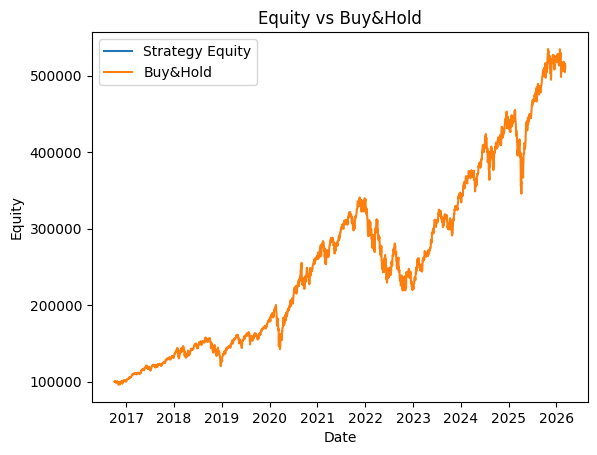

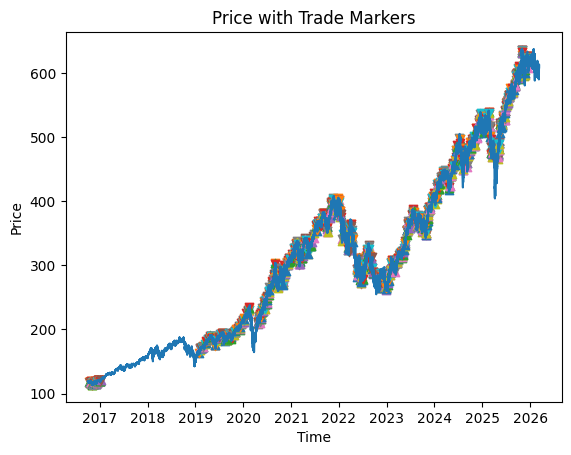

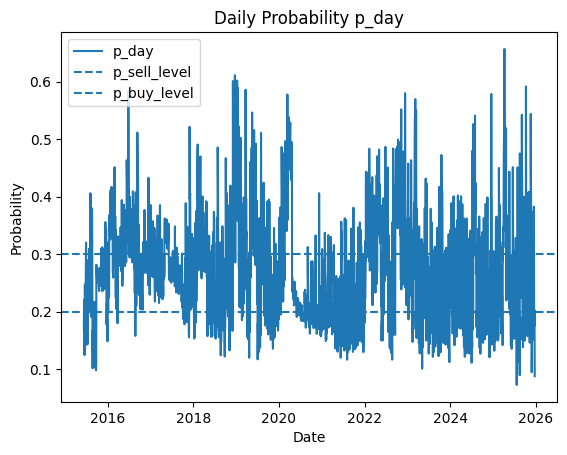

[SAVED] output_resumed_QQQ_2026\trades.csv
[SAVED] output_resumed_QQQ_2026\daily_log.csv
[SAVED] output_resumed_QQQ_2026\equity_vs_buyhold.png
[SAVED] output_resumed_QQQ_2026\price_with_trades.png
[SAVED] output_resumed_QQQ_2026\p_day.png
[SAVED] output_resumed_QQQ_2026\daily_lr_feature_importance.csv
[TRADES] total=2826
[TRADES] first_trade_ts=2016-10-06 08:00:00 (sim_start=2019-01-01 00:00:00)
No rows available after checkpoint start time.


,side,seen_idx,exec_px,qty,fee,reason,ts,p_day,pred,th,gate,pnl,entry_px,entry_idx
2776,buy,6939,118.4400,3962.695219,0.0,5m BUY signal,2026-02-19 12:45:00,NaN,3.247911,2.00,NO_P,NaN,NaN,NaN
2777,sell,6975,118.6300,3962.695219,0.0,5m SELL signal,2026-02-19 15:45:00,NaN,2.995004,2.35,NO_P,752.912092,118.4400,6939.0
2778,buy,7036,119.3600,3938.459566,0.0,5m BUY signal,2026-02-20 04:50:00,NaN,2.162960,1.90,NO_P,NaN,NaN,NaN
2779,sell,7072,119.3600,3938.459566,0.0,5m SELL signal,2026-02-20 07:50:00,NaN,23.655457,2.25,NO_P,0.000000,119.3600,7036.0
2780,buy,7083,119.4600,3935.162681,0.0,5m BUY signal,2026-02-20 08:45:00,NaN,3.361093,1.90,NO_P,NaN,NaN,NaN
2781,sell,7408,120.5600,3935.162681,0.0,5m SELL signal,2026-02-23 19:50:00,NaN,23.530476,2.20,NO_P,4328.678949,119.4600,7083.0
2782,buy,7428,120.5600,3935.162681,0.0,5m BUY signal,2026-02-24 05:30:00,NaN,1.230731,-0.50,NO_P,NaN,NaN,NaN
2783,sell,7446,120.5700,3935.162681,0.0,5m SELL signal,2026-02-24 07:00:00,NaN,23.389940,2.35,NO_P,39.351627,120.5600,7428.0
2784,buy,7453,120.4900,3937.775454,0.0,5m BUY signal,2026-02-24 07:35:00,NaN,1.403706,-0.50,NO_P,NaN,NaN,NaN
2785,sell,7487,120.6300,3937.775454,0.0,5m SELL signal,2026-02-24 10:25:00,NaN,22.728617,2.35,NO_P,551.288564,120.4900,7453.0


,date,equity,cash,pos,buy_th,sell_th
0,2026-03-10,479384.301945,479384.301945,0,-0.5,2.45


checkpoint_plot_start = 2026-03-10 19:55:00


In [6]:
res = resume_from_checkpoint(
    checkpoint_path="checkpoints/2019-2025_QQQ_progress_checkpoint.joblib",
    daily_csv_path="DataAPI/data/QQQ_DAY.csv",
    k5m_csv_path="DataAPI/data/QQQ_5M.csv",
    end_time="2026-12-31",
    output_dir="output_resumed_QQQ_2026",
    verbose=True,
    plot_from_checkpoint=True,
)

display(res["trades_df"].tail(50))
display(res["daily_log_df"].tail(20))
print("checkpoint_plot_start =", res.get("checkpoint_plot_start"))

[TRAIN][DAILY-PROB] n=200 pos=42 (21.00%)
[TRAIN][DAILY-PROB] n=225 pos=49 (21.78%)
[TRAIN][DAILY-PROB] n=250 pos=59 (23.60%)
[TRAIN][DAILY-PROB] n=275 pos=68 (24.73%)
[TRAIN][DAILY-PROB] n=300 pos=77 (25.67%)
[TRAIN][DAILY-PROB] n=325 pos=82 (25.23%)
[TRAIN][DAILY-PROB] n=350 pos=92 (26.29%)
[TRAIN][DAILY-PROB] n=375 pos=96 (25.60%)
[TRAIN][DAILY-PROB] n=400 pos=107 (26.75%)
[TRAIN][DAILY-PROB] n=425 pos=111 (26.12%)
[TRAIN][DAILY-PROB] n=450 pos=118 (26.22%)
[TRAIN][DAILY-PROB] n=475 pos=122 (25.68%)
[TRAIN][DAILY-PROB] n=500 pos=125 (25.00%)
[TRAIN][DAILY-PROB] n=525 pos=131 (24.95%)
[TRAIN][DAILY-PROB] n=550 pos=138 (25.09%)
[TRAIN][DAILY-PROB] n=575 pos=144 (25.04%)
[TRAIN][DAILY-PROB] n=600 pos=149 (24.83%)
[TRAIN][DAILY-PROB] n=625 pos=150 (24.00%)
[TRAIN][DAILY-PROB] n=650 pos=152 (23.38%)
[TRAIN][DAILY-PROB] n=675 pos=155 (22.96%)
[TRAIN][DAILY-PROB] n=700 pos=156 (22.29%)
[TRAIN][DAILY-PROB] n=725 pos=162 (22.34%)
[TRAIN][DAILY-PROB] n=750 pos=163 (21.73%)
[TRAIN][DAILY-PROB]

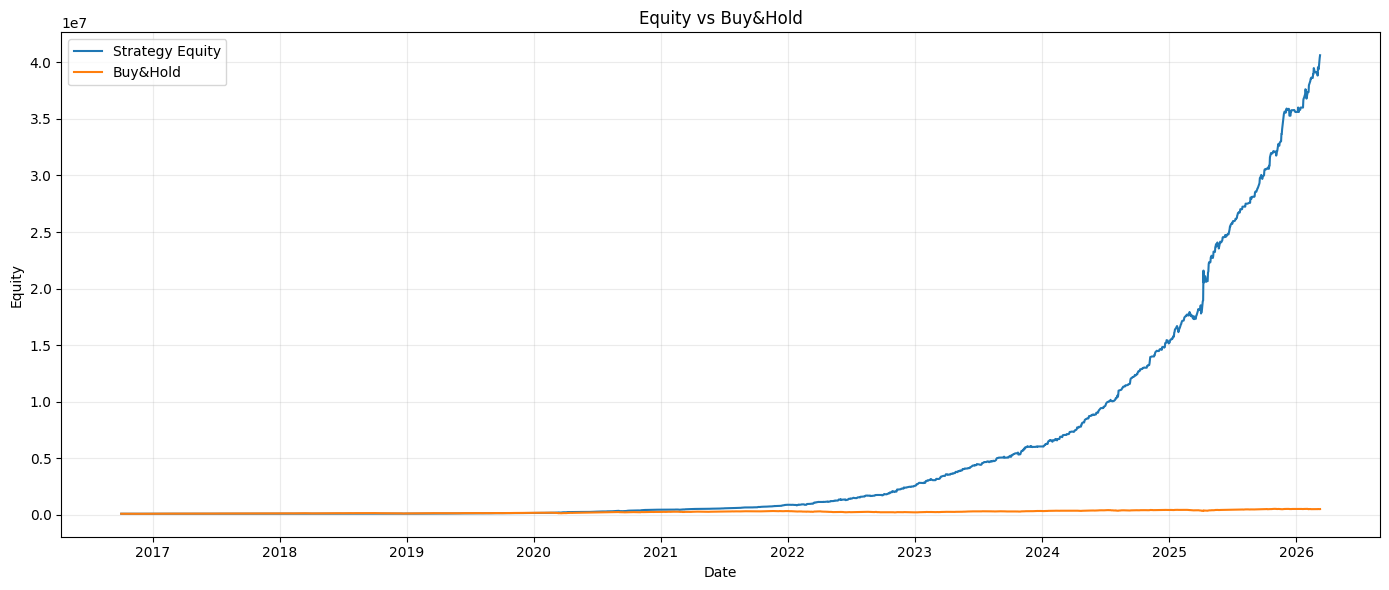

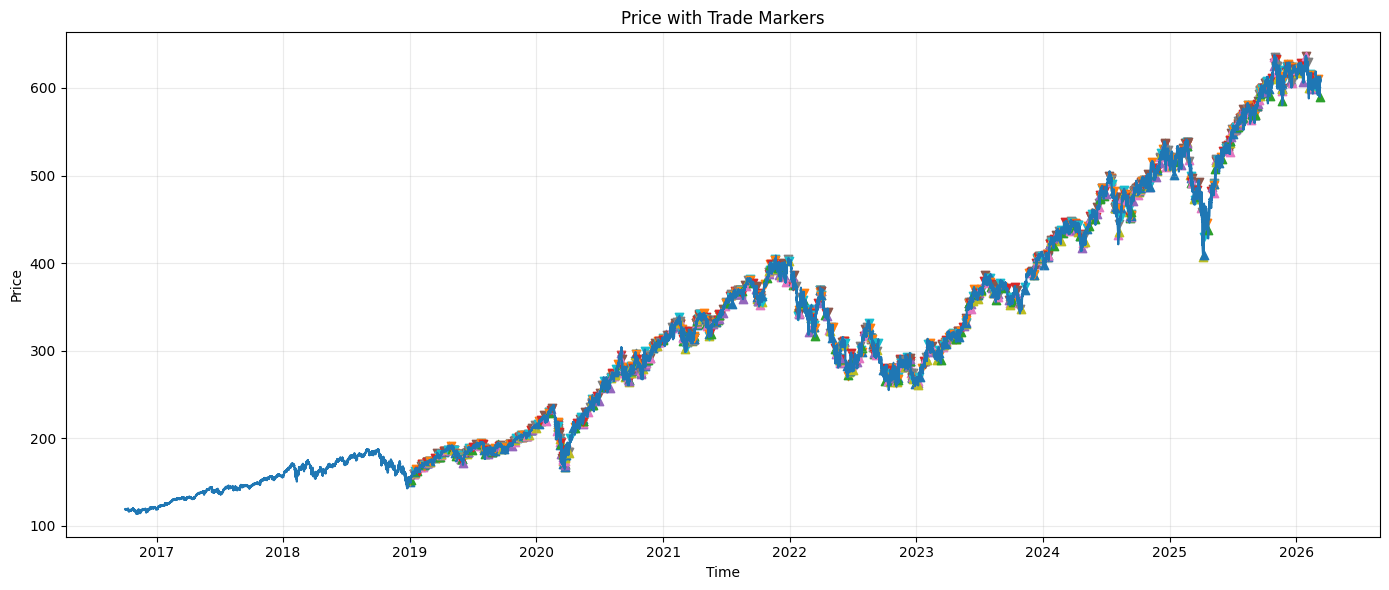

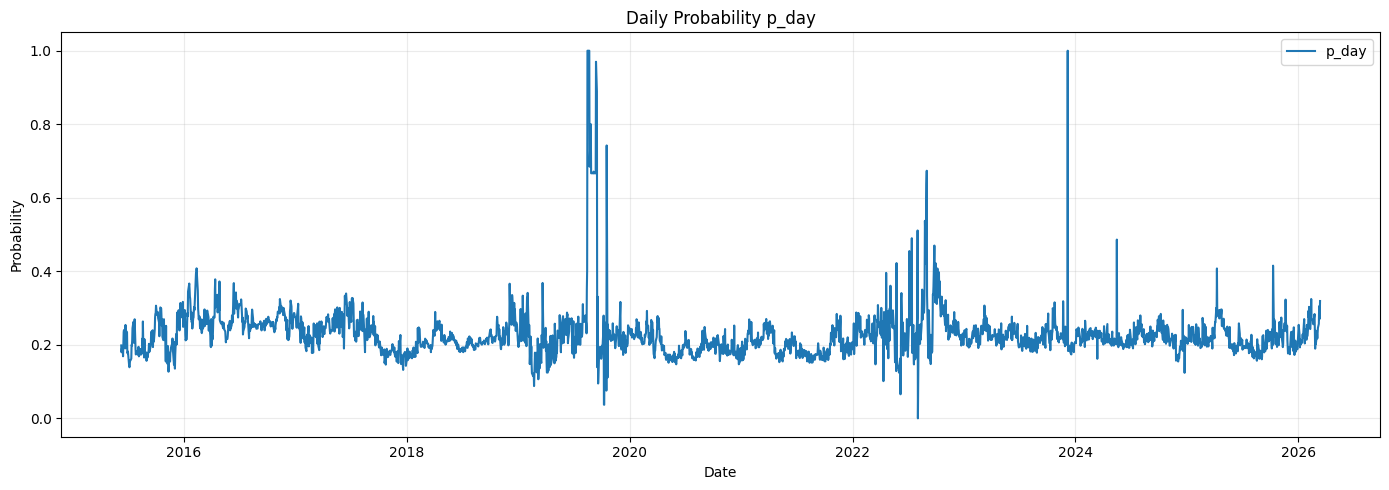

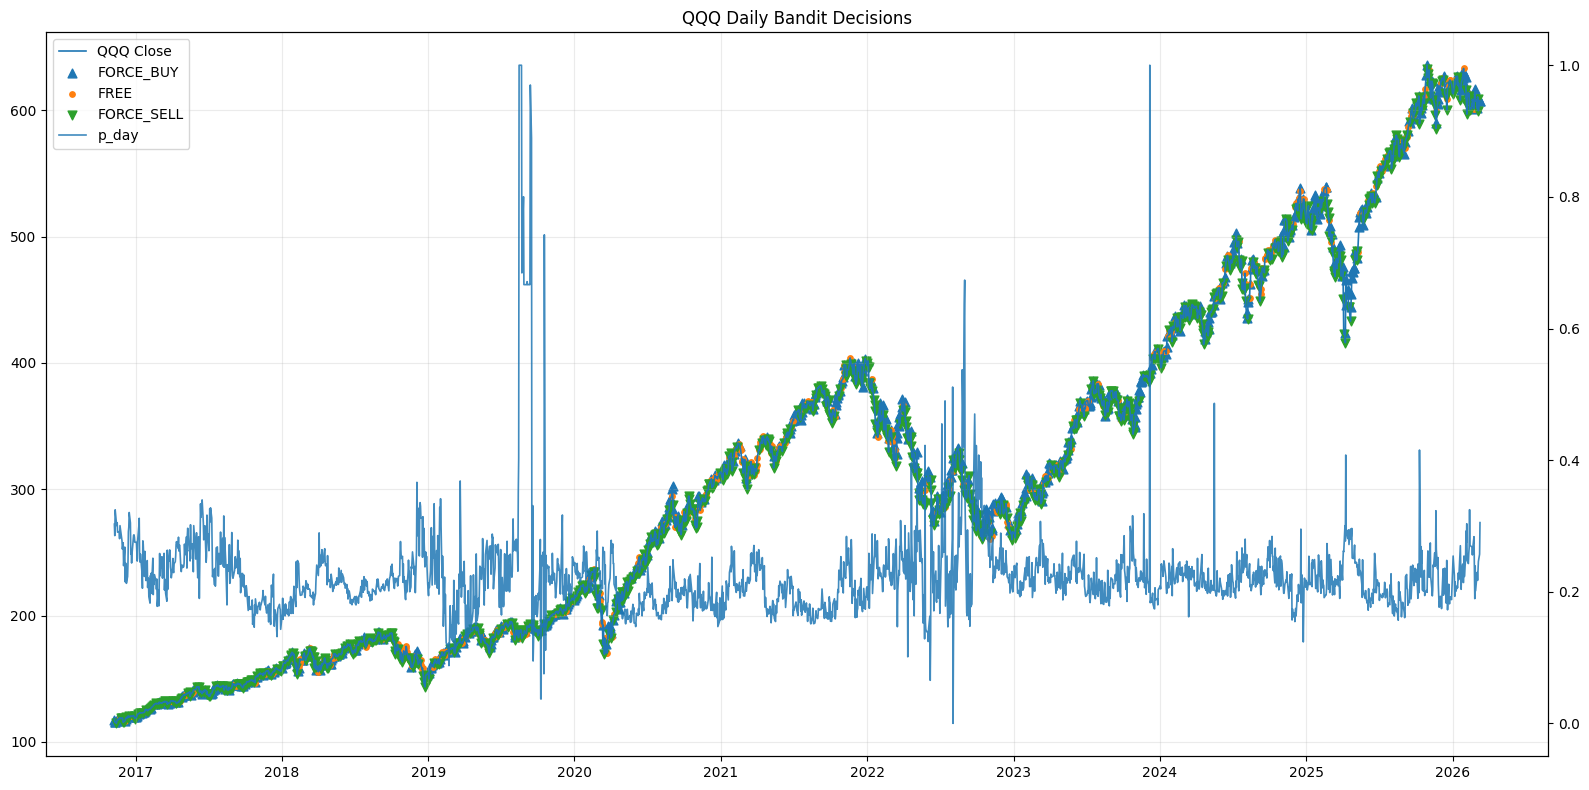

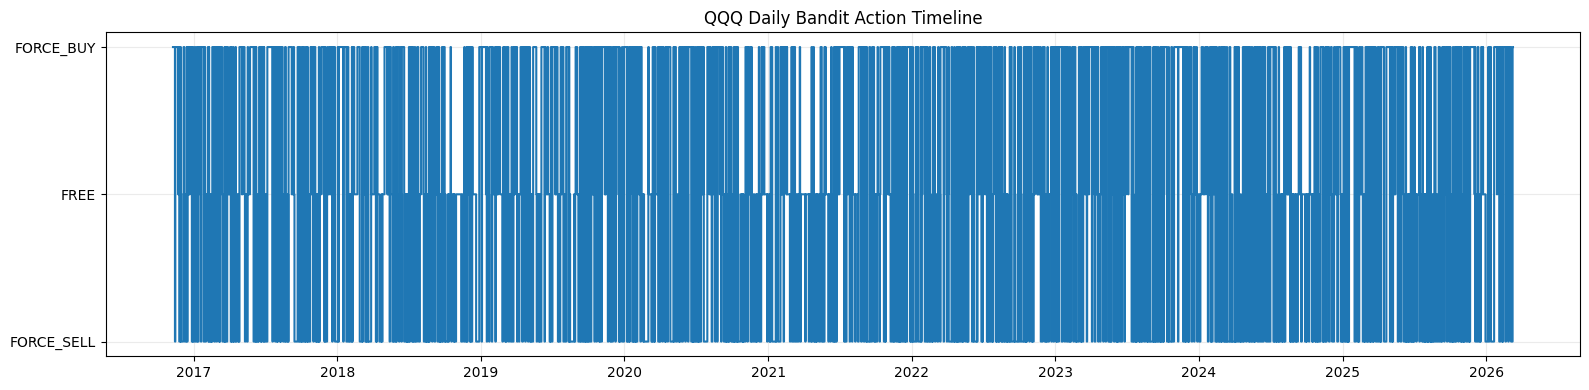

[SAVED] output_daily_bandit_5m_xgb_adaptive_QQQ\trades.csv
[SAVED] output_daily_bandit_5m_xgb_adaptive_QQQ\daily_log.csv
[SAVED] output_daily_bandit_5m_xgb_adaptive_QQQ\daily_bandit_log.csv
[SAVED] output_daily_bandit_5m_xgb_adaptive_QQQ\equity_vs_buyhold.png
[SAVED] output_daily_bandit_5m_xgb_adaptive_QQQ\price_with_trades.png
[SAVED] output_daily_bandit_5m_xgb_adaptive_QQQ\p_day.png
[SAVED] output_daily_bandit_5m_xgb_adaptive_QQQ\daily_bandit_decisions.png
[SAVED] output_daily_bandit_5m_xgb_adaptive_QQQ\daily_bandit_action_timeline.png
[TRADES] total=2053
      date chosen_action  reward_force_buy  reward_free  reward_force_sell  chosen_reward best_action_ex_post    p_day  close
2026-02-25     FORCE_BUY          0.000000     0.000000           0.000000       0.000000           FORCE_BUY 0.189584 616.68
2026-02-26    FORCE_SELL         -0.011564    -0.005916           0.000000       0.000000          FORCE_SELL 0.239205 609.24
2026-02-27     FORCE_BUY         -0.001023     0.001655   

In [5]:
# ============================================================
# COMBINED DAILY LR + DAILY BANDIT + 5M XGB SYSTEM
# ------------------------------------------------------------
# - Daily LR model produces p_day
# - Daily bandit chooses one gate each day:
#       FORCE_BUY / FREE / FORCE_SELL
# - 5m XGB model trades under that gate
# - Daily bandit learns from ACTUAL 5m-based day outcomes
#   by evaluating all 3 daily actions on the same day
# - Outputs:
#       trades.csv
#       daily_log.csv
#       daily_bandit_log.csv
#       equity_vs_buyhold.png
#       price_with_trades.png
#       p_day.png
#       daily_bandit_decisions.png
#       daily_bandit_action_timeline.png
# ============================================================

import os
import copy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xgboost as xgb

from dataclasses import dataclass
from typing import List, Optional, Any, Dict, Tuple

from sklearn.feature_extraction import DictVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.calibration import CalibratedClassifierCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MaxAbsScaler
from sklearn.impute import SimpleImputer

# ---- your Chan imports ----
from sliding_window_chan import SlidingWindowChan
from ChanConfig import CChanConfig
from Common.CEnum import DATA_FIELD, KL_TYPE, AUTYPE
try:
    from Common.CEnum import DATA_SRC
except Exception:
    class DATA_SRC:
        CSV = "CSV"
from KLine.KLine_Unit import CKLine_Unit
from Common.CTime import CTime


# ============================================================
# DATACLASSES / BANDIT
# ============================================================

@dataclass
class RetModelPack:
    feature_cols: List[str]
    model_ret: xgb.XGBRegressor

@dataclass
class DailyProbState:
    model: Optional[Any] = None
    new_labels: int = 0
    trained_n: int = 0


class BanditAction:
    FORCE_BUY = 0
    FREE = 1
    FORCE_SELL = 2


ACTION_TO_NAME = {
    BanditAction.FORCE_BUY: "FORCE_BUY",
    BanditAction.FREE: "FREE",
    BanditAction.FORCE_SELL: "FORCE_SELL",
}
NAME_TO_ACTION = {v: k for k, v in ACTION_TO_NAME.items()}


class LinUCBBandit:
    """
    Contextual bandit for daily gate decisions.
    """
    def __init__(self, n_actions: int, n_features: int, alpha: float = 0.75, l2: float = 1.0):
        self.n_actions = int(n_actions)
        self.n_features = int(n_features)
        self.alpha = float(alpha)
        self.l2 = float(l2)

        self.A = [np.eye(self.n_features, dtype=float) * self.l2 for _ in range(self.n_actions)]
        self.b = [np.zeros(self.n_features, dtype=float) for _ in range(self.n_actions)]

    def select_action(self, x: np.ndarray) -> int:
        x = np.asarray(x, dtype=float).reshape(-1)
        scores = []
        for a in range(self.n_actions):
            A_inv = np.linalg.inv(self.A[a])
            theta = A_inv @ self.b[a]
            mean = float(theta @ x)
            bonus = self.alpha * float(np.sqrt(max(0.0, x @ A_inv @ x)))
            scores.append(mean + bonus)
        return int(np.argmax(scores))

    def update(self, action: int, x: np.ndarray, reward: float):
        x = np.asarray(x, dtype=float).reshape(-1)
        a = int(action)
        r = float(reward)
        self.A[a] += np.outer(x, x)
        self.b[a] += r * x


# ============================================================
# BASIC HELPERS
# ============================================================

def _safe_div(a, b, eps=1e-12):
    return a / (b + eps)

def _pick_col(df: pd.DataFrame, candidates: List[str]) -> Optional[str]:
    cols = list(df.columns)
    for c in candidates:
        if c in cols:
            return c
    lower_map = {c.lower(): c for c in cols}
    for c in candidates:
        if c.lower() in lower_map:
            return lower_map[c.lower()]
    return None


# ============================================================
# OHLCV CSV LOADER
# ============================================================

def load_ohlcv_csv(path: str, freq_name: str) -> pd.DataFrame:
    df = pd.read_csv(path)

    ts_col = _pick_col(df, ["timestamp", "date", "datetime", "time"])
    if ts_col is None:
        ts_col = df.columns[0]
    df[ts_col] = pd.to_datetime(df[ts_col], errors="coerce")
    df = df.dropna(subset=[ts_col]).sort_values(ts_col).reset_index(drop=True)
    df = df.rename(columns={ts_col: "timestamp"})

    open_col  = _pick_col(df, ["open", "Open", "o", "O"])
    high_col  = _pick_col(df, ["high", "High", "h", "H"])
    low_col   = _pick_col(df, ["low", "Low", "l", "L"])
    close_col = _pick_col(df, ["close", "Close", "adj_close", "Adj Close", "AdjClose", "c", "C"])
    vol_col   = _pick_col(df, ["volume", "Volume", "vol", "Vol", "v", "V"])

    if open_col is None or close_col is None:
        raise ValueError(f"{freq_name} CSV must contain open/close columns.")
    if high_col is None:
        high_col = close_col
    if low_col is None:
        low_col = close_col

    df["_open"]  = pd.to_numeric(df[open_col], errors="coerce").astype(float)
    df["_high"]  = pd.to_numeric(df[high_col], errors="coerce").astype(float)
    df["_low"]   = pd.to_numeric(df[low_col], errors="coerce").astype(float)
    df["_close"] = pd.to_numeric(df[close_col], errors="coerce").astype(float)
    df["_vol"]   = pd.to_numeric(df[vol_col], errors="coerce").astype(float) if vol_col is not None else 0.0

    df = df.dropna(subset=["_open", "_high", "_low", "_close"]).reset_index(drop=True)
    df["day"] = df["timestamp"].dt.normalize()
    return df


# ============================================================
# DAILY FEATURES
# ============================================================

KLINE_KEYS = [
    "ret1","ret_5","ret_10","ret_20","ret_40",
    "vol_5","vol_10","vol_20","vol_40",
    "atr_14","range_over_atr","close_pos","gap",
    "above_ma_20","above_ma_50","above_ma_100",
    "slope40",
]

def compute_daily_kline_features(df_day: pd.DataFrame) -> pd.DataFrame:
    d = df_day.copy().sort_values("timestamp").reset_index(drop=True)
    o = d["_open"].astype(float)
    h = d["_high"].astype(float)
    l = d["_low"].astype(float)
    c = d["_close"].astype(float)

    prev_c = c.shift(1)
    d["ret1"] = (_safe_div(c, prev_c) - 1.0).replace([np.inf, -np.inf], np.nan).fillna(0.0)

    tr = pd.concat([(h - l).abs(), (h - prev_c).abs(), (l - prev_c).abs()], axis=1).max(axis=1)
    d["tr"] = tr.fillna(0.0)
    d["atr_14"] = d["tr"].rolling(14).mean().bfill().fillna(0.0)

    d["range"] = (h - l).fillna(0.0)
    d["range_over_atr"] = _safe_div(d["range"], d["atr_14"]).replace([np.inf, -np.inf], np.nan).fillna(0.0)

    rng = (h - l).replace(0.0, np.nan)
    d["close_pos"] = ((c - l) / rng).replace([np.inf, -np.inf], np.nan).fillna(0.5)
    d["gap"] = (_safe_div(o, prev_c) - 1.0).replace([np.inf, -np.inf], np.nan).fillna(0.0)

    for w in [5, 10, 20, 40]:
        d[f"ret_{w}"] = (_safe_div(c, c.shift(w)) - 1.0).replace([np.inf, -np.inf], np.nan).fillna(0.0)
        d[f"vol_{w}"] = d["ret1"].rolling(w).std().replace([np.inf, -np.inf], np.nan).fillna(0.0)

    for w in [20, 50, 100]:
        ma = c.rolling(w).mean()
        d[f"above_ma_{w}"] = (_safe_div(c, ma) - 1.0).replace([np.inf, -np.inf], np.nan).fillna(0.0)

    def _slope_log(x):
        x = np.asarray(x, dtype=float)
        x = np.log(np.maximum(x, 1e-12))
        t = np.arange(len(x), dtype=float)
        t = t - t.mean()
        x = x - x.mean()
        den = (t * t).sum()
        return 0.0 if den <= 0 else float((t * x).sum() / den)

    d["slope40"] = d["_close"].rolling(40).apply(_slope_log, raw=False).fillna(0.0)
    return d

def make_kline_dict(row: pd.Series, prefix: str = "k_") -> Dict[str, float]:
    out = {}
    for k in KLINE_KEYS:
        val = row[k] if k in row.index else 0.0
        out[f"{prefix}{k}"] = float(val) if np.isfinite(val) else 0.0
    return out


# ============================================================
# MACRO FEATURES
# ============================================================

def load_macro_features_from_folder(folder: str, files: Dict[str, str], start: str) -> pd.DataFrame:
    out = None

    for pref, fn in files.items():
        path = os.path.join(folder, fn)
        if not os.path.exists(path):
            raise FileNotFoundError(f"Macro file not found: {path}")

        dfm = load_ohlcv_csv(path, pref.upper())
        dfm = dfm[dfm["timestamp"] >= pd.to_datetime(start)].copy().reset_index(drop=True)
        dfm["ts_norm"] = pd.to_datetime(dfm["timestamp"]).dt.normalize()

        dfm_feat = compute_daily_kline_features(dfm)
        dfm_feat[f"{pref}level"] = dfm_feat["_close"].astype(float)

        keep_cols = ["ts_norm", f"{pref}level"] + KLINE_KEYS
        dfm_feat = dfm_feat[keep_cols].copy()

        rename = {k: f"{pref}{k}" for k in KLINE_KEYS}
        dfm_feat = dfm_feat.rename(columns=rename)

        out = dfm_feat.copy() if out is None else out.merge(dfm_feat, on="ts_norm", how="outer")

    if out is None:
        out = pd.DataFrame(columns=["ts_norm"])

    if ("us10y_level" in out.columns) and ("us5y_level" in out.columns):
        out["yc_10y5y_level"] = out["us10y_level"] - out["us5y_level"]

        prev = out["yc_10y5y_level"].shift(1)
        out["yc_10y5y_ret1"] = (_safe_div(out["yc_10y5y_level"], prev) - 1.0).replace([np.inf, -np.inf], np.nan).fillna(0.0)

        for w in [5, 10, 20, 40]:
            out[f"yc_10y5y_chg_{w}"] = (out["yc_10y5y_level"] - out["yc_10y5y_level"].shift(w)).replace([np.inf, -np.inf], np.nan).fillna(0.0)

    return out.sort_values("ts_norm").reset_index(drop=True)


# ============================================================
# CHAN BUILDERS
# ============================================================

def to_ctime(ts) -> CTime:
    if isinstance(ts, CTime):
        return ts
    dt = pd.to_datetime(ts).to_pydatetime()
    try:
        return CTime(dt.year, dt.month, dt.day, dt.hour, dt.minute, dt.second, auto=False)
    except Exception:
        pass
    try:
        return CTime(dt.year, dt.month, dt.day, dt.hour, dt.minute, dt.second)
    except Exception:
        pass
    s = dt.strftime("%Y-%m-%d %H:%M:%S")
    try:
        return CTime(s, auto=False)
    except Exception:
        return CTime(s)

def build_klu(ts, o, h, l, c, v=0.0) -> CKLine_Unit:
    ct = to_ctime(ts)
    kl_dict = {
        DATA_FIELD.FIELD_TIME: ct,
        DATA_FIELD.FIELD_OPEN: float(o),
        DATA_FIELD.FIELD_HIGH: float(h),
        DATA_FIELD.FIELD_LOW:  float(l),
        DATA_FIELD.FIELD_CLOSE: float(c),
        DATA_FIELD.FIELD_VOLUME: float(v),
        "time": ct, "timestamp": ct, "datetime": ct, "dt": ct,
        "open": float(o), "high": float(h), "low": float(l), "close": float(c),
        "volume": float(v),
    }
    klu = CKLine_Unit(kl_dict)
    try:
        klu.time = ct
    except Exception:
        pass
    return klu

def feed_chan_one(chan_obj, klu: CKLine_Unit):
    if hasattr(chan_obj, "process_new_kline"):
        return chan_obj.process_new_kline(klu)
    if hasattr(chan_obj, "step_load"):
        return chan_obj.step_load([klu])
    raise AttributeError("Chan object has neither process_new_kline nor step_load")


# ============================================================
# DAILY BSP HELPERS
# ============================================================

def normalize_bsp_row(r: Dict[str, Any]) -> Dict[str, Any]:
    rr = dict(r)
    if "timestamp" in rr:
        rr["timestamp"] = pd.to_datetime(rr["timestamp"], errors="coerce")
    if "direction" not in rr or rr["direction"] is None:
        if rr.get("is_buy", None) is not None:
            rr["direction"] = "buy" if bool(rr["is_buy"]) else "sell"
        else:
            rr["direction"] = "buy"
    rr["direction"] = str(rr["direction"]).lower()
    if "bsp_type" in rr and rr["bsp_type"] is not None:
        rr["bsp_type"] = str(rr["bsp_type"]).lower()
    else:
        rr["bsp_type"] = "?"
    return rr

def extract_bsp_rows_from_chan(chan_obj) -> List[Dict[str, Any]]:
    if hasattr(chan_obj, "export_new_historical_bsp_to_list"):
        out = chan_obj.export_new_historical_bsp_to_list()
        return out if out else []
    if hasattr(chan_obj, "export_new_bsp_to_list"):
        out = chan_obj.export_new_bsp_to_list()
        return out if out else []
    return []

def latest_bsp_dir_up_to(bsp_rows: List[Dict[str, Any]], ts: pd.Timestamp) -> Optional[str]:
    past = [r for r in bsp_rows if pd.to_datetime(r["timestamp"]) <= ts]
    if not past:
        return None
    past = sorted(past, key=lambda x: pd.to_datetime(x["timestamp"]))
    return str(past[-1].get("direction", "")).lower()

def make_daily_bsp_context(bsp_hist: List[Dict[str, Any]], cur_ts: pd.Timestamp, window_days: int = 60) -> Dict[str, float]:
    past = [r for r in bsp_hist if pd.to_datetime(r["timestamp"]) <= cur_ts]
    past = sorted(past, key=lambda x: pd.to_datetime(x["timestamp"]))
    if not past:
        return {
            "ctx_has_bsp": 0.0,
            "ctx_last_dir_buy": 0.0,
            "ctx_last_dir_sell": 0.0,
            "ctx_days_since_last_bsp": 999.0,
            "ctx_days_since_last_buy": 999.0,
            "ctx_days_since_last_sell": 999.0,
            "ctx_density_total": 0.0,
            "ctx_density_buy": 0.0,
            "ctx_density_sell": 0.0,
            "ctx_density_imb": 0.0,
        }

    last = past[-1]
    last_dir = str(last.get("direction", "")).lower()
    days_since_last = float((cur_ts.normalize() - pd.to_datetime(last["timestamp"]).normalize()).days)

    def _days_since(target: str) -> float:
        for r in reversed(past):
            if str(r.get("direction", "")).lower() == target:
                return float((cur_ts.normalize() - pd.to_datetime(r["timestamp"]).normalize()).days)
        return 999.0

    start = cur_ts.normalize() - pd.Timedelta(days=int(window_days))
    recent = [r for r in past if pd.to_datetime(r["timestamp"]).normalize() >= start]
    buy = sum(1 for r in recent if str(r.get("direction", "")).lower() == "buy")
    sell = sum(1 for r in recent if str(r.get("direction", "")).lower() == "sell")
    tot = max(1.0, float(buy + sell))

    return {
        "ctx_has_bsp": 1.0,
        "ctx_last_dir_buy": 1.0 if last_dir == "buy" else 0.0,
        "ctx_last_dir_sell": 1.0 if last_dir == "sell" else 0.0,
        "ctx_days_since_last_bsp": days_since_last,
        "ctx_days_since_last_buy": _days_since("buy"),
        "ctx_days_since_last_sell": _days_since("sell"),
        "ctx_density_total": float(len(recent)),
        "ctx_density_buy": float(buy),
        "ctx_density_sell": float(sell),
        "ctx_density_imb": float((sell - buy) / tot),
    }

def compute_chain_endpoints(bsp_rows: List[Dict[str, Any]]) -> List[Dict[str, Any]]:
    if not bsp_rows:
        return []
    bsps = sorted(bsp_rows, key=lambda r: pd.to_datetime(r["timestamp"]))
    ends = []
    cur_dir = str(bsps[0].get("direction", "")).lower()
    cur_end = bsps[0]
    cur_end_i = 0
    for i in range(1, len(bsps)):
        d = str(bsps[i].get("direction", "")).lower()
        if d == cur_dir:
            cur_end = bsps[i]
            cur_end_i = i
        else:
            ends.append({"end_ts": pd.to_datetime(cur_end["timestamp"]).normalize(), "end_dir": cur_dir, "end_i": cur_end_i})
            cur_dir = d
            cur_end = bsps[i]
            cur_end_i = i
    ends.append({"end_ts": pd.to_datetime(cur_end["timestamp"]).normalize(), "end_dir": cur_dir, "end_i": cur_end_i})
    return ends

def regime_for_day_from_ends(day_norm: pd.Timestamp, ends: List[Dict[str, Any]]) -> str:
    if len(ends) < 2:
        return "unknown"
    for k in range(len(ends) - 1):
        a = ends[k]
        b = ends[k + 1]
        a_ts, a_dir = a["end_ts"], a["end_dir"]
        b_ts, b_dir = b["end_ts"], b["end_dir"]
        if (day_norm >= a_ts) and (day_norm <= b_ts):
            if a_dir == "buy" and b_dir == "sell":
                return "up"
            if a_dir == "sell" and b_dir == "buy":
                return "down"
    return "unknown"


# ============================================================
# DAILY LABEL + MODEL
# ============================================================

def label_confirm_extreme(df_day_feat: pd.DataFrame, idx: int, N: int, base_dir: str) -> Optional[int]:
    if N <= 0:
        return None
    if idx + N >= len(df_day_feat):
        return None
    h0 = float(df_day_feat.loc[idx, "_high"])
    l0 = float(df_day_feat.loc[idx, "_low"])
    fut = df_day_feat.loc[idx + 1:idx + N]
    if fut.empty:
        return None
    if base_dir == "sell":
        mx = float(fut["_high"].max())
        return 1 if mx < h0 else 0
    if base_dir == "buy":
        mn = float(fut["_low"].min())
        return 1 if mn > l0 else 0
    return None

def make_daily_features_one_model(
    kline_row: pd.Series,
    bsp_hist_up_to_day: List[Dict[str, Any]],
    p_val: float,
    dp_minK: float,
    dp_maxK: float,
    regime: str,
    base_dir: Optional[str],
    macro_cols: Optional[List[str]] = None,
) -> Dict[str, float]:
    feats: Dict[str, float] = {}
    feats.update(make_kline_dict(kline_row, prefix="k_"))

    if macro_cols is not None:
        for c in macro_cols:
            if c in kline_row.index:
                val = kline_row[c]
                feats[c] = float(val) if np.isfinite(val) else 0.0

    ts = pd.to_datetime(kline_row["timestamp"])
    feats.update(make_daily_bsp_context(bsp_hist_up_to_day, ts, window_days=60))

    feats["p"] = float(p_val) if np.isfinite(p_val) else 0.0
    feats["dp_minK"] = float(dp_minK) if np.isfinite(dp_minK) else 0.0
    feats["dp_maxK"] = float(dp_maxK) if np.isfinite(dp_maxK) else 0.0

    rg = str(regime).lower()
    feats["rg_up"] = 1.0 if rg == "up" else 0.0
    feats["rg_down"] = 1.0 if rg == "down" else 0.0
    feats["rg_unknown"] = 1.0 if rg not in ("up", "down") else 0.0

    bd = str(base_dir).lower() if base_dir is not None else "none"
    feats["bd_buy"] = 1.0 if bd == "buy" else 0.0
    feats["bd_sell"] = 1.0 if bd == "sell" else 0.0
    feats["bd_none"] = 1.0 if bd not in ("buy", "sell") else 0.0

    return feats

def fit_prob_model_dicts(X_dicts: List[Dict[str, float]], y: np.ndarray):
    base = Pipeline([
        ("vec", DictVectorizer(sparse=True)),
        ("scaler", MaxAbsScaler()),
        ("lr", LogisticRegression(
            max_iter=8000,
            class_weight="balanced",
            solver="saga",
            C=0.5,
            n_jobs=-1
        ))
    ])
    uniq, counts = np.unique(y, return_counts=True)
    if len(uniq) < 2:
        raise ValueError("Only one class in y so far.")
    min_count = int(counts.min())

    if min_count >= 5:
        cal = CalibratedClassifierCV(base, method="sigmoid", cv=3)
        cal.fit(X_dicts, y)
        return cal
    elif min_count >= 3:
        cal = CalibratedClassifierCV(base, method="sigmoid", cv=2)
        cal.fit(X_dicts, y)
        return cal
    else:
        base.fit(X_dicts, y)
        return base

def predict_prob(model, X_dicts: List[Dict[str, float]]) -> np.ndarray:
    return model.predict_proba(X_dicts)[:, 1]


# ============================================================
# 5M FEATURES / MODEL
# ============================================================

LABEL_COLS = {"best_return_pct"}
BSP_TYPE_MAP = {"1": 1, "2": 2, "3a": 3, "1p": 4, "2s": 5, "3b": 6}

def prepare_ml_dataset(df: pd.DataFrame) -> pd.DataFrame:
    if df.empty:
        return df
    df = df.copy()

    if "direction" in df.columns:
        d = df["direction"].fillna("unknown").astype(str).str.lower()
        df["direction_encoded"] = np.where(d == "buy", 1, np.where(d == "sell", 0, -1)).astype(np.int32)

    if "bsp_type" in df.columns:
        t = df["bsp_type"].fillna("unknown").astype(str).str.lower()
        df["bsp_type_encoded"] = t.map(BSP_TYPE_MAP).fillna(0).astype(np.int32)

    df = df.replace([np.inf, -np.inf], np.nan)

    numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    numeric_cols = [c for c in numeric_cols if c not in LABEL_COLS]

    if numeric_cols:
        imputer = SimpleImputer(strategy="mean")
        imputed = imputer.fit_transform(df[numeric_cols])
        df[numeric_cols] = pd.DataFrame(imputed, columns=numeric_cols, index=df.index).fillna(0.0)

    return df

def get_feature_columns(df: pd.DataFrame) -> List[str]:
    exclude = set(LABEL_COLS) | {
        "timestamp", "code", "direction", "bsp_type", "klu_idx",
        "has_best_exit", "best_exit_type", "best_exit_klu_idx", "best_exit_price",
        "regime_bucket",
    }
    num_cols = df.select_dtypes(include=[np.number, "bool"]).columns.tolist()
    cols = [c for c in num_cols if c not in exclude]
    return sorted(cols)

def to_float_matrix(df: pd.DataFrame, cols: List[str]) -> np.ndarray:
    if not cols:
        return np.zeros((len(df), 0), dtype=np.float32)
    X = df[cols].copy()
    for c in cols:
        X[c] = pd.to_numeric(X[c], errors="coerce")
    X = X.replace([np.inf, -np.inf], np.nan).fillna(0.0)
    return X.to_numpy(dtype=np.float32, copy=False)

def _fit_ret_pack(df_dir: pd.DataFrame, feature_cols: List[str], seed: int) -> RetModelPack:
    ret_df = df_dir.dropna(subset=["best_return_pct"]).copy()
    X = to_float_matrix(ret_df, feature_cols)
    y = ret_df["best_return_pct"].to_numpy(dtype=np.float32)

    model = xgb.XGBRegressor(
        n_estimators=500,
        max_depth=5,
        learning_rate=0.05,
        subsample=0.85,
        colsample_bytree=0.85,
        reg_lambda=1.0,
        random_state=seed,
        n_jobs=4,
    )
    model.fit(X, y)
    return RetModelPack(feature_cols=feature_cols, model_ret=model)

def train_models_two_sided_ret_only(
    bsp_df: pd.DataFrame,
    feature_cols: List[str],
    min_samples_total: int = 300,
):
    if bsp_df.empty or "direction" not in bsp_df.columns:
        return None, None

    df = bsp_df.copy()
    for c in feature_cols:
        if c not in df.columns:
            df[c] = 0.0

    buy_df = df[df["direction"].astype(str).str.lower() == "buy"].copy()
    sell_df = df[df["direction"].astype(str).str.lower() == "sell"].copy()

    buy_pack = None
    if len(buy_df.dropna(subset=["best_return_pct"])) >= min_samples_total:
        buy_pack = _fit_ret_pack(buy_df, feature_cols, seed=42)

    sell_pack = None
    if len(sell_df.dropna(subset=["best_return_pct"])) >= min_samples_total:
        sell_pack = _fit_ret_pack(sell_df, feature_cols, seed=52)

    return buy_pack, sell_pack

def predict_ret(pack: RetModelPack, row_df: pd.DataFrame) -> float:
    X = to_float_matrix(row_df, pack.feature_cols)
    return float(pack.model_ret.predict(X)[0])

def make_ret_grid(start: float = -0.5, end: float = 2.5, step: float = 0.05) -> List[float]:
    vals = np.arange(start, end + 1e-12, step, dtype=float)
    return [float(x) for x in vals]

def _bars_from_days(days: float, bar_interval_minutes: int) -> int:
    minutes = float(days) * 24.0 * 60.0
    return max(1, int(round(minutes / float(bar_interval_minutes))))

def label_bestlookahead_for_ready_points(
    bsp_rows: List[Dict[str, Any]],
    highs: np.ndarray,
    lows: np.ndarray,
    closes: np.ndarray,
    lookahead_days: float,
    bar_interval_minutes: int,
    current_bar_idx: int,
):
    if not bsp_rows:
        return
    lookahead_bars = _bars_from_days(lookahead_days, bar_interval_minutes)
    n = len(closes)

    for r in bsp_rows:
        if not np.isnan(r.get("best_return_pct", np.nan)):
            continue
        i = r.get("klu_idx", None)
        if i is None:
            continue
        i = int(i)
        end_i = i + lookahead_bars
        if end_i >= n:
            continue
        if end_i > current_bar_idx:
            continue

        d = str(r.get("direction", "buy")).lower()
        c0 = float(closes[i])

        if d == "buy":
            mx = float(np.nanmax(highs[i + 1:end_i + 1]))
            r["best_return_pct"] = (mx - c0) / c0 * 100.0
        else:
            mn = float(np.nanmin(lows[i + 1:end_i + 1]))
            r["best_return_pct"] = (c0 - mn) / c0 * 100.0

def _simulate_realized_ret_only_long(
    events: List[Dict[str, Any]],
    pred_buy: Dict[Any, float],
    pred_sell: Dict[Any, float],
    buy_th: float,
    sell_th: float,
    next_open_by_idx: np.ndarray,
    closes: np.ndarray,
    end_bar_idx: int,
    fee_pct: float = 0.0,
):
    cash = 1.0
    pos = 0
    qty = 0.0
    trades = 0

    def exec_next_open(idx: int):
        if not (0 <= idx < len(next_open_by_idx)):
            return None
        px = next_open_by_idx[idx]
        if px is None or (isinstance(px, float) and np.isnan(px)):
            return None
        return float(px)

    for r in events:
        d = str(r.get("direction", "")).lower()
        ki = int(r.get("klu_idx", -1))
        px = exec_next_open(ki)
        if px is None:
            continue

        if pos == 0 and d == "buy":
            key = (int(r.get("klu_idx", -1)), "buy", str(r.get("bsp_type", "?")))
            pr = pred_buy.get(key)
            if pr is not None and pr >= float(buy_th):
                notional = cash
                spend = notional * (1 + fee_pct)
                if spend > cash:
                    spend = cash
                    notional = spend / (1 + fee_pct)
                qty = notional / px
                cash -= spend
                pos = 1
                trades += 1

        elif pos == 1 and d == "sell":
            key = (int(r.get("klu_idx", -1)), "sell", str(r.get("bsp_type", "?")))
            pr = pred_sell.get(key)
            if pr is not None and pr >= float(sell_th):
                cash += (qty * px) * (1 - fee_pct)
                qty = 0.0
                pos = 0
                trades += 1

    end_px = float(closes[end_bar_idx])
    eq = cash if pos == 0 else (cash + qty * end_px)
    return float(eq), int(trades)

def choose_thresholds_global_realized(
    df_5m: pd.DataFrame,
    bsp_rows: List[Dict[str, Any]],
    buy_pack: Optional[RetModelPack],
    sell_pack: Optional[RetModelPack],
    asof_bar_idx: int,
    window_days: float,
    ret_grid: List[float],
    next_open_by_idx: np.ndarray,
    closes: np.ndarray,
    fee_pct: float = 0.0,
    min_open_signals: int = 10,
):
    if df_5m.empty or not bsp_rows or buy_pack is None or sell_pack is None:
        return None

    end_ts = pd.to_datetime(df_5m.loc[asof_bar_idx, "timestamp"])
    start_ts = end_ts - pd.Timedelta(days=float(window_days))

    events = []
    buy_cand = []
    sell_cand = []
    for r in bsp_rows:
        t = pd.to_datetime(r.get("timestamp", None), errors="coerce")
        if pd.isna(t) or not (start_ts <= t <= end_ts):
            continue
        ki = r.get("klu_idx", None)
        if ki is None:
            continue
        rr = dict(r)
        rr["klu_idx"] = int(ki)
        events.append(rr)
        d = str(rr.get("direction", "")).lower()
        if d == "buy":
            buy_cand.append(rr)
        elif d == "sell":
            sell_cand.append(rr)

    if len(buy_cand) < int(min_open_signals) or len(sell_cand) < 1:
        return None

    events.sort(key=lambda x: int(x["klu_idx"]))

    buy_df = prepare_ml_dataset(pd.DataFrame(buy_cand))
    for c in buy_pack.feature_cols:
        if c not in buy_df.columns:
            buy_df[c] = 0.0
    buy_pred = buy_pack.model_ret.predict(to_float_matrix(buy_df, buy_pack.feature_cols)).astype(float)
    pred_buy = {
        (int(buy_cand[i]["klu_idx"]), "buy", str(buy_cand[i].get("bsp_type", "?"))): float(buy_pred[i])
        for i in range(len(buy_cand))
    }

    sell_df = prepare_ml_dataset(pd.DataFrame(sell_cand))
    for c in sell_pack.feature_cols:
        if c not in sell_df.columns:
            sell_df[c] = 0.0
    sell_pred = sell_pack.model_ret.predict(to_float_matrix(sell_df, sell_pack.feature_cols)).astype(float)
    pred_sell = {
        (int(sell_cand[i]["klu_idx"]), "sell", str(sell_cand[i].get("bsp_type", "?"))): float(sell_pred[i])
        for i in range(len(sell_cand))
    }

    best_eq = None
    best_pair = None

    for bt in ret_grid:
        for st in ret_grid:
            eq, trades = _simulate_realized_ret_only_long(
                events=events,
                pred_buy=pred_buy,
                pred_sell=pred_sell,
                buy_th=float(bt),
                sell_th=float(st),
                next_open_by_idx=next_open_by_idx,
                closes=closes,
                end_bar_idx=asof_bar_idx,
                fee_pct=fee_pct,
            )
            if best_eq is None or eq > best_eq:
                best_eq = float(eq)
                best_pair = (float(bt), float(st))

    return best_pair


# ============================================================
# EXECUTION ENGINE
# ============================================================

class ExecutionEngine:
    def __init__(self, initial_capital: float, fee_pct: float):
        self.cash = float(initial_capital)
        self.fee_pct = float(fee_pct)
        self.pos = 0
        self.qty = 0.0
        self.entry_px = None
        self.entry_idx = None
        self.pending_order = None
        self.trades = []

    def _exec_px(self, seen_idx: int, next_open_by_idx: np.ndarray):
        if not (0 <= seen_idx < len(next_open_by_idx)):
            return None
        px = next_open_by_idx[seen_idx]
        if px is None or (isinstance(px, float) and np.isnan(px)):
            return None
        return float(px)

    def place_order_for_next_bar(self, side: str, seen_idx: int, reason: str, meta: dict = None, overwrite=True):
        if self.pending_order is not None and not overwrite:
            return
        self.pending_order = {
            "side": side,
            "seen_idx": int(seen_idx),
            "reason": reason,
            "meta": dict(meta) if meta else {},
        }

    def maybe_execute_pending(self, next_open_by_idx: np.ndarray):
        if self.pending_order is None:
            return

        side = self.pending_order["side"]
        idx  = self.pending_order["seen_idx"]
        reason = self.pending_order["reason"]
        meta = self.pending_order.get("meta", {}) or {}

        px = self._exec_px(idx, next_open_by_idx)
        if px is None:
            return

        fee = self.fee_pct

        if side == "buy" and self.pos == 0:
            notional = self.cash / (1.0 + fee)
            fee_amt = notional * fee
            qty = notional / px
            self.cash -= (notional + fee_amt)
            self.pos = 1
            self.qty = qty
            self.entry_px = px
            self.entry_idx = idx
            self.trades.append({
                "side": "buy",
                "seen_idx": idx,
                "exec_px": px,
                "qty": qty,
                "fee": fee_amt,
                "reason": reason,
                **meta
            })

        elif side == "sell" and self.pos == 1:
            notional = self.qty * px
            fee_amt = notional * fee
            recv = notional - fee_amt
            self.cash += recv
            pnl = (px - self.entry_px) * self.qty - fee_amt
            self.trades.append({
                "side": "sell",
                "seen_idx": idx,
                "exec_px": px,
                "qty": self.qty,
                "fee": fee_amt,
                "reason": reason,
                "pnl": pnl,
                "entry_px": self.entry_px,
                "entry_idx": self.entry_idx,
                **meta
            })
            self.pos = 0
            self.qty = 0.0
            self.entry_px = None
            self.entry_idx = None

        self.pending_order = None

    def mark_to_market(self, last_close: float) -> float:
        px = float(last_close)
        if self.pos == 0:
            return float(self.cash)
        return float(self.cash + self.qty * px)

    def state_dict(self) -> dict:
        return {
            "cash": self.cash,
            "fee_pct": self.fee_pct,
            "pos": self.pos,
            "qty": self.qty,
            "entry_px": self.entry_px,
            "entry_idx": self.entry_idx,
            "pending_order": copy.deepcopy(self.pending_order),
            "trades": copy.deepcopy(self.trades),
        }

    def load_state_dict(self, d: dict):
        self.cash = float(d.get("cash", self.cash))
        self.fee_pct = float(d.get("fee_pct", self.fee_pct))
        self.pos = int(d.get("pos", 0))
        self.qty = float(d.get("qty", 0.0))
        self.entry_px = d.get("entry_px", None)
        self.entry_idx = d.get("entry_idx", None)
        self.pending_order = copy.deepcopy(d.get("pending_order", None))
        self.trades = copy.deepcopy(d.get("trades", []))


# ============================================================
# 5M INDEX LOAD
# ============================================================

def load_5m_index(df_5m: pd.DataFrame, start_time: str, end_time: str):
    df = df_5m.copy()
    st = pd.to_datetime(start_time)
    et = pd.to_datetime(end_time)
    df = df[(df["timestamp"] >= st) & (df["timestamp"] <= et)].copy().reset_index(drop=True)

    df = df.rename(columns={"_open": "Open", "_high": "High", "_low": "Low", "_close": "Close", "_vol": "Volume"})
    df.columns = [str(c).strip() for c in df.columns]

    if not df.columns.is_unique:
        df = df.loc[:, ~df.columns.duplicated(keep="first")]

    df["date"] = df["timestamp"].dt.date
    df["next_open"] = df["Open"].shift(-1)
    df["next_close"] = df["Close"].shift(-1)

    next_open_by_idx = df["next_open"].to_numpy()
    next_close_by_idx = df["next_close"].to_numpy()
    closes = df["Close"].to_numpy(dtype=float)
    highs  = df["High"].to_numpy(dtype=float)
    lows   = df["Low"].to_numpy(dtype=float)

    day_close_map = df.groupby("date")["Close"].last().to_dict()
    all_days = sorted(df["date"].unique())
    return df, next_open_by_idx, next_close_by_idx, closes, highs, lows, day_close_map, all_days

def compute_buy_hold_equity(day_close_map: dict, daily_dates: list, initial_capital: float) -> pd.Series:
    closes, dates = [], []
    for d in daily_dates:
        px = day_close_map.get(d)
        if px is None or pd.isna(px):
            continue
        dates.append(d)
        closes.append(float(px))
    if not closes:
        return pd.Series(dtype=float)
    first = closes[0]
    equity = [initial_capital * (c / first) for c in closes]
    return pd.Series(equity, index=pd.to_datetime(dates))


# ============================================================
# DAILY BANDIT STATE
# ============================================================

def make_bandit_state_from_daily_row(
    kline_row: pd.Series,
    bsp_hist_up_to_day: List[Dict[str, Any]],
    p_val: float,
    dp_minK: float,
    dp_maxK: float,
    regime: str,
    base_dir: Optional[str],
    macro_cols: Optional[List[str]],
    current_pos: int,
    current_gate: str,
    equity_rel: float,
    dd_rel: float,
) -> Dict[str, float]:
    feats = make_daily_features_one_model(
        kline_row=kline_row,
        bsp_hist_up_to_day=bsp_hist_up_to_day,
        p_val=p_val,
        dp_minK=dp_minK,
        dp_maxK=dp_maxK,
        regime=regime,
        base_dir=base_dir,
        macro_cols=macro_cols,
    )
    feats["cur_pos"] = float(current_pos)
    feats["cur_gate_force_buy"] = 1.0 if current_gate == "FORCE_BUY" else 0.0
    feats["cur_gate_free"] = 1.0 if current_gate == "FREE" else 0.0
    feats["cur_gate_force_sell"] = 1.0 if current_gate == "FORCE_SELL" else 0.0
    feats["equity_rel"] = float(equity_rel)
    feats["drawdown_rel"] = float(dd_rel)
    return feats


# ============================================================
# DAILY 5M-BASED ACTION EVALUATION
# ============================================================

def clone_engine_from_state(engine_state: dict, fee_pct: float):
    eng = ExecutionEngine(initial_capital=1.0, fee_pct=fee_pct)
    eng.load_state_dict(copy.deepcopy(engine_state))
    eng.fee_pct = fee_pct
    return eng

def simulate_one_day_under_gate_from_events(
    engine_state: dict,
    day_events: List[Dict[str, Any]],
    gate_action: str,
    day_start_idx: int,
    day_end_idx: int,
    df_5m_idx: pd.DataFrame,
    next_open_by_idx: np.ndarray,
    closes: np.ndarray,
    buy_pack: Optional[RetModelPack],
    sell_pack: Optional[RetModelPack],
    buy_ret_th_live: float,
    sell_ret_th_live: float,
    fee_pct: float = 0.0,
):
    eng = clone_engine_from_state(engine_state, fee_pct=fee_pct)

    # execute any carried pending order at first tradable moment
    eng.maybe_execute_pending(next_open_by_idx)

    first_open = float(df_5m_idx.loc[day_start_idx, "Open"])
    eq_start = eng.cash if eng.pos == 0 else (eng.cash + eng.qty * first_open)

    allow_buy = True
    allow_sell = True
    must_trade_dir = None

    if gate_action == "FORCE_BUY":
        allow_sell = False
        if eng.pos == 0:
            must_trade_dir = "buy"
    elif gate_action == "FORCE_SELL":
        allow_buy = False
        if eng.pos == 1:
            must_trade_dir = "sell"

    events_by_idx: Dict[int, List[Dict[str, Any]]] = {}
    for r in day_events:
        ki = int(r.get("klu_idx", -1))
        if day_start_idx <= ki <= day_end_idx:
            events_by_idx.setdefault(ki, []).append(r)

    for i in range(day_start_idx, day_end_idx + 1):
        eng.maybe_execute_pending(next_open_by_idx)

        for r in events_by_idx.get(i, []):
            d = str(r.get("direction", "buy")).lower()

            if d == "buy" and not allow_buy:
                continue
            if d == "sell" and not allow_sell:
                continue
            if must_trade_dir is not None and d != must_trade_dir:
                continue

            if d == "buy" and eng.pos == 0 and buy_pack is not None:
                row_df = prepare_ml_dataset(pd.DataFrame([r]))
                for cc in buy_pack.feature_cols:
                    if cc not in row_df.columns:
                        row_df[cc] = 0.0
                pr = predict_ret(buy_pack, row_df)

                if pr >= float(buy_ret_th_live):
                    eng.place_order_for_next_bar(
                        side="buy",
                        seen_idx=i,
                        reason=f"{gate_action} day sim buy",
                        meta={"pred": float(pr), "th": float(buy_ret_th_live), "gate": gate_action},
                    )
                    if must_trade_dir == "buy":
                        must_trade_dir = None

            elif d == "sell" and eng.pos == 1 and sell_pack is not None:
                row_df = prepare_ml_dataset(pd.DataFrame([r]))
                for cc in sell_pack.feature_cols:
                    if cc not in row_df.columns:
                        row_df[cc] = 0.0
                pr = predict_ret(sell_pack, row_df)

                if pr >= float(sell_ret_th_live):
                    eng.place_order_for_next_bar(
                        side="sell",
                        seen_idx=i,
                        reason=f"{gate_action} day sim sell",
                        meta={"pred": float(pr), "th": float(sell_ret_th_live), "gate": gate_action},
                    )
                    if must_trade_dir == "sell":
                        must_trade_dir = None

    eq_end = eng.mark_to_market(closes[day_end_idx])
    day_ret = 0.0 if eq_start <= 0 else (eq_end - eq_start) / eq_start

    return {
        "equity_start": float(eq_start),
        "equity_end": float(eq_end),
        "day_return": float(day_ret),
        "engine_state_end": eng.state_dict(),
    }

def evaluate_all_daily_actions(
    engine_state: dict,
    day_events: List[Dict[str, Any]],
    day_start_idx: int,
    day_end_idx: int,
    df_5m_idx: pd.DataFrame,
    next_open_by_idx: np.ndarray,
    closes: np.ndarray,
    buy_pack: Optional[RetModelPack],
    sell_pack: Optional[RetModelPack],
    buy_ret_th_live: float,
    sell_ret_th_live: float,
    fee_pct: float = 0.0,
):
    out = {}
    for gate_action in ["FORCE_BUY", "FREE", "FORCE_SELL"]:
        out[gate_action] = simulate_one_day_under_gate_from_events(
            engine_state=engine_state,
            day_events=day_events,
            gate_action=gate_action,
            day_start_idx=day_start_idx,
            day_end_idx=day_end_idx,
            df_5m_idx=df_5m_idx,
            next_open_by_idx=next_open_by_idx,
            closes=closes,
            buy_pack=buy_pack,
            sell_pack=sell_pack,
            buy_ret_th_live=buy_ret_th_live,
            sell_ret_th_live=sell_ret_th_live,
            fee_pct=fee_pct,
        )
    return out


# ============================================================
# MAIN COMBINED RUNNER
# ============================================================

def run_daily_bandit_then_5m_xgb_adaptive(
    daily_csv_path: str,
    k5m_csv_path: str,
    code: str = "QQQ",

    daily_chan_start: str = "2014-06-01",
    accumulation_start: str = "2016-10-01",
    sim_start: str = "2019-01-01",
    end_time: str = "2026-12-31",

    N_confirm: int = 5,
    min_labeled_days_to_train: int = 200,
    retrain_every_new_labels: int = 25,
    dp_lookback: int = 5,

    bandit_alpha: float = 0.75,
    bandit_l2: float = 1.0,

    bar_interval_minutes: int = 5,
    lookahead_days_5m: float = 2.0,
    retrain_every_days_5m: int = 5,
    min_samples_total_5m: int = 300,

    threshold_window_days: float = 2.0,
    threshold_ret_grid=None,
    threshold_min_open_signals: int = 10,

    initial_capital: float = 100000.0,
    fee_pct: float = 0.0,

    daily_chan_max_klines: int = 500,
    five_chan_max_klines: int = 500,

    macro_files: dict | None = None,

    output_dir: str = "output_daily_bandit_5m_xgb_adaptive",
    verbose: bool = True,
):
    os.makedirs(output_dir, exist_ok=True)

    if macro_files is None:
        macro_files = {
            "vix_":   "VIX.csv",
            "dxy_":   "DXY.csv",
            "us5y_":  "US5Y.csv",
            "us10y_": "US10Y.csv",
            "us30y_": "US30Y.csv",
            "xau_":   "XAU.csv",
            "nyxbt_": "NYXBT.csv",
        }

    # --------------------------------
    # Load raw data
    # --------------------------------
    df_day_raw = load_ohlcv_csv(daily_csv_path, "DAILY")
    df_5m_raw  = load_ohlcv_csv(k5m_csv_path, "5M")

    daily_s = pd.to_datetime(daily_chan_start)
    acc_s   = pd.to_datetime(accumulation_start)
    sim_s   = pd.to_datetime(sim_start)
    end_t   = pd.to_datetime(end_time)

    df_day = df_day_raw[(df_day_raw["timestamp"] >= daily_s) & (df_day_raw["timestamp"] <= end_t)].copy().reset_index(drop=True)
    if df_day.empty:
        raise ValueError("No daily bars in requested range.")

    df_day_feat = compute_daily_kline_features(df_day)
    df_day_feat["ts_norm"] = pd.to_datetime(df_day_feat["timestamp"]).dt.normalize()

    macro_folder = os.path.dirname(os.path.abspath(daily_csv_path))
    macro_feat = load_macro_features_from_folder(macro_folder, macro_files, start=daily_chan_start)
    df_day_feat = df_day_feat.merge(macro_feat, on="ts_norm", how="left").sort_values("timestamp").reset_index(drop=True)

    macro_cols = [
        c for c in df_day_feat.columns
        if (
            c.startswith("vix_")
            or c.startswith("dxy_")
            or c.startswith("us5y_")
            or c.startswith("us10y_")
            or c.startswith("us30y_")
            or c.startswith("xau_")
            or c.startswith("nyxbt_")
            or c.startswith("yc_")
            or c.startswith("10y2ys_")
            or c.startswith("us2y_")
            or c.startswith("spy_")
            or c.startswith("qqq_")
            or c.startswith("ixic_")
            or c.startswith("ndx_")
            or c.startswith("dji_")
            or c.startswith("vxn_")
            or c.startswith("vvix_")
            or c.startswith("vix3m_")
            or c.startswith("rvx_")
            or c.startswith("rut_")
            or c.startswith("spgsci_")
        )
    ]

    df_5m = df_5m_raw[(df_5m_raw["timestamp"] >= acc_s) & (df_5m_raw["timestamp"] <= end_t + pd.Timedelta(days=1))].copy()
    df_5m = df_5m.sort_values("timestamp").reset_index(drop=True)

    df_5m_idx, next_open_by_idx, next_close_by_idx, closes, highs, lows, day_close_map, all_days = load_5m_index(
        df_5m, accumulation_start, end_time
    )
    buy_hold = compute_buy_hold_equity(day_close_map, all_days, initial_capital)

    # --------------------------------
    # Chan config / objects
    # --------------------------------
    config = CChanConfig({
        "cal_demark": True,
        "cal_kdj": True,
        "cal_dmi": True,
        "cal_rsi": True,
        "cal_rsl": True,
        "cal_demand_index": True,
        "cal_adline": True,
        "cal_bb_vals": True,
        "cal_kc_vals": True,
        "cal_starc_vals": True,
        "bi_strict": True,
        "trigger_step": True,
        "skip_step": 0,
        "divergence_rate": float("inf"),
        "bsp2_follow_1": True,
        "bsp3_follow_1": False,
        "min_zs_cnt": 0,
        "bs1_peak": False,
        "macd_algo": "peak",
        "bs_type": "1,2,3a,1p,2s,3b",
        "print_warning": False,
        "zs_algo": "normal",
    })

    daily_chan = SlidingWindowChan(
        code=code,
        begin_time=None,
        end_time=None,
        data_src=getattr(DATA_SRC, "CSV", "CSV"),
        lv_list=[KL_TYPE.K_DAY],
        config=config,
        autype=AUTYPE.QFQ,
        max_klines=int(daily_chan_max_klines),
    )

    chan_5m = SlidingWindowChan(
        code=code,
        begin_time=None,
        end_time=None,
        data_src=getattr(DATA_SRC, "CSV", "CSV"),
        lv_list=[KL_TYPE.K_5M],
        config=config,
        autype=AUTYPE.QFQ,
        max_klines=int(five_chan_max_klines),
    )

    # --------------------------------
    # DAILY LR phase
    # --------------------------------
    bsp_rows_daily = []
    seen_bsp_daily = set()

    X_days = []
    y_days = []
    st = DailyProbState()
    pending_idx = []

    p_series = np.full(len(df_day_feat), np.nan, dtype=float)
    dp_vs_minK_series = np.full(len(df_day_feat), np.nan, dtype=float)
    dp_vs_maxK_series = np.full(len(df_day_feat), np.nan, dtype=float)
    p_by_day = {}

    def maybe_train_daily():
        if len(y_days) < int(min_labeled_days_to_train):
            return
        if st.model is None or st.new_labels >= int(retrain_every_new_labels):
            y = np.asarray(y_days, dtype=int)
            if len(np.unique(y)) < 2:
                return
            st.model = fit_prob_model_dicts(X_days, y)
            st.trained_n = len(y)
            st.new_labels = 0
            if verbose:
                print(f"[TRAIN][DAILY-PROB] n={len(y)} pos={int(y.sum())} ({y.mean():.2%})")

    for i in range(len(df_day_feat)):
        r = df_day_feat.loc[i]
        ts = pd.to_datetime(r["timestamp"])
        day = ts.normalize()

        daily_chan.process_new_kline(build_klu(ts, r["_open"], r["_high"], r["_low"], r["_close"], r["_vol"]))

        new_bsp = extract_bsp_rows_from_chan(daily_chan)
        if new_bsp:
            for rr0 in new_bsp:
                rr = normalize_bsp_row(dict(rr0))
                rr.setdefault("timestamp", ts)
                key = (pd.to_datetime(rr["timestamp"]).strftime("%Y-%m-%d"), rr["direction"], rr.get("bsp_type", "?"))
                if key in seen_bsp_daily:
                    continue
                seen_bsp_daily.add(key)
                bsp_rows_daily.append(rr)

        ends = compute_chain_endpoints(bsp_rows_daily)
        regime = regime_for_day_from_ends(day, ends)
        base_dir_today = latest_bsp_dir_up_to(bsp_rows_daily, ts)

        p_val = np.nan
        if st.model is not None:
            bsp_hist = [b for b in bsp_rows_daily if pd.to_datetime(b["timestamp"]) <= ts]
            feat_i = make_daily_features_one_model(
                kline_row=r,
                bsp_hist_up_to_day=bsp_hist,
                p_val=0.0,
                dp_minK=0.0,
                dp_maxK=0.0,
                regime=regime,
                base_dir=base_dir_today,
                macro_cols=macro_cols,
            )
            p_val = float(predict_prob(st.model, [feat_i])[0])
            p_series[i] = p_val
            p_by_day[day] = p_val

        lb = int(dp_lookback)
        p_minK = np.nan
        p_maxK = np.nan
        if lb > 0 and i >= 1 and np.isfinite(p_val):
            start = max(0, i - lb)
            prev = pd.Series(p_series[start:i]).dropna()
            if len(prev) > 0:
                p_minK = float(prev.min())
                p_maxK = float(prev.max())

        dp_vs_minK = (p_val - p_minK) if (np.isfinite(p_val) and np.isfinite(p_minK)) else np.nan
        dp_vs_maxK = (p_val - p_maxK) if (np.isfinite(p_val) and np.isfinite(p_maxK)) else np.nan
        dp_vs_minK_series[i] = dp_vs_minK
        dp_vs_maxK_series[i] = dp_vs_maxK

        pending_idx.append(i)
        while pending_idx and i >= pending_idx[0] + int(N_confirm):
            j = pending_idx.pop(0)
            t0 = pd.to_datetime(df_day_feat.loc[j, "timestamp"])
            base_dir_j = latest_bsp_dir_up_to(bsp_rows_daily, t0)
            if base_dir_j not in ("buy", "sell"):
                continue

            y = label_confirm_extreme(df_day_feat, j, int(N_confirm), base_dir_j)
            if y is None:
                continue

            ends_j = compute_chain_endpoints([b for b in bsp_rows_daily if pd.to_datetime(b["timestamp"]) <= t0])
            regime_j = regime_for_day_from_ends(t0.normalize(), ends_j)
            bsp_hist_j = [b for b in bsp_rows_daily if pd.to_datetime(b["timestamp"]) <= t0]

            feat_j = make_daily_features_one_model(
                kline_row=df_day_feat.loc[j],
                bsp_hist_up_to_day=bsp_hist_j,
                p_val=float(p_series[j]) if np.isfinite(p_series[j]) else 0.0,
                dp_minK=float(dp_vs_minK_series[j]) if np.isfinite(dp_vs_minK_series[j]) else 0.0,
                dp_maxK=float(dp_vs_maxK_series[j]) if np.isfinite(dp_vs_maxK_series[j]) else 0.0,
                regime=regime_j,
                base_dir=base_dir_j,
                macro_cols=macro_cols,
            )
            X_days.append(feat_j)
            y_days.append(int(y))
            st.new_labels += 1

        maybe_train_daily()

    # --------------------------------
    # Build bandit vectorizer
    # --------------------------------
    vec_fit_list = []
    for i in range(len(df_day_feat)):
        r = df_day_feat.loc[i]
        ts = pd.to_datetime(r["timestamp"])
        day = ts.normalize()
        ends = compute_chain_endpoints([b for b in bsp_rows_daily if pd.to_datetime(b["timestamp"]) <= ts])
        regime = regime_for_day_from_ends(day, ends)
        base_dir = latest_bsp_dir_up_to(bsp_rows_daily, ts)
        bsp_hist = [b for b in bsp_rows_daily if pd.to_datetime(b["timestamp"]) <= ts]

        dummy = make_bandit_state_from_daily_row(
            kline_row=r,
            bsp_hist_up_to_day=bsp_hist,
            p_val=float(p_series[i]) if np.isfinite(p_series[i]) else 0.5,
            dp_minK=float(dp_vs_minK_series[i]) if np.isfinite(dp_vs_minK_series[i]) else 0.0,
            dp_maxK=float(dp_vs_maxK_series[i]) if np.isfinite(dp_vs_maxK_series[i]) else 0.0,
            regime=regime,
            base_dir=base_dir,
            macro_cols=macro_cols,
            current_pos=0,
            current_gate="FREE",
            equity_rel=1.0,
            dd_rel=0.0,
        )
        vec_fit_list.append(dummy)

    bandit_vec = DictVectorizer(sparse=False)
    bandit_vec.fit(vec_fit_list)

    bandit = LinUCBBandit(
        n_actions=3,
        n_features=len(bandit_vec.feature_names_),
        alpha=bandit_alpha,
        l2=bandit_l2,
    )

    # --------------------------------
    # 5m model / live engine
    # --------------------------------
    engine = ExecutionEngine(initial_capital=initial_capital, fee_pct=fee_pct)
    bsp_rows_5m: List[Dict[str, Any]] = []
    seen_keys_5m = set()

    buy_pack: Optional[RetModelPack] = None
    sell_pack: Optional[RetModelPack] = None
    last_train_day = None

    if threshold_ret_grid is None:
        threshold_ret_grid = make_ret_grid(-0.5, 2.5, 0.05)
    buy_ret_th_live = 0.30
    sell_ret_th_live = 0.30

    def maybe_retrain_5m(day_ts: pd.Timestamp):
        nonlocal buy_pack, sell_pack, last_train_day
        if last_train_day is not None and (day_ts - last_train_day).days < int(retrain_every_days_5m):
            return
        dfb = pd.DataFrame(bsp_rows_5m)
        if dfb.empty:
            return
        dfb2 = prepare_ml_dataset(dfb)
        feat_cols = get_feature_columns(dfb2)
        bp, sp = train_models_two_sided_ret_only(dfb2, feat_cols, min_samples_total=min_samples_total_5m)
        if bp is not None:
            buy_pack = bp
        if sp is not None:
            sell_pack = sp
        if (bp is not None) or (sp is not None):
            last_train_day = day_ts
            if verbose:
                print(f"[TRAIN][5M] asof={day_ts.date()} feats={len(feat_cols)} buy={'YES' if bp else 'NO'} sell={'YES' if sp else 'NO'} rows={len(dfb2)}")

    def maybe_opt_thresholds(asof_bar_idx: int):
        nonlocal buy_ret_th_live, sell_ret_th_live
        if buy_pack is None or sell_pack is None:
            return
        out = choose_thresholds_global_realized(
            df_5m=df_5m_idx,
            bsp_rows=bsp_rows_5m,
            buy_pack=buy_pack,
            sell_pack=sell_pack,
            asof_bar_idx=asof_bar_idx,
            window_days=threshold_window_days,
            ret_grid=threshold_ret_grid,
            next_open_by_idx=next_open_by_idx,
            closes=closes,
            fee_pct=fee_pct,
            min_open_signals=threshold_min_open_signals,
        )
        if out is not None:
            buy_ret_th_live, sell_ret_th_live = out
            if verbose:
                print(f"[TH-OPT][GLOBAL] asof_bar={asof_bar_idx} buy_th={buy_ret_th_live:.2f} sell_th={sell_ret_th_live:.2f}")

    # --------------------------------
    # Main live loop
    # --------------------------------
    sim_start_ts = pd.to_datetime(sim_start)
    current_day = None
    last_day_end_idx = None

    day_gate = "FREE"
    must_trade_dir = None
    allow_buy = True
    allow_sell = True

    daily_log = []
    daily_bandit_log = []

    day_start_engine_state = None
    day_events_today: List[Dict[str, Any]] = []
    day_start_idx = None
    day_state_x = None
    day_chosen_action = None
    current_bandit_gate = "FREE"

    day_index_map = {
        pd.to_datetime(df_day_feat.loc[i, "timestamp"]).normalize(): i
        for i in range(len(df_day_feat))
    }

    for i in range(len(df_5m_idx)):
        bar_ts = pd.to_datetime(df_5m_idx.loc[i, "timestamp"])
        bar_day = bar_ts.normalize()
        in_sim = (bar_ts >= sim_start_ts)

        if current_day is None:
            current_day = bar_day.date()
            day_start_engine_state = engine.state_dict()
            day_events_today = []
            day_start_idx = i

            # choose bandit action for this day
            i_day = day_index_map.get(bar_day, None)
            if i_day is not None:
                r_day = df_day_feat.loc[i_day]
                ts_day = pd.to_datetime(r_day["timestamp"])
                bsp_hist = [b for b in bsp_rows_daily if pd.to_datetime(b["timestamp"]) <= ts_day]
                ends_day = compute_chain_endpoints(bsp_hist)
                regime_day = regime_for_day_from_ends(bar_day, ends_day)
                base_dir_day = latest_bsp_dir_up_to(bsp_hist, ts_day)

                p_day = float(p_series[i_day]) if np.isfinite(p_series[i_day]) else 0.5
                dp_min = float(dp_vs_minK_series[i_day]) if np.isfinite(dp_vs_minK_series[i_day]) else 0.0
                dp_max = float(dp_vs_maxK_series[i_day]) if np.isfinite(dp_vs_maxK_series[i_day]) else 0.0

                day_close_prev = day_close_map.get(current_day, np.nan)
                eq_now = engine.mark_to_market(day_close_prev) if np.isfinite(day_close_prev) else engine.cash
                dd_rel = 0.0

                state_dict = make_bandit_state_from_daily_row(
                    kline_row=r_day,
                    bsp_hist_up_to_day=bsp_hist,
                    p_val=p_day,
                    dp_minK=dp_min,
                    dp_maxK=dp_max,
                    regime=regime_day,
                    base_dir=base_dir_day,
                    macro_cols=macro_cols,
                    current_pos=engine.pos,
                    current_gate=current_bandit_gate,
                    equity_rel=eq_now / max(initial_capital, 1e-12),
                    dd_rel=dd_rel,
                )
                x = bandit_vec.transform([state_dict])[0]
                action_id = bandit.select_action(x)
                action_name = ACTION_TO_NAME[action_id]
                day_state_x = x
                day_chosen_action = action_name
                day_gate = action_name
            else:
                day_state_x = None
                day_chosen_action = "FREE"
                day_gate = "FREE"

            allow_buy = True
            allow_sell = True
            must_trade_dir = None
            if day_gate == "FORCE_BUY":
                allow_sell = False
                if engine.pos == 0:
                    must_trade_dir = "buy"
            elif day_gate == "FORCE_SELL":
                allow_buy = False
                if engine.pos == 1:
                    must_trade_dir = "sell"

        if bar_day.date() != current_day:
            prev_day = current_day
            prev_day_ts = pd.to_datetime(prev_day)
            day_end_idx = i - 1

            # 1) first evaluate chosen/live day against all 3 daily actions
            if (
                day_start_engine_state is not None
                and day_start_idx is not None
                and day_end_idx >= day_start_idx
                and buy_pack is not None
                and sell_pack is not None
                and day_state_x is not None
            ):
                reward_map = evaluate_all_daily_actions(
                    engine_state=day_start_engine_state,
                    day_events=day_events_today,
                    day_start_idx=day_start_idx,
                    day_end_idx=day_end_idx,
                    df_5m_idx=df_5m_idx,
                    next_open_by_idx=next_open_by_idx,
                    closes=closes,
                    buy_pack=buy_pack,
                    sell_pack=sell_pack,
                    buy_ret_th_live=buy_ret_th_live,
                    sell_ret_th_live=sell_ret_th_live,
                    fee_pct=fee_pct,
                )

                # offline-stable training: update all 3 actions
                for a_name in ["FORCE_BUY", "FREE", "FORCE_SELL"]:
                    bandit.update(NAME_TO_ACTION[a_name], day_state_x, reward_map[a_name]["day_return"])

                best_action_ex_post = max(
                    ["FORCE_BUY", "FREE", "FORCE_SELL"],
                    key=lambda k: reward_map[k]["day_return"]
                )
                chosen_reward = reward_map.get(day_chosen_action, {"day_return": np.nan})["day_return"]

                daily_bandit_log.append({
                    "date": pd.to_datetime(prev_day),
                    "chosen_action": day_chosen_action,
                    "reward_force_buy": reward_map["FORCE_BUY"]["day_return"],
                    "reward_free": reward_map["FREE"]["day_return"],
                    "reward_force_sell": reward_map["FORCE_SELL"]["day_return"],
                    "chosen_reward": chosen_reward,
                    "best_action_ex_post": best_action_ex_post,
                    "p_day": float(p_by_day.get(pd.to_datetime(prev_day), np.nan)),
                })

            # 2) label newly mature 5m points
            label_bestlookahead_for_ready_points(
                bsp_rows=bsp_rows_5m,
                highs=highs,
                lows=lows,
                closes=closes,
                lookahead_days=lookahead_days_5m,
                bar_interval_minutes=bar_interval_minutes,
                current_bar_idx=i,
            )

            # 3) retrain / reopt AFTER reward evaluation
            maybe_retrain_5m(prev_day_ts)
            if last_day_end_idx is not None:
                maybe_opt_thresholds(last_day_end_idx)

            # 4) log real live equity
            day_close = day_close_map.get(prev_day)
            equity = engine.mark_to_market(day_close) if day_close is not None else engine.cash
            daily_log.append({
                "date": pd.to_datetime(prev_day),
                "equity": equity,
                "cash": engine.cash,
                "pos": engine.pos,
                "buy_th": buy_ret_th_live,
                "sell_th": sell_ret_th_live,
                "p_day": float(p_by_day.get(pd.to_datetime(prev_day), np.nan)),
                "daily_action": day_chosen_action,
            })

            # 5) move to next day
            current_day = bar_day.date()
            day_start_engine_state = engine.state_dict()
            day_events_today = []
            day_start_idx = i
            current_bandit_gate = day_chosen_action if day_chosen_action is not None else current_bandit_gate

            i_day = day_index_map.get(bar_day, None)
            if i_day is not None:
                r_day = df_day_feat.loc[i_day]
                ts_day = pd.to_datetime(r_day["timestamp"])
                bsp_hist = [b for b in bsp_rows_daily if pd.to_datetime(b["timestamp"]) <= ts_day]
                ends_day = compute_chain_endpoints(bsp_hist)
                regime_day = regime_for_day_from_ends(bar_day, ends_day)
                base_dir_day = latest_bsp_dir_up_to(bsp_hist, ts_day)

                p_day = float(p_series[i_day]) if np.isfinite(p_series[i_day]) else 0.5
                dp_min = float(dp_vs_minK_series[i_day]) if np.isfinite(dp_vs_minK_series[i_day]) else 0.0
                dp_max = float(dp_vs_maxK_series[i_day]) if np.isfinite(dp_vs_maxK_series[i_day]) else 0.0

                day_close_prev = day_close_map.get(prev_day, np.nan)
                eq_now = engine.mark_to_market(day_close_prev) if np.isfinite(day_close_prev) else engine.cash
                dd_rel = 0.0

                state_dict = make_bandit_state_from_daily_row(
                    kline_row=r_day,
                    bsp_hist_up_to_day=bsp_hist,
                    p_val=p_day,
                    dp_minK=dp_min,
                    dp_maxK=dp_max,
                    regime=regime_day,
                    base_dir=base_dir_day,
                    macro_cols=macro_cols,
                    current_pos=engine.pos,
                    current_gate=current_bandit_gate,
                    equity_rel=eq_now / max(initial_capital, 1e-12),
                    dd_rel=dd_rel,
                )
                x = bandit_vec.transform([state_dict])[0]
                action_id = bandit.select_action(x)
                action_name = ACTION_TO_NAME[action_id]
                day_state_x = x
                day_chosen_action = action_name
                day_gate = action_name
            else:
                day_state_x = None
                day_chosen_action = "FREE"
                day_gate = "FREE"

            allow_buy = True
            allow_sell = True
            must_trade_dir = None
            if day_gate == "FORCE_BUY":
                allow_sell = False
                if engine.pos == 0:
                    must_trade_dir = "buy"
            elif day_gate == "FORCE_SELL":
                allow_buy = False
                if engine.pos == 1:
                    must_trade_dir = "sell"

        last_day_end_idx = i

        if in_sim:
            engine.maybe_execute_pending(next_open_by_idx)

        klu = build_klu(
            df_5m_idx.loc[i, "timestamp"],
            df_5m_idx.loc[i, "Open"], df_5m_idx.loc[i, "High"],
            df_5m_idx.loc[i, "Low"], df_5m_idx.loc[i, "Close"],
            df_5m_idx.loc[i, "Volume"],
        )
        feed_chan_one(chan_5m, klu)

        new_rows = extract_bsp_rows_from_chan(chan_5m)
        if not new_rows:
            continue

        for r0 in new_rows:
            r = dict(r0)
            r.setdefault("timestamp", str(bar_ts))
            r.setdefault("klu_idx", i)

            if "direction" not in r or r["direction"] is None:
                if r.get("is_buy", None) is not None:
                    r["direction"] = "buy" if bool(r["is_buy"]) else "sell"
                else:
                    r["direction"] = "buy"
            r["direction"] = str(r["direction"]).lower()
            if "bsp_type" in r and r["bsp_type"] is not None:
                r["bsp_type"] = str(r["bsp_type"]).lower()
            r.setdefault("best_return_pct", np.nan)

            k = (int(r.get("klu_idx", -1)), str(r.get("direction")), str(r.get("bsp_type")))
            if k in seen_keys_5m:
                continue
            seen_keys_5m.add(k)
            bsp_rows_5m.append(r)
            day_events_today.append(dict(r))

            if not in_sim:
                continue

            d = str(r.get("direction", "buy")).lower()
            ki = int(r.get("klu_idx", i))

            if d == "buy" and not allow_buy:
                continue
            if d == "sell" and not allow_sell:
                continue
            if must_trade_dir is not None and d != must_trade_dir:
                continue

            if d == "buy" and engine.pos == 0 and buy_pack is not None:
                row_df = prepare_ml_dataset(pd.DataFrame([r]))
                for cc in buy_pack.feature_cols:
                    if cc not in row_df.columns:
                        row_df[cc] = 0.0
                pr = predict_ret(buy_pack, row_df)
                if pr >= float(buy_ret_th_live):
                    engine.place_order_for_next_bar(
                        side="buy",
                        seen_idx=ki,
                        reason=("FORCE_BUY->first acceptable 5m signal" if day_gate == "FORCE_BUY" else "5m BUY signal"),
                        meta={
                            "ts": str(bar_ts),
                            "p_day": float(p_by_day.get(bar_day, np.nan)),
                            "pred": float(pr),
                            "th": float(buy_ret_th_live),
                            "gate": day_gate,
                        },
                    )
                    if must_trade_dir == "buy":
                        must_trade_dir = None

            elif d == "sell" and engine.pos == 1 and sell_pack is not None:
                row_df = prepare_ml_dataset(pd.DataFrame([r]))
                for cc in sell_pack.feature_cols:
                    if cc not in row_df.columns:
                        row_df[cc] = 0.0
                pr = predict_ret(sell_pack, row_df)
                if pr >= float(sell_ret_th_live):
                    engine.place_order_for_next_bar(
                        side="sell",
                        seen_idx=ki,
                        reason=("FORCE_SELL->first acceptable 5m signal" if day_gate == "FORCE_SELL" else "5m SELL signal"),
                        meta={
                            "ts": str(bar_ts),
                            "p_day": float(p_by_day.get(bar_day, np.nan)),
                            "pred": float(pr),
                            "th": float(sell_ret_th_live),
                            "gate": day_gate,
                        },
                    )
                    if must_trade_dir == "sell":
                        must_trade_dir = None

    # final day closeout / evaluation
    if current_day is not None:
        prev_day = current_day
        if (
            day_start_engine_state is not None
            and day_start_idx is not None
            and last_day_end_idx is not None
            and last_day_end_idx >= day_start_idx
            and buy_pack is not None
            and sell_pack is not None
            and day_state_x is not None
        ):
            reward_map = evaluate_all_daily_actions(
                engine_state=day_start_engine_state,
                day_events=day_events_today,
                day_start_idx=day_start_idx,
                day_end_idx=last_day_end_idx,
                df_5m_idx=df_5m_idx,
                next_open_by_idx=next_open_by_idx,
                closes=closes,
                buy_pack=buy_pack,
                sell_pack=sell_pack,
                buy_ret_th_live=buy_ret_th_live,
                sell_ret_th_live=sell_ret_th_live,
                fee_pct=fee_pct,
            )
            for a_name in ["FORCE_BUY", "FREE", "FORCE_SELL"]:
                bandit.update(NAME_TO_ACTION[a_name], day_state_x, reward_map[a_name]["day_return"])

            best_action_ex_post = max(
                ["FORCE_BUY", "FREE", "FORCE_SELL"],
                key=lambda k: reward_map[k]["day_return"]
            )
            chosen_reward = reward_map.get(day_chosen_action, {"day_return": np.nan})["day_return"]

            daily_bandit_log.append({
                "date": pd.to_datetime(prev_day),
                "chosen_action": day_chosen_action,
                "reward_force_buy": reward_map["FORCE_BUY"]["day_return"],
                "reward_free": reward_map["FREE"]["day_return"],
                "reward_force_sell": reward_map["FORCE_SELL"]["day_return"],
                "chosen_reward": chosen_reward,
                "best_action_ex_post": best_action_ex_post,
                "p_day": float(p_by_day.get(pd.to_datetime(prev_day), np.nan)),
            })

        day_close = day_close_map.get(prev_day)
        equity = engine.mark_to_market(day_close) if day_close is not None else engine.cash
        daily_log.append({
            "date": pd.to_datetime(prev_day),
            "equity": equity,
            "cash": engine.cash,
            "pos": engine.pos,
            "buy_th": buy_ret_th_live,
            "sell_th": sell_ret_th_live,
            "p_day": float(p_by_day.get(pd.to_datetime(prev_day), np.nan)),
            "daily_action": day_chosen_action,
        })

    # --------------------------------
    # Save outputs
    # --------------------------------
    trades_df = pd.DataFrame(engine.trades)
    daily_df = pd.DataFrame(daily_log).sort_values("date").reset_index(drop=True)
    bandit_df = pd.DataFrame(daily_bandit_log).sort_values("date").reset_index(drop=True)

    bandit_df = bandit_df.merge(
        df_day_feat[["timestamp", "_close"]].rename(columns={"timestamp": "date", "_close": "close"}),
        on="date",
        how="left"
    )
    bandit_df["date"] = pd.to_datetime(bandit_df["date"])

    trades_csv = os.path.join(output_dir, "trades.csv")
    daily_csv = os.path.join(output_dir, "daily_log.csv")
    bandit_csv = os.path.join(output_dir, "daily_bandit_log.csv")

    trades_df.to_csv(trades_csv, index=False)
    daily_df.to_csv(daily_csv, index=False)
    bandit_df.to_csv(bandit_csv, index=False)

    # --------------------------------
    # Plots
    # --------------------------------
    out_eq = os.path.join(output_dir, "equity_vs_buyhold.png")
    out_px = os.path.join(output_dir, "price_with_trades.png")
    out_p  = os.path.join(output_dir, "p_day.png")
    out_bandit1 = os.path.join(output_dir, "daily_bandit_decisions.png")
    out_bandit2 = os.path.join(output_dir, "daily_bandit_action_timeline.png")

    plt.figure(figsize=(14, 6))
    if not daily_df.empty:
        plt.plot(daily_df["date"], daily_df["equity"], label="Strategy Equity")
    if len(buy_hold) > 0:
        plt.plot(buy_hold.index, buy_hold.values, label="Buy&Hold")
    plt.legend()
    plt.title("Equity vs Buy&Hold")
    plt.xlabel("Date")
    plt.ylabel("Equity")
    plt.grid(True, alpha=0.25)
    plt.tight_layout()
    plt.savefig(out_eq, dpi=180)
    plt.show()

    plt.figure(figsize=(14, 6))
    plt.plot(df_5m_idx["timestamp"], df_5m_idx["Close"], label="5m Close")
    if not trades_df.empty and "seen_idx" in trades_df.columns and "exec_px" in trades_df.columns:
        for _, tr in trades_df.iterrows():
            idx = int(tr["seen_idx"])
            if idx in df_5m_idx.index:
                t = pd.to_datetime(df_5m_idx.loc[idx, "timestamp"])
                px = float(tr["exec_px"])
                if tr.get("side", "") == "buy":
                    plt.scatter([t], [px], marker="^")
                else:
                    plt.scatter([t], [px], marker="v")
    plt.title("Price with Trade Markers")
    plt.xlabel("Time")
    plt.ylabel("Price")
    plt.grid(True, alpha=0.25)
    plt.tight_layout()
    plt.savefig(out_px, dpi=180)
    plt.show()

    days_sorted = sorted(p_by_day.keys())
    if days_sorted:
        plt.figure(figsize=(14, 5))
        xs = pd.to_datetime(days_sorted)
        ys = [p_by_day[d] for d in days_sorted]
        plt.plot(xs, ys, label="p_day")
        plt.legend()
        plt.title("Daily Probability p_day")
        plt.xlabel("Date")
        plt.ylabel("Probability")
        plt.grid(True, alpha=0.25)
        plt.tight_layout()
        plt.savefig(out_p, dpi=180)
        plt.show()

    if not bandit_df.empty:
        plt.figure(figsize=(16, 8))
        ax1 = plt.gca()
        ax2 = ax1.twinx()

        ax1.plot(bandit_df["date"], bandit_df["close"], label=f"{code} Close", linewidth=1.2)
        ax2.plot(bandit_df["date"], bandit_df["p_day"], label="p_day", linewidth=1.2, alpha=0.85)

        buy_df = bandit_df[bandit_df["chosen_action"] == "FORCE_BUY"]
        free_df = bandit_df[bandit_df["chosen_action"] == "FREE"]
        sell_df = bandit_df[bandit_df["chosen_action"] == "FORCE_SELL"]

        if len(buy_df):
            ax1.scatter(buy_df["date"], buy_df["close"], marker="^", s=40, label="FORCE_BUY")
        if len(free_df):
            ax1.scatter(free_df["date"], free_df["close"], marker="o", s=15, label="FREE")
        if len(sell_df):
            ax1.scatter(sell_df["date"], sell_df["close"], marker="v", s=40, label="FORCE_SELL")

        ax1.set_title(f"{code} Daily Bandit Decisions")
        ax1.grid(True, alpha=0.25)
        h1, l1 = ax1.get_legend_handles_labels()
        h2, l2 = ax2.get_legend_handles_labels()
        ax1.legend(h1 + h2, l1 + l2, loc="upper left")
        plt.tight_layout()
        plt.savefig(out_bandit1, dpi=180)
        plt.show()

        action_y = bandit_df["chosen_action"].map({
            "FORCE_SELL": -1,
            "FREE": 0,
            "FORCE_BUY": 1,
        }).astype(float)

        plt.figure(figsize=(16, 4))
        plt.step(bandit_df["date"], action_y, where="post")
        plt.yticks([-1, 0, 1], ["FORCE_SELL", "FREE", "FORCE_BUY"])
        plt.title(f"{code} Daily Bandit Action Timeline")
        plt.grid(True, alpha=0.25)
        plt.tight_layout()
        plt.savefig(out_bandit2, dpi=180)
        plt.show()

    if verbose:
        print(f"[SAVED] {trades_csv}")
        print(f"[SAVED] {daily_csv}")
        print(f"[SAVED] {bandit_csv}")
        print(f"[SAVED] {out_eq}")
        print(f"[SAVED] {out_px}")
        if days_sorted:
            print(f"[SAVED] {out_p}")
        if not bandit_df.empty:
            print(f"[SAVED] {out_bandit1}")
            print(f"[SAVED] {out_bandit2}")
        print(f"[TRADES] total={len(trades_df)}")
        if not bandit_df.empty:
            print(bandit_df.tail(10).to_string(index=False))

    return {
        "trades_df": trades_df,
        "daily_log_df": daily_df,
        "daily_bandit_df": bandit_df,
        "p_by_day": p_by_day,
        "buy_hold": buy_hold,
        "output_dir": output_dir,
    }


# ============================================================
# EXAMPLE RUN
# ============================================================

res = run_daily_bandit_then_5m_xgb_adaptive(
    daily_csv_path="DataAPI/data/QQQ_DAY.csv",
    k5m_csv_path="DataAPI/data/QQQ_5M.csv",
    code="QQQ",

    daily_chan_start="2014-06-01",
    accumulation_start="2016-10-01",
    sim_start="2019-01-01",
    end_time="2026-12-31",

    N_confirm=5,
    min_labeled_days_to_train=200,
    retrain_every_new_labels=25,
    dp_lookback=5,

    bandit_alpha=0.75,
    bandit_l2=1.0,

    lookahead_days_5m=2.0,
    retrain_every_days_5m=5,
    min_samples_total_5m=300,

    threshold_window_days=2.0,
    threshold_ret_grid=None,
    threshold_min_open_signals=10,

    initial_capital=100000.0,
    fee_pct=0.0,

    daily_chan_max_klines=500,
    five_chan_max_klines=500,

    macro_files={
        "vix_":   "VIX.csv",
        "dxy_":   "DXY.csv",
        "us5y_":  "US5Y.csv",
        "us10y_": "US10Y.csv",
        "us30y_": "US30Y.csv",
        "xau_":   "XAU.csv",
        "nyxbt_": "NYXBT.csv",
        "10y2ys_": "10Y2YS.csv",
        "us2y_": "US2Y.csv",
        "spgsci_": "SPGSCI.csv",
        "spy_": "SPY_DAY.csv",
        "qqq_": "QQQ_DAY.csv",
        "rut_": "RUT.csv",
        "vvix_": "VVIX.csv",
        "vix3m_": "VIX3M.csv",
        "vxn_": "VXN.csv",
        "rvx_": "RVX.csv",
        "ixic_": "IXIC.csv",
        "ndx_": "NDX.csv",
        "dji_": "DJI.csv",
    },

    output_dir="output_daily_bandit_5m_xgb_adaptive_QQQ",
    verbose=True,
)

print(res["daily_bandit_df"].tail(20))